# Compare to Literature 

## Compare vEcoli simulation to wet-lab data

In [14]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import pandas as pd

# ---------- Paths ----------
ko_path = "/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv"
essential_path = "/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx"
out_dir = Path("/user/home/il22158/work/vEcoli/surrogate/comparison")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "simulation_failure_compared_to_rosset_all_strains_M9.csv"


def _canon(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str) -> pd.DataFrame:
    """Read first worksheet from xlsx using stdlib xml parsing only."""
    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}

    def col_to_idx(cell_ref: str) -> int:
        col = "".join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord("A") + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if "xl/sharedStrings.xml" in zf.namelist():
            sroot = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in sroot.findall("a:si", ns):
                parts = [t.text or "" for t in si.findall(".//a:t", ns)]
                shared_strings.append("".join(parts))

        sheet_xml = ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))
        parsed_rows = []
        for row in sheet_xml.findall(".//a:sheetData/a:row", ns):
            vals = {}
            for c in row.findall("a:c", ns):
                ref = c.attrib.get("r", "")
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get("t", "")
                v = c.find("a:v", ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == "s":
                    vals[cidx] = shared_strings[int(raw)] if raw.isdigit() and int(raw) < len(shared_strings) else raw
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    # Auto-detect header row containing both required columns.
    header_idx = None
    for i, row in enumerate(grid[:20]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ""}
        if any("rnaid" == k or "rnaid" in k for k in row_keys) and any("roussetallstrainsm9" == k or "roussetallstrainsm9" in k for k in row_keys):
            header_idx = i
            break

    if header_idx is None:
        # fallback: skip first two rows as discussed
        header_idx = 2 if len(grid) > 2 else 0

    header = [str(x).strip() if x is not None else "" for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    df = df.dropna(axis=0, how="all").dropna(axis=1, how="all")
    return df


# ---------- Load data ----------
ko_df = pd.read_csv(ko_path)
ess_df = read_xlsx_without_openpyxl(essential_path)

# ---------- Normalize identifiers ----------
# Prefer explicit KO gene IDs in dataset 1; fallback to parsing "KO: ..." labels.
if "gene_id" in ko_df.columns and ko_df["gene_id"].notna().any():
    ko_df["gene_id"] = ko_df["gene_id"].astype(str).str.strip()
else:
    ko_df["gene_id"] = (
        ko_df["variant"]
        .astype(str)
        .str.replace(r"^KO:\s*", "", regex=True)
        .str.strip()
    )

rna_col = _find_col(ess_df, "rnaid")
rousset_col = _find_col(ess_df, "roussetallstrainsm9")
if rna_col is None or rousset_col is None:
    raise KeyError(f"Could not find RNA/Rousset columns in table s19_data.xlsx. Available: {list(ess_df.columns)}")

ess_df = ess_df.rename(columns={rna_col: "RNA ID", rousset_col: "Rousset_all_strains_M9"})

# RNA IDs look like "b1234_RNA" (or similar) -> keep base identifier.
ess_df["gene_id"] = (
    ess_df["RNA ID"]
    .astype(str)
    .str.replace(r"_RNA$", "", regex=True)
    .str.strip()
)

# ---------- Build KO-level failure flag ----------
# If any simulation for the same KO failed_before_gen8, mark KO as failed overall.
ko_df["failed_before_gen8"] = ko_df["failed_before_gen8"].fillna(False).astype(bool)
ko_by_gene = (
    ko_df.groupby("gene_id", as_index=False)
    .agg(
        failed_before_gen8=("failed_before_gen8", "max"),
        variant_example=("variant", "first"),
        n_simulations=("variant", "size"),
    )
)

# ---------- Keep essentiality labels from Table S19 ----------
ess_subset = ess_df[["gene_id", "RNA ID", "Rousset_all_strains_M9"]].drop_duplicates("gene_id")

# ---------- Compare ----------
comparison = ko_by_gene.merge(ess_subset, on="gene_id", how="left")
unmatched = comparison[comparison["RNA ID"].isna()].copy()
comparison_matched = comparison[comparison["RNA ID"].notna()].copy()

# Standardize Rousset label to bool.
def to_bool_like(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {"true", "1", "yes", "y", "essential", "failed"}:
        return True
    if s in {"false", "0", "no", "n", "non-essential", "nonessential", "unessential", "successful"}:
        return False
    return pd.NA

comparison_matched["rousset_bool"] = comparison_matched["Rousset_all_strains_M9"].map(to_bool_like)

# New explicit criterion:
# rousset_bool=True  -> expected essential -> expected simulation failure=True
# rousset_bool=False -> expected non-essential -> expected simulation failure=False
comparison_matched["expected_failed_before_gen8"] = comparison_matched["rousset_bool"]
comparison_matched["criteria_match"] = (
    comparison_matched["failed_before_gen8"] == comparison_matched["expected_failed_before_gen8"]
)
comparison_matched["expected_category"] = comparison_matched["rousset_bool"].map(
    lambda x: "expected_essential" if x is True else ("expected_nonessential" if x is False else "unknown")
)

# ---------- Final display table ----------
result_table = comparison_matched[
    [
        "variant_example",
        "gene_id",
        "failed_before_gen8",
        "expected_failed_before_gen8",
        "RNA ID",
        "Rousset_all_strains_M9",
        "rousset_bool",
        "expected_category",
        "criteria_match",
        "n_simulations",
    ]
].rename(columns={"variant_example": "variant"}).sort_values("variant")

result_table.to_csv(out_path, index=False)

print(f"Matched KO genes: {len(result_table)}")
print(f"Unmatched KO genes (exemptions): {len(unmatched)}")
print(f"Criteria matched rows: {int(result_table['criteria_match'].sum())}")
print(f"Saved comparison table: {out_path}")

if len(unmatched) > 0:
    print("\nExemptions (KO in dataset 1 not found in dataset 2):")
    print(
        unmatched[["variant_example", "gene_id", "failed_before_gen8", "n_simulations"]]
        .rename(columns={"variant_example": "variant"})
        .sort_values("variant")
        .to_string(index=False)
    )

result_table

Matched KO genes: 462
Unmatched KO genes (exemptions): 0
Criteria matched rows: 368
Saved comparison table: /user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_compared_to_rosset_all_strains_M9.csv


,variant,gene_id,failed_before_gen8,expected_failed_before_gen8,RNA ID,Rousset_all_strains_M9,rousset_bool,expected_category,criteria_match,n_simulations
0,1,EG10001,False,False,EG10001_RNA,0,False,expected_nonessential,True,2
70,1,EG10109,False,False,EG10109_RNA,0,False,expected_nonessential,True,2
1,2,EG10004,False,True,EG10004_RNA,1,True,expected_essential,False,2
235,2,EG10894,True,False,EG10894_RNA,0,False,expected_nonessential,False,2
299,3,EG11288,False,False,EG11288_RNA,0,False,expected_nonessential,True,2
...,...,...,...,...,...,...,...,...,...,...
266,437,EG11001,True,True,EG11001_RNA,1,True,expected_essential,True,2
8,438,EG10023,False,False,EG10023_RNA,0,False,expected_nonessential,True,2
407,439,G6770,False,False,G6770_RNA,0,False,expected_nonessential,True,2
82,440,EG10131,False,False,EG10131_RNA,0,False,expected_nonessential,True,2


In [15]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import pandas as pd

comparison_path = Path("/user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_compared_to_rosset_all_strains_M9.csv")
process_xlsx_path = Path("/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx")
out_path = Path("/user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_disagreement_with_process_labels.csv")


def _canon(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str) -> pd.DataFrame:
    ns = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}

    def col_to_idx(cell_ref: str) -> int:
        col = "".join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord("A") + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if "xl/sharedStrings.xml" in zf.namelist():
            sroot = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in sroot.findall("a:si", ns):
                parts = [t.text or "" for t in si.findall(".//a:t", ns)]
                shared_strings.append("".join(parts))

        sheet_xml = ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))
        parsed_rows = []
        for row in sheet_xml.findall(".//a:sheetData/a:row", ns):
            vals = {}
            for c in row.findall("a:c", ns):
                ref = c.attrib.get("r", "")
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get("t", "")
                v = c.find("a:v", ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == "s":
                    vals[cidx] = shared_strings[int(raw)] if raw.isdigit() and int(raw) < len(shared_strings) else raw
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    # Auto-detect header row containing RNA ID and Process.
    header_idx = None
    for i, row in enumerate(grid[:20]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ""}
        has_rna = any(k == "rnaid" or "rnaid" in k for k in row_keys)
        has_process = any(k == "process" or "process" in k for k in row_keys)
        if has_rna and has_process:
            header_idx = i
            break

    if header_idx is None:
        header_idx = 0

    header = [str(x).strip() if x is not None else "" for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    return df.dropna(axis=0, how="all").dropna(axis=1, how="all")


# 1) Load saved comparison table
comp = pd.read_csv(comparison_path)

# Support both older and newer column naming
if "agreement" in comp.columns:
    agreement_col = "agreement"
elif "criteria_match" in comp.columns:
    agreement_col = "criteria_match"
else:
    raise KeyError(f"No agreement column found. Available columns: {list(comp.columns)}")

comp[agreement_col] = comp[agreement_col].astype(bool)

n_total = len(comp)
failed_agreement = comp[~comp[agreement_col]].copy()
n_failed = len(failed_agreement)
print(f"Agreement failed for {n_failed} out of {n_total} KOs.")

# 2) Load process label table
proc_df = read_xlsx_without_openpyxl(str(process_xlsx_path))
rna_col = _find_col(proc_df, "rnaid")
process_col = _find_col(proc_df, "process")
if rna_col is None or process_col is None:
    raise KeyError(f"Could not find RNA ID / Process columns. Available: {list(proc_df.columns)}")

proc_df = proc_df.rename(columns={rna_col: "RNA ID", process_col: "Process"})
proc_df["gene_id"] = (
    proc_df["RNA ID"].astype(str).str.replace(r"_RNA$", "", regex=True).str.strip()
)
proc_df = proc_df[["gene_id", "RNA ID", "Process"]].drop_duplicates()

# 3) Join process labels to disagreement rows
failed_with_process = failed_agreement.merge(
    proc_df[["gene_id", "Process"]],
    on="gene_id",
    how="left",
)
failed_with_process["Process"] = failed_with_process["Process"].fillna("Unknown")

# 4) Add process percentage among disagreement rows
process_counts = failed_with_process["Process"].value_counts(dropna=False)
process_share = (process_counts / max(len(failed_with_process), 1) * 100.0).rename("process_percent_of_disagreement")
failed_with_process = failed_with_process.merge(
    process_share.reset_index().rename(columns={"index": "Process"}),
    on="Process",
    how="left",
)

# 5) Save table (only disagreement genes + process label + share)
# Keep key columns first, then retain remaining columns for traceability.
preferred_cols = [
    "variant",
    "gene_id",
    "RNA ID",
    "failed_before_gen8",
    agreement_col,
    "Process",
    "process_percent_of_disagreement",
]
final_cols = [c for c in preferred_cols if c in failed_with_process.columns] + [
    c for c in failed_with_process.columns if c not in preferred_cols
]
failed_with_process = failed_with_process[final_cols]
failed_with_process.to_csv(out_path, index=False)

print(f"Saved disagreement-process table: {out_path}")
failed_with_process

Agreement failed for 94 out of 462 KOs.
Saved disagreement-process table: /user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_disagreement_with_process_labels.csv


,variant,gene_id,RNA ID,failed_before_gen8,criteria_match,Process,process_percent_of_disagreement,expected_failed_before_gen8,Rousset_all_strains_M9,rousset_bool,expected_category,n_simulations
0,2,EG10004,EG10004_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
1,2,EG10894,EG10894_RNA,True,False,Transcription,2.127660,False,0,False,expected_nonessential,2
2,5,EG10032,EG10032_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
3,7,EG10017,EG10017_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
4,7,EG10891,EG10891_RNA,True,False,Translation,11.702128,False,0,False,expected_nonessential,2
...,...,...,...,...,...,...,...,...,...,...,...,...
89,414,EG10185,EG10185_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
90,421,EG10449,EG10449_RNA,True,False,Metabolism,85.106383,False,0,False,expected_nonessential,2
91,422,EG10946,EG10946_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2
92,427,EG10965,EG10965_RNA,False,False,Metabolism,85.106383,True,1,True,expected_essential,2


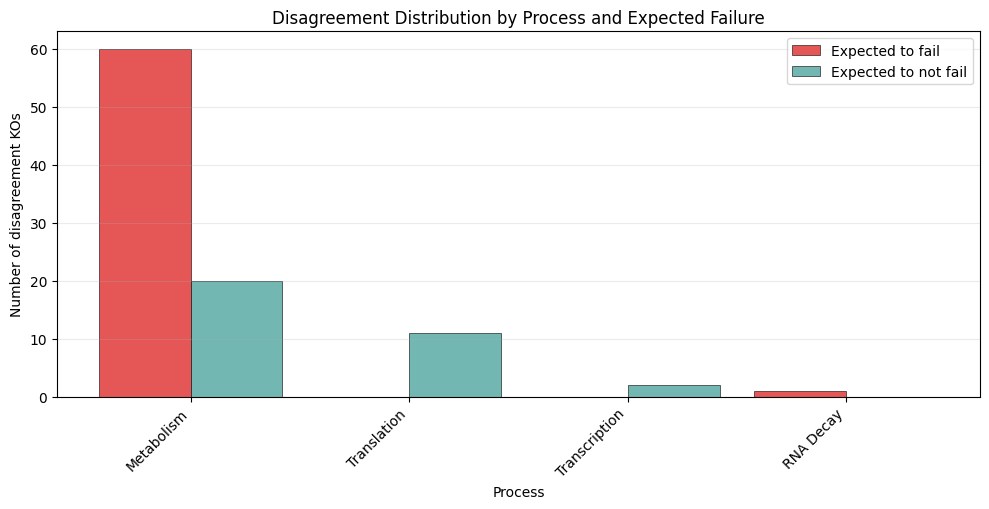

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load disagreement-only table saved in previous step
failed_tbl_path = Path(
    "/user/home/il22158/work/vEcoli/surrogate/comparison/"
    "simulation_failure_disagreement_with_process_labels.csv"
)
failed_tbl = pd.read_csv(failed_tbl_path)

# Build expected class column
if "expected_category" in failed_tbl.columns:
    cat_series = failed_tbl["expected_category"].fillna("unknown")
else:
    cat_series = failed_tbl["expected_failed_before_gen8"].map(
        lambda x: "expected_essential" if bool(x) else "expected_nonessential"
    )

plot_df = failed_tbl.copy()
plot_df["expected_category"] = cat_series

# Keep only the two requested classes for side-by-side comparison
valid_classes = ["expected_essential", "expected_nonessential"]
plot_df = plot_df[plot_df["expected_category"].isin(valid_classes)].copy()
plot_df["Process"] = plot_df["Process"].fillna("Unknown")

# Count disagreement KOs by process and expected class
counts = (
    plot_df.groupby(["Process", "expected_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=valid_classes, fill_value=0)
)

# Sort processes by total disagreement count (descending)
counts = counts.assign(_total=counts.sum(axis=1)).sort_values("_total", ascending=False).drop(columns=["_total"])

# Grouped bar plot: adjacent bars for essential vs non-essential within each process
x = np.arange(len(counts.index))
bar_w = 0.42

plt.figure(figsize=(max(10, 0.42 * len(counts.index) + 4), 5.2))
plt.bar(
    x - bar_w / 2,
    counts["expected_essential"].values,
    width=bar_w,
    color="#E45756",
    edgecolor="black",
    linewidth=0.4,
    label="Expected to fail",
)
plt.bar(
    x + bar_w / 2,
    counts["expected_nonessential"].values,
    width=bar_w,
    color="#72B7B2",
    edgecolor="black",
    linewidth=0.4,
    label="Expected to not fail",
)

plt.title("Disagreement Distribution by Process and Expected Failure")
plt.xlabel("Process")
plt.ylabel("Number of disagreement KOs")
plt.xticks(x, counts.index, rotation=45, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(failed_tbl_path.parent / "disagreement_by_process_and_category.png")
plt.show()

## Compare the previous ML model to wet-experiment data

### Use data from attached table

In [ ]:
import pandas as pd

s7_path = "/user/home/il22158/work/vEcoli/reading/imported/table s7_data.csv"
s9_path = "/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx"

s7 = pd.read_csv(s7_path)
s9 = pd.read_excel(s9_path)

print(s7.head())
print(s7.columns)

print(s9.head())
print(s9.columns)

   Gene       RNA ID                          Monomer ID     Process  \
0   aas  EG11679_RNA                         AAS-MONOMER  Metabolism   
1   aat  EG11112_RNA                     EG11112-MONOMER  Metabolism   
2  accA  EG11647_RNA  CARBOXYL-TRANSFERASE-ALPHA-MONOMER  Metabolism   
3  accC  EG10276_RNA             BIOTIN-CARBOXYL-MONOMER  Metabolism   
4  accD  EG10217_RNA   CARBOXYL-TRANSFERASE-BETA-MONOMER  Metabolism   

   Essentiality  
0             0  
1             0  
2             0  
3             0  
4             0  
Index(['Gene', 'RNA ID', 'Monomer ID', 'Process', 'Essentiality'], dtype='object')
   Gene       RNA ID                        Monomer ID_x   Process_x  \
0   aas  EG11679_RNA                         AAS-MONOMER  Metabolism   
1   aat  EG11112_RNA                     EG11112-MONOMER  Metabolism   
2  accA  EG11647_RNA  CARBOXYL-TRANSFERASE-ALPHA-MONOMER  Metabolism   
3  accC  EG10276_RNA             BIOTIN-CARBOXYL-MONOMER  Metabolism   
4  accD  EG10217

In [ ]:
import pandas as pd

# Paths
s7_path = "/user/home/il22158/work/vEcoli/reading/imported/table s7_data.csv"
s9_path = "/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx"

# Load data
s7 = pd.read_csv(s7_path)[["Gene", "Essentiality"]]
s9 = pd.read_excel(s9_path)[["Gene", "Essentiality ML surrogate"]]

# Keep only relevant columns and rename immediately
s7 = s7[["Gene", "Essentiality"]].rename(columns={"Essentiality": "Essentiality_s7"})
s9 = s9[["Gene", "Essentiality ML surrogate"]].rename(columns={"Essentiality ML surrogate": "Essentiality_s9"})

# Merge
merged = pd.merge(s7, s9, on="Gene", how="inner")

# Compare
mismatches = merged[merged["Essentiality_s7"] != merged["Essentiality_s9"]]

print(mismatches[["Gene", "Essentiality_s7", "Essentiality_s9"]])

Empty DataFrame
Columns: [Gene, Essentiality_s7, Essentiality_s9]
Index: []


In [ ]:
import pandas as pd

s9_path = "/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx"

s9 = pd.read_excel(s9_path)

mismatches = s9[
    s9["Rousset_all_strains_M9"].fillna("NA") !=
    s9["Essentiality ML surrogate"].fillna("NA")
]

print(mismatches[["Gene", "Rousset_all_strains_M9", "Essentiality ML surrogate"]])

      Gene  Rousset_all_strains_M9  Essentiality ML surrogate
2     accA                       1                          0
3     accC                       1                          0
4     accD                       1                          0
62    argA                       0                          1
66    argE                       0                          1
...    ...                     ...                        ...
1057  trpE                       0                          1
1063  trxB                       0                          1
1067  tyrA                       0                          1
1101  waaA                       1                          0
1120  xanQ                       0                          1

[157 rows x 3 columns]


In [12]:
import pandas as pd

# Paths
s19_path = "/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx"
rna_list_path = "/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt"

# Load S19
s19 = pd.read_excel(s19_path)
s19.columns = s19.columns.str.strip()

# Load RNA list
rna_list = pd.read_csv(rna_list_path, header=None)[0].astype(str).str.strip()

# Normalize RNA IDs in S19 (remove "_RNA")
s19["RNA_clean"] = s19["RNA ID"].astype(str).str.replace("_RNA", "", regex=False).str.strip()

# Keep only genes in list
s19_sub = s19[s19["RNA_clean"].isin(rna_list)].copy()

# Compare columns
col1 = "Rousset_all_strains_M9"
col2 = "Essentiality ML surrogate"

s19_sub = s19_sub[
    ["Gene", "RNA_clean", col1, col2]
].copy()

# Mismatch logic (safe for NaNs)
mismatch = s19_sub[
    s19_sub[col1].fillna("NA") != s19_sub[col2].fillna("NA")
]

# Output count
print("Total genes in list:", len(s19_sub))
print("Mismatches:", len(mismatch))

Total genes in list: 462
Mismatches: 87


### Classification and visualization

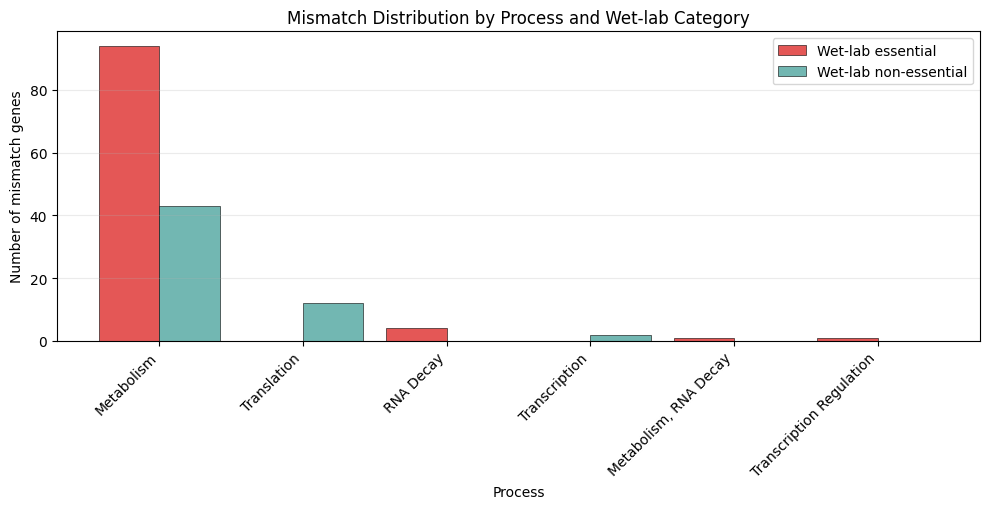

Using Table S19 ML column: Essentiality ML surrogate
Total genes compared: 1219
Matches: 1062
Mismatches: 157
Saved comparison table: /user/home/il22158/work/vEcoli/surrogate/previous_ml_model/previous_ml_model_vs_rousset_all_strains_m9.csv
Saved mismatch + process table: /user/home/il22158/work/vEcoli/surrogate/previous_ml_model/previous_ml_model_mismatch_with_process_labels.csv
Saved mismatch plot: /user/home/il22158/work/vEcoli/surrogate/previous_ml_model/mismatch_by_process_and_category.png


,gene_id,RNA ID,Essentiality_ML_surrogate,ml_surrogate_bool,Rousset_all_strains_M9,rousset_bool,expected_category,criteria_match
0,EG11679,EG11679_RNA,0,False,0,False,expected_nonessential,True
1,EG11112,EG11112_RNA,0,False,0,False,expected_nonessential,True
2,EG11647,EG11647_RNA,0,False,1,True,expected_essential,False
3,EG10276,EG10276_RNA,0,False,1,True,expected_essential,False
4,EG10217,EG10217_RNA,0,False,1,True,expected_essential,False


In [4]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Paths ----------
table_s19_path = Path('/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx')
process_xlsx_path = Path('/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx')
out_dir = Path('/user/home/il22158/work/vEcoli/surrogate/previous_ml_model')
out_dir.mkdir(parents=True, exist_ok=True)

comparison_out = out_dir / 'previous_ml_model_vs_rousset_all_strains_m9.csv'
mismatch_out = out_dir / 'previous_ml_model_mismatch_with_process_labels.csv'
plot_out = out_dir / 'mismatch_by_process_and_category.png'


def _canon(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def _find_ml_surrogate_col(df: pd.DataFrame):
    cmap = {_canon(c): c for c in df.columns}

    priority_keys = [
        'essentialitymlsurrogate',
        'essentialitymlmodel',
        'previousmlmodel',
        'mlsurrogateprediction',
        'essentialityprediction',
        'predictedessentiality',
    ]
    for key in priority_keys:
        if key in cmap:
            return cmap[key]

    for k, v in cmap.items():
        if 'rousset' in k:
            continue
        has_ml = ('ml' in k) or ('surrogate' in k)
        has_pred = ('predict' in k) or ('essential' in k)
        if has_ml and has_pred:
            return v

    for k, v in cmap.items():
        if 'rousset' in k:
            continue
        if ('essential' in k and 'predict' in k) or ('model' in k and 'essential' in k):
            return v

    return None


def read_xlsx_without_openpyxl(path: str, required_header_keys=None) -> pd.DataFrame:
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
    required_header_keys = required_header_keys or []

    def col_to_idx(cell_ref: str) -> int:
        col = ''.join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord('A') + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            sroot = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                parts = [t.text or '' for t in si.findall('.//a:t', ns)]
                shared_strings.append(''.join(parts))

        sheet_xml = ET.fromstring(zf.read('xl/worksheets/sheet1.xml'))
        parsed_rows = []
        for row in sheet_xml.findall('.//a:sheetData/a:row', ns):
            vals = {}
            for c in row.findall('a:c', ns):
                ref = c.attrib.get('r', '')
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get('t', '')
                v = c.find('a:v', ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == 's':
                    vals[cidx] = shared_strings[int(raw)] if raw.isdigit() and int(raw) < len(shared_strings) else raw
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    header_idx = None
    if required_header_keys:
        req = [_canon(k) for k in required_header_keys]
        for i, row in enumerate(grid[:120]):
            row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ''}
            if all(any((rk == k) or (rk in k) or (k in rk) for k in row_keys) for rk in req):
                header_idx = i
                break

    if header_idx is None:
        header_idx = 2 if len(grid) > 2 else 0

    header = [str(x).strip() if x is not None else '' for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    return df.dropna(axis=0, how='all').dropna(axis=1, how='all')


def to_bool_like(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {'true', '1', 'yes', 'y', 'essential', 'failed'}:
        return True
    if s in {'false', '0', 'no', 'n', 'non-essential', 'nonessential', 'unessential', 'successful'}:
        return False
    return pd.NA


# ---------- Load and prepare Table S19 ----------
s19_df = read_xlsx_without_openpyxl(
    str(table_s19_path),
    required_header_keys=['rna id', 'rousset_all_strains_m9'],
)
rna_col = _find_col(s19_df, 'rnaid')
rousset_col = _find_col(s19_df, 'roussetallstrainsm9')
ml_col = _find_ml_surrogate_col(s19_df)

if rna_col is None or rousset_col is None or ml_col is None:
    raise KeyError(
        f'Could not find required columns in table s19_data.xlsx. Found columns: {list(s19_df.columns)}'
    )

comp = s19_df.rename(
    columns={
        rna_col: 'RNA ID',
        rousset_col: 'Rousset_all_strains_M9',
        ml_col: 'Essentiality_ML_surrogate',
    }
).copy()

comp['gene_id'] = comp['RNA ID'].astype(str).str.replace(r'_RNA$', '', regex=True).str.strip()
comp['rousset_bool'] = comp['Rousset_all_strains_M9'].map(to_bool_like)
comp['ml_surrogate_bool'] = comp['Essentiality_ML_surrogate'].map(to_bool_like)
comp['criteria_match'] = np.where(
    comp['ml_surrogate_bool'].notna() & comp['rousset_bool'].notna(),
    comp['ml_surrogate_bool'] == comp['rousset_bool'],
    pd.NA,
)
comp['expected_category'] = comp['rousset_bool'].map(
    lambda x: 'expected_essential' if x is True else ('expected_nonessential' if x is False else 'unknown')
)

result_table = comp[
    [
        'gene_id',
        'RNA ID',
        'Essentiality_ML_surrogate',
        'ml_surrogate_bool',
        'Rousset_all_strains_M9',
        'rousset_bool',
        'expected_category',
        'criteria_match',
    ]
]
result_table.to_csv(comparison_out, index=False)

# ---------- Attach process labels for mismatch-only rows ----------
proc_df = read_xlsx_without_openpyxl(
    str(process_xlsx_path),
    required_header_keys=['rna id', 'process'],
)
proc_rna_col = _find_col(proc_df, 'rnaid')
proc_process_col = _find_col(proc_df, 'process')
if proc_rna_col is None or proc_process_col is None:
    raise KeyError(f'Could not find RNA ID / Process columns. Available: {list(proc_df.columns)}')

proc_df = proc_df.rename(columns={proc_rna_col: 'RNA ID', proc_process_col: 'Process'})
proc_df['gene_id'] = proc_df['RNA ID'].astype(str).str.replace(r'_RNA$', '', regex=True).str.strip()
proc_df = proc_df[['gene_id', 'RNA ID', 'Process']].drop_duplicates()

mismatch = result_table[result_table['criteria_match'] == False].copy()
mismatch = mismatch.merge(proc_df[['gene_id', 'Process']], on='gene_id', how='left')
mismatch['Process'] = mismatch['Process'].fillna('Unknown')

process_counts = mismatch['Process'].value_counts(dropna=False)
process_share = (process_counts / max(len(mismatch), 1) * 100.0).rename('process_percent_of_mismatch')
mismatch = mismatch.merge(
    process_share.reset_index().rename(columns={'index': 'Process'}),
    on='Process',
    how='left',
)
mismatch.to_csv(mismatch_out, index=False)

# ---------- Mismatch distribution plot ----------
valid_classes = ['expected_essential', 'expected_nonessential']
plot_df = mismatch[mismatch['expected_category'].isin(valid_classes)].copy()
counts = (
    plot_df.groupby(['Process', 'expected_category'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=valid_classes, fill_value=0)
)
counts = counts.assign(_total=counts.sum(axis=1)).sort_values('_total', ascending=False).drop(columns=['_total'])

x = np.arange(len(counts.index))
bar_w = 0.42

plt.figure(figsize=(max(10, 0.42 * len(counts.index) + 4), 5.2))
plt.bar(
    x - bar_w / 2,
    counts['expected_essential'].values,
    width=bar_w,
    color='#E45756',
    edgecolor='black',
    linewidth=0.4,
    label='Wet-lab essential',
)
plt.bar(
    x + bar_w / 2,
    counts['expected_nonessential'].values,
    width=bar_w,
    color='#72B7B2',
    edgecolor='black',
    linewidth=0.4,
    label='Wet-lab non-essential',
)

plt.title('Mismatch Distribution by Process and Wet-lab Category')
plt.xlabel('Process')
plt.ylabel('Number of mismatch genes')
plt.xticks(x, counts.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(plot_out)
plt.show()

n_match = int((result_table['criteria_match'] == True).sum())
n_mismatch = int((result_table['criteria_match'] == False).sum())

print(f'Using Table S19 ML column: {ml_col}')
print(f'Total genes compared: {len(result_table)}')
print(f'Matches: {n_match}')
print(f'Mismatches: {n_mismatch}')
print(f'Saved comparison table: {comparison_out}')
print(f'Saved mismatch + process table: {mismatch_out}')
print(f'Saved mismatch plot: {plot_out}')

result_table.head()

## Compare previous wcEcoli simulation to wet-lab data

### Use data from shared repository

In [16]:
from pathlib import Path
import pandas as pd

pkl_path = Path('/user/home/il22158/work/vEcoli/reading/imported/df_single_ko.pkl')
obj = pd.read_pickle(pkl_path)

print(f'Loaded object type: {type(obj).__name__}')

if isinstance(obj, pd.DataFrame):
    print(f'Shape: {obj.shape}')
    print('Columns:')
    for i, c in enumerate(obj.columns, start=1):
        print(f'{i:2d}. {c}')
else:
    print('Object is not a DataFrame, so no DataFrame columns to list.')

Loaded object type: DataFrame
Shape: (924, 33)
Columns:
 1. cellMass
 2. growth
 3. dryMass
 4. waterMass
 5. dnaMass
 6. cytosol_mass
 7. tRnaMass
 8. extracellular_mass
 9. rRnaMass
10. proteinMass
11. projection_mass
12. rnaMass
13. outer_membrane_mass
14. flagellum
15. pilus_mass
16. cellVolume
17. inner_membrane_mass
18. mRnaMass
19. smallMoleculeMass
20. instantaniousGrowthRate
21. membrane_mass
22. periplasm_mass
23. processMassDifferences
24. time
25. label
26. cell_path
27. generation
28. gene_id
29. seed
30. cell
31. gene_name
32. label_death
33. label_lifetime


In [22]:
from pathlib import Path
import pandas as pd

pkl_path = Path('/user/home/il22158/work/vEcoli/reading/imported/df_single_ko.pkl')
df = pd.read_pickle(pkl_path)

if not isinstance(df, pd.DataFrame):
    raise TypeError(f'Expected a DataFrame, got {type(df).__name__}')

required_cols = ['gene_id', 'gene_name', 'label', 'label_death', 'label_lifetime']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}. Available columns: {list(df.columns)}')

# Use your requested example.
example_gene_id = df['gene_id'].iloc[-5:-1]  # or set to a specific gene_id if desired
example_rows = df[df['gene_id'].isin(example_gene_id)][required_cols].copy()

if example_rows.empty:
    raise ValueError(f'No rows found for gene_id={example_gene_id}')

print(f'Example gene_id: {example_gene_id}')
print(f'Number of simulation rows for this gene_id: {len(example_rows)}')
print('Rows:')
print(example_rows.to_string(index=False))

print('\nUnique (gene_name, label, label_death, label_lifetime) combinations:')
print(example_rows[['gene_name', 'label', 'label_death', 'label_lifetime']].drop_duplicates().to_string(index=False))

Example gene_id: 17631    1421
17663    1507
17689    1541
17701    1542
Name: gene_id, dtype: int64
Number of simulation rows for this gene_id: 8
Rows:
 gene_id gene_name label label_death label_lifetime
    1421      rpiA   yes deadly_gene     normal_sim
    1507      pyrH   yes deadly_gene     normal_sim
    1541      leuD   yes deadly_gene     normal_sim
    1542      leuC   yes deadly_gene     normal_sim
    1421      rpiA   yes deadly_gene     normal_sim
    1507      pyrH   yes deadly_gene     normal_sim
    1541      leuD   yes deadly_gene     normal_sim
    1542      leuC   yes deadly_gene     normal_sim

Unique (gene_name, label, label_death, label_lifetime) combinations:
gene_name label label_death label_lifetime
     rpiA   yes deadly_gene     normal_sim
     pyrH   yes deadly_gene     normal_sim
     leuD   yes deadly_gene     normal_sim
     leuC   yes deadly_gene     normal_sim


In [24]:
from pathlib import Path
import pandas as pd

pkl_path = Path('/user/home/il22158/work/vEcoli/reading/imported/df_single_ko.pkl')
df = pd.read_pickle(pkl_path)

if not isinstance(df, pd.DataFrame):
    raise TypeError(f'Expected a DataFrame, got {type(df).__name__}')
if 'label_lifetime' not in df.columns:
    raise KeyError(f"'label_lifetime' column not found. Available: {list(df.columns)}")

lifetime = df['label_lifetime']
lifetime_norm = lifetime.where(lifetime.notna(), 'NaN').astype(str).str.strip()

counts = lifetime_norm.value_counts(dropna=False)
other_counts = counts[counts.index != 'normal_sim']
other_total = int(other_counts.sum())

print('label_lifetime value counts (including NaN):')
print(counts.to_string())
print(f"\nTotal rows with label_lifetime != 'normal_sim': {other_total}")

if other_total > 0:
    print("Breakdown of non-'normal_sim' values:")
    print(other_counts.to_string())
else:
    print("No other values found beyond 'normal_sim'.")

label_lifetime value counts (including NaN):
label_lifetime
normal_sim    756
NaN           110
short_sim      56
long_sim        2

Total rows with label_lifetime != 'normal_sim': 168
Breakdown of non-'normal_sim' values:
label_lifetime
NaN          110
short_sim     56
long_sim       2


In [25]:
from pathlib import Path
import pandas as pd

pkl_path = Path('/user/home/il22158/work/vEcoli/reading/imported/df_single_ko.pkl')
df = pd.read_pickle(pkl_path)

required_cols = ['gene_id', 'gene_name', 'label', 'label_death']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'Missing required columns: {missing}. Available: {list(df.columns)}')

tmp = df[required_cols].copy()
tmp['label'] = tmp['label'].astype(str).str.strip().str.lower()
tmp['label_death'] = tmp['label_death'].astype(str).str.strip().str.lower()

# Gene-wise rule from your request:
# 1) If any simulation has label == 'no', gene-level label is 'no' (otherwise 'yes').
# 2) If any simulation has label_death == 'deadly_gene', gene-level death is 'deadly_gene' (otherwise 'not_deadly').
genewise = (
    tmp.groupby(['gene_id', 'gene_name'], as_index=False)
    .agg(
        n_simulations=('gene_id', 'size'),
        any_no=('label', lambda s: (s == 'no').any()),
        any_deadly=('label_death', lambda s: (s == 'deadly_gene').any()),
    )
)

genewise['overall_label'] = genewise['any_no'].map({True: 'no', False: 'yes'})
genewise['overall_label_death'] = genewise['any_deadly'].map({True: 'deadly_gene', False: 'not_deadly'})

# Agreement under your intended mapping: no <-> deadly_gene, yes <-> not_deadly
genewise['expected_label_from_death'] = genewise['overall_label_death'].map(
    {'deadly_gene': 'no', 'not_deadly': 'yes'}
)
genewise['match'] = genewise['overall_label'] == genewise['expected_label_from_death']

print(f'Gene-wise total genes: {len(genewise)}')
print('Gene-wise crosstab: overall_label vs overall_label_death')
print(pd.crosstab(genewise['overall_label'], genewise['overall_label_death']).to_string())

n_match = int(genewise['match'].sum())
n_mismatch = int((~genewise['match']).sum())
print(f'\nGene-wise matches: {n_match}')
print(f'Gene-wise mismatches: {n_mismatch}')

if n_mismatch > 0:
    print('\nExample mismatched genes (first 20):')
    print(
        genewise.loc[~genewise['match'], ['gene_id', 'gene_name', 'n_simulations', 'overall_label', 'overall_label_death']]
        .head(20)
        .to_string(index=False)
    )

genewise.head()

Gene-wise total genes: 462
Gene-wise crosstab: overall_label vs overall_label_death
overall_label_death  deadly_gene  not_deadly
overall_label                               
no                            95           0
yes                           97         270

Gene-wise matches: 365
Gene-wise mismatches: 97

Example mismatched genes (first 20):
 gene_id gene_name  n_simulations overall_label overall_label_death
      46      alaS              2           yes         deadly_gene
      47      aldA              2           yes         deadly_gene
      74      argA              2           yes         deadly_gene
      75      argB              2           yes         deadly_gene
      76      argC              2           yes         deadly_gene
      79      argG              2           yes         deadly_gene
      82      argS              2           yes         deadly_gene
      88      aroE              2           yes         deadly_gene
      95      aroP              2    

,gene_id,gene_name,n_simulations,any_no,any_deadly,overall_label,overall_label_death,expected_label_from_death,match
0,16,alr,2,False,False,yes,not_deadly,yes,True
1,19,dfp,2,False,False,yes,not_deadly,yes,True
2,20,dcuB,2,False,False,yes,not_deadly,yes,True
3,21,hisM,2,False,False,yes,not_deadly,yes,True
4,25,cydC,2,False,False,yes,not_deadly,yes,True


- Data Inspection:
Crosstab from the pickle:
    1. no only appears with deadly_gene (173 rows)
    2. yes appears with both not_deadly (540 rows) and deadly_gene (211 rows)

Data to be used: df_single_ko.pkl is a 924x33 DataFrame with simulation outcome labels (yes/no) and gene symbols (gene_name), and Table S19 has Gene, Essentiality ML surrogate, and Rousset_all_strains_M9.

Aim for following code: compute expected-failure agreement and process-level mismatch distribution.

### Label vs Essentiality

Loaded raw simulation type: DataFrame
Raw simulation shape: (924, 33)
Raw simulation dtypes (top counts):
object    32
int64      1
Name: count, dtype: int64


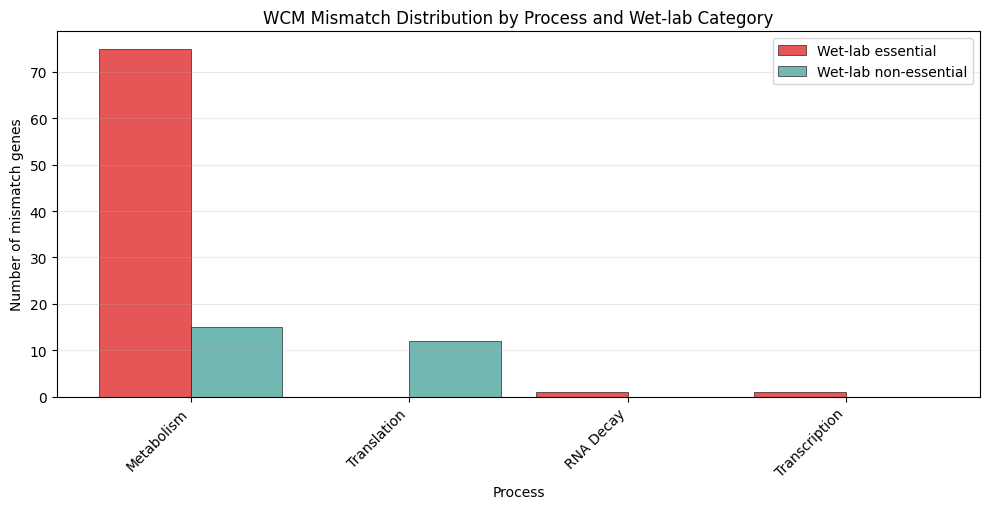

Total genes from raw simulation: 462
Genes matched to Table S19: 462
Genes unmatched in Table S19: 0
Matches (expected failure criterion): 358
Mismatches (expected failure criterion): 104
Saved comparison table: /user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_previous_study_vs_rousset_all_strains_m9.csv
Saved mismatch + process table: /user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_previous_study_mismatch_with_process_labels.csv
Saved mismatch plot: /user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_mismatch_by_process_and_category.png


,gene_symbol,Gene,RNA ID,failed_before_gen8,Rousset_all_strains_M9,rousset_bool,expected_category,criteria_match,n_simulations
0,aat,aat,EG11112_RNA,False,0,False,expected_nonessential,True,2
1,acca,accA,EG11647_RNA,False,1,True,expected_essential,False,2
2,acea,aceA,EG10022_RNA,False,0,False,expected_nonessential,True,2
3,aceb,aceB,EG10023_RNA,False,0,False,expected_nonessential,True,2
4,acee,aceE,EG10024_RNA,False,0,False,expected_nonessential,True,2


In [11]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Paths ----------
raw_sim_path = Path('/user/home/il22158/work/vEcoli/reading/imported/df_single_ko.pkl')
table_s19_path = Path('/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx')
process_xlsx_path = Path('/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx')
out_dir = Path('/user/home/il22158/work/vEcoli/surrogate/previous_study_wcm')
out_dir.mkdir(parents=True, exist_ok=True)

comparison_out = out_dir / 'wcm_previous_study_vs_rousset_all_strains_m9.csv'
mismatch_out = out_dir / 'wcm_previous_study_mismatch_with_process_labels.csv'
plot_out = out_dir / 'wcm_mismatch_by_process_and_category.png'


def _canon(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str, required_header_keys=None) -> pd.DataFrame:
    required_header_keys = required_header_keys or []
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    def col_to_idx(cell_ref: str) -> int:
        col = ''.join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord('A') + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            sroot = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                parts = [t.text or '' for t in si.findall('.//a:t', ns)]
                shared_strings.append(''.join(parts))

        sheet_xml = ET.fromstring(zf.read('xl/worksheets/sheet1.xml'))
        parsed_rows = []
        for row in sheet_xml.findall('.//a:sheetData/a:row', ns):
            vals = {}
            for c in row.findall('a:c', ns):
                ref = c.attrib.get('r', '')
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get('t', '')
                v = c.find('a:v', ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == 's' and raw.isdigit() and int(raw) < len(shared_strings):
                    vals[cidx] = shared_strings[int(raw)]
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    header_idx = None
    req = [_canon(k) for k in required_header_keys]
    for i, row in enumerate(grid[:120]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ''}
        if req and all(any((rk == k) or (rk in k) or (k in rk) for k in row_keys) for rk in req):
            header_idx = i
            break
        if not req and len(row_keys) >= 3:
            header_idx = i
            break

    if header_idx is None:
        header_idx = 2 if len(grid) > 2 else 0

    header = [str(x).strip() if x is not None else '' for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    return df.dropna(axis=0, how='all').dropna(axis=1, how='all')


def to_bool_like(x): ## Covert descriptive texts to boolean values
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {'true', '1', 'yes', 'y', 'essential', 'failed', 'deadly_gene', 'deadly'}:
        return True
    if s in {'false', '0', 'no', 'n', 'non-essential', 'nonessential', 'unessential', 'successful', 'not_deadly'}:
        return False
    return pd.NA


# ---------- 1) Load and profile raw simulation data ----------
raw_obj = pd.read_pickle(raw_sim_path)
if not isinstance(raw_obj, pd.DataFrame):
    raise TypeError(f'Expected DataFrame in {raw_sim_path}, got: {type(raw_obj)}')
raw_df = raw_obj.copy()

print(f'Loaded raw simulation type: {type(raw_obj).__name__}')
print(f'Raw simulation shape: {raw_df.shape}')
print('Raw simulation dtypes (top counts):')
print(raw_df.dtypes.astype(str).value_counts().head(10))

gene_col = 'gene_name' if 'gene_name' in raw_df.columns else _find_col(raw_df, 'gene')
label_col = 'label' if 'label' in raw_df.columns else _find_col(raw_df, 'label') ## Ioana comfirmed the correct label is label_death
if gene_col is None or label_col is None:
    raise KeyError(f'Could not find gene/simulation label columns. Available: {list(raw_df.columns)}')

raw_df['gene_symbol'] = raw_df[gene_col].astype(str).str.strip().str.lower()
raw_df['sim_failed_before_gen8'] = raw_df[label_col].map(lambda v: (to_bool_like(v) is False) if pd.notna(to_bool_like(v)) else pd.NA)

sim_gene = (
    raw_df.groupby('gene_symbol', as_index=False)
    .agg(
        failed_before_gen8=('sim_failed_before_gen8', lambda x: bool((x == True).any())),
        n_simulations=('gene_symbol', 'size'),
    )
)

# ---------- 2) Load wet-lab table (Table S19) ----------
s19_df = read_xlsx_without_openpyxl(
    str(table_s19_path),
    required_header_keys=['gene', 'rna id', 'rousset_all_strains_m9'],
)
s19_gene_col = _find_col(s19_df, 'gene')
s19_rna_col = _find_col(s19_df, 'rnaid')
s19_rousset_col = _find_col(s19_df, 'roussetallstrainsm9')

if s19_gene_col is None or s19_rna_col is None or s19_rousset_col is None:
    raise KeyError(f'Could not find Gene/RNA/Rousset columns. Available: {list(s19_df.columns)}')

s19_df = s19_df.rename(
    columns={
        s19_gene_col: 'Gene',
        s19_rna_col: 'RNA ID',
        s19_rousset_col: 'Rousset_all_strains_M9',
    }
)
s19_df['gene_symbol'] = s19_df['Gene'].astype(str).str.strip().str.lower()
s19_df['rousset_bool'] = s19_df['Rousset_all_strains_M9'].map(to_bool_like)

s19_subset = s19_df[['gene_symbol', 'Gene', 'RNA ID', 'Rousset_all_strains_M9', 'rousset_bool']].drop_duplicates('gene_symbol')

# ---------- 3) Compare simulation failure vs wet-lab essentiality ----------
comparison = sim_gene.merge(s19_subset, on='gene_symbol', how='left')
comparison['criteria_match'] = np.where(
    comparison['rousset_bool'].notna(),
    comparison['failed_before_gen8'] == comparison['rousset_bool'],
    pd.NA,
)
comparison['expected_category'] = comparison['rousset_bool'].map(
    lambda x: 'expected_essential' if x is True else ('expected_nonessential' if x is False else 'unknown')
)

result_table = comparison[
    [
        'gene_symbol',
        'Gene',
        'RNA ID',
        'failed_before_gen8',
        'Rousset_all_strains_M9',
        'rousset_bool',
        'expected_category',
        'criteria_match',
        'n_simulations',
    ]
]
result_table.to_csv(comparison_out, index=False)

# ---------- 4) Process-labeled mismatch table ----------
proc_df = read_xlsx_without_openpyxl(
    str(process_xlsx_path),
    required_header_keys=['gene', 'rna id', 'process'],
)
proc_gene_col = _find_col(proc_df, 'gene')
proc_process_col = _find_col(proc_df, 'process')
if proc_gene_col is None or proc_process_col is None:
    raise KeyError(f'Could not find Gene/Process columns. Available: {list(proc_df.columns)}')

proc_df = proc_df.rename(columns={proc_gene_col: 'Gene', proc_process_col: 'Process'})
proc_df['gene_symbol'] = proc_df['Gene'].astype(str).str.strip().str.lower()
proc_df = proc_df[['gene_symbol', 'Process']].drop_duplicates('gene_symbol')

mismatch = result_table[result_table['criteria_match'] == False].copy()
mismatch = mismatch.merge(proc_df, on='gene_symbol', how='left')
mismatch['Process'] = mismatch['Process'].fillna('Unknown')

process_counts = mismatch['Process'].value_counts(dropna=False)
process_share = (process_counts / max(len(mismatch), 1) * 100.0).rename('process_percent_of_mismatch')
mismatch = mismatch.merge(
    process_share.reset_index().rename(columns={'index': 'Process'}),
    on='Process',
    how='left',
)
mismatch.to_csv(mismatch_out, index=False)

# ---------- 5) Plot mismatch distribution ----------
valid_classes = ['expected_essential', 'expected_nonessential']
plot_df = mismatch[mismatch['expected_category'].isin(valid_classes)].copy()

if plot_df.empty:
    print('No mismatches with recognized wet-lab classes to plot.')
else:
    counts = (
        plot_df.groupby(['Process', 'expected_category'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=valid_classes, fill_value=0)
)
    counts = counts.assign(_total=counts.sum(axis=1)).sort_values('_total', ascending=False).drop(columns=['_total'])

    x = np.arange(len(counts.index))
    bar_w = 0.42

    plt.figure(figsize=(max(10, 0.42 * len(counts.index) + 4), 5.2))
    plt.bar(
        x - bar_w / 2,
        counts['expected_essential'].values,
        width=bar_w,
        color='#E45756',
        edgecolor='black',
        linewidth=0.4,
        label='Wet-lab essential',
    )
    plt.bar(
        x + bar_w / 2,
        counts['expected_nonessential'].values,
        width=bar_w,
        color='#72B7B2',
        edgecolor='black',
        linewidth=0.4,
        label='Wet-lab non-essential',
    )

    plt.title('WCM Mismatch Distribution by Process and Wet-lab Category')
    plt.xlabel('Process')
    plt.ylabel('Number of mismatch genes')
    plt.xticks(x, counts.index, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_out)
    plt.show()

n_match = int((result_table['criteria_match'] == True).sum())
n_mismatch = int((result_table['criteria_match'] == False).sum())
n_unmatched = int(result_table['Rousset_all_strains_M9'].isna().sum())

print(f'Total genes from raw simulation: {len(sim_gene)}')
print(f'Genes matched to Table S19: {len(result_table) - n_unmatched}')
print(f'Genes unmatched in Table S19: {n_unmatched}')
print(f'Matches (expected failure criterion): {n_match}')
print(f'Mismatches (expected failure criterion): {n_mismatch}')
print(f'Saved comparison table: {comparison_out}')
print(f'Saved mismatch + process table: {mismatch_out}')
print(f'Saved mismatch plot: {plot_out}')

result_table.head()

### Label_death vs Essentiality

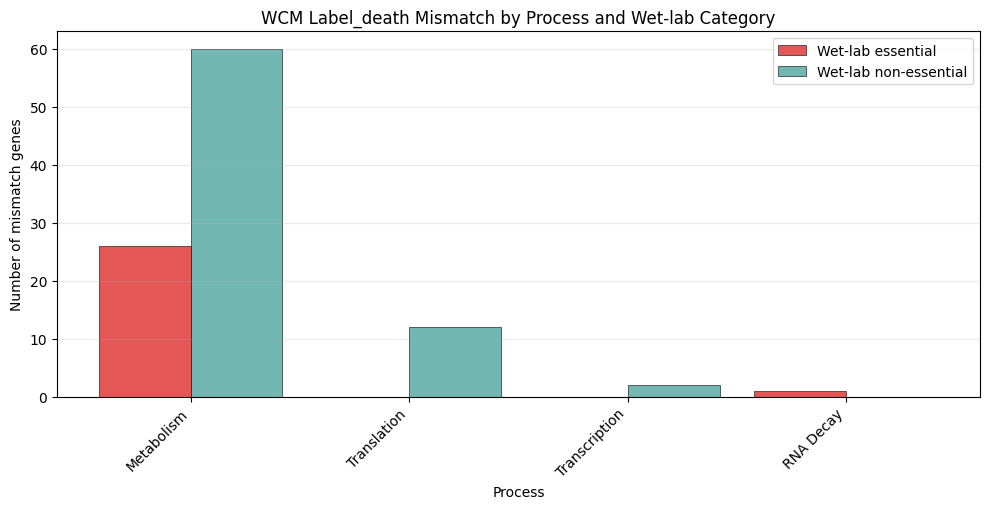

Total genes from raw simulation: 462
Genes matched to Table S19: 462
Genes unmatched in Table S19: 0
Matches (label_death criterion): 361
Mismatches (label_death criterion): 101
Saved comparison table: /user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_label_death_vs_rousset_all_strains_m9.csv
Saved mismatch + process table: /user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_label_death_mismatch_with_process_labels.csv
Saved mismatch plot: /user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_label_death_mismatch_by_process_and_category.png


,gene_id,gene_name,gene_symbol,RNA ID,overall_label_death,label_death_bool,Rousset_all_strains_M9,rousset_bool,expected_category,criteria_match,n_simulations
0,16,alr,alr,EG10001_RNA,not_deadly,False,0,False,expected_nonessential,True,2
1,19,dfp,dfp,EG10004_RNA,not_deadly,False,1,True,expected_essential,False,2
2,20,dcuB,dcub,EG10006_RNA,not_deadly,False,0,False,expected_nonessential,True,2
3,21,hisM,hism,EG10007_RNA,not_deadly,False,0,False,expected_nonessential,True,2
4,25,cydC,cydc,EG10012_RNA,not_deadly,False,0,False,expected_nonessential,True,2


In [1]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Paths ----------
raw_sim_path = Path('/user/home/il22158/work/vEcoli/reading/imported/df_single_ko.pkl')
table_s19_path = Path('/user/home/il22158/work/vEcoli/reading/imported/table s19_data.xlsx')
process_xlsx_path = Path('/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx')
out_dir = Path('/user/home/il22158/work/vEcoli/surrogate/previous_study_wcm')
out_dir.mkdir(parents=True, exist_ok=True)

comparison_out = out_dir / 'wcm_label_death_vs_rousset_all_strains_m9.csv'
mismatch_out = out_dir / 'wcm_label_death_mismatch_with_process_labels.csv'
plot_out = out_dir / 'wcm_label_death_mismatch_by_process_and_category.png'


def _canon(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str, required_header_keys=None) -> pd.DataFrame:
    required_header_keys = required_header_keys or []
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    def col_to_idx(cell_ref: str) -> int:
        col = ''.join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord('A') + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            sroot = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                parts = [t.text or '' for t in si.findall('.//a:t', ns)]
                shared_strings.append(''.join(parts))

        sheet_xml = ET.fromstring(zf.read('xl/worksheets/sheet1.xml'))
        parsed_rows = []
        for row in sheet_xml.findall('.//a:sheetData/a:row', ns):
            vals = {}
            for c in row.findall('a:c', ns):
                ref = c.attrib.get('r', '')
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get('t', '')
                v = c.find('a:v', ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == 's' and raw.isdigit() and int(raw) < len(shared_strings):
                    vals[cidx] = shared_strings[int(raw)]
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    header_idx = None
    req = [_canon(k) for k in required_header_keys]
    for i, row in enumerate(grid[:120]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ''}
        if req and all(any((rk == k) or (rk in k) or (k in rk) for k in row_keys) for rk in req):
            header_idx = i
            break

    if header_idx is None:
        header_idx = 2 if len(grid) > 2 else 0

    header = [str(x).strip() if x is not None else '' for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    return pd.DataFrame(data, columns=header).dropna(axis=0, how='all').dropna(axis=1, how='all')


def to_bool_like(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {'true', '1', 'yes', 'y', 'essential', 'failed', 'deadly_gene', 'deadly'}:
        return True
    if s in {'false', '0', 'no', 'n', 'non-essential', 'nonessential', 'unessential', 'successful', 'not_deadly'}:
        return False
    return pd.NA


# ---------- 1) Gene-wise label_death from pkl ----------
raw_df = pd.read_pickle(raw_sim_path)
required_cols = ['gene_id', 'gene_name', 'label_death']
missing = [c for c in required_cols if c not in raw_df.columns]
if missing:
    raise KeyError(f'Missing required columns in pkl: {missing}')

tmp = raw_df[required_cols].copy()
tmp['label_death'] = tmp['label_death'].astype(str).str.strip().str.lower()

# Gene-wise rule: if any simulation is deadly_gene => overall deadly_gene, else not_deadly
death_gene = (
    tmp.groupby(['gene_id', 'gene_name'], as_index=False)
    .agg(
        n_simulations=('gene_id', 'size'),
        any_deadly=('label_death', lambda s: (s == 'deadly_gene').any()),
    )
)
death_gene['overall_label_death'] = death_gene['any_deadly'].map({True: 'deadly_gene', False: 'not_deadly'})
death_gene['label_death_bool'] = death_gene['overall_label_death'].map(to_bool_like)
death_gene['gene_symbol'] = death_gene['gene_name'].astype(str).str.strip().str.lower()

# ---------- 2) Load wet-lab table (Table S19) ----------
s19_df = read_xlsx_without_openpyxl(
    str(table_s19_path),
    required_header_keys=['gene', 'rna id', 'rousset_all_strains_m9'],
)
s19_gene_col = _find_col(s19_df, 'gene')
s19_rna_col = _find_col(s19_df, 'rnaid')
s19_rousset_col = _find_col(s19_df, 'roussetallstrainsm9')
if s19_gene_col is None or s19_rna_col is None or s19_rousset_col is None:
    raise KeyError(f'Could not find Gene/RNA/Rousset columns. Available: {list(s19_df.columns)}')

s19_df = s19_df.rename(
    columns={
        s19_gene_col: 'Gene',
        s19_rna_col: 'RNA ID',
        s19_rousset_col: 'Rousset_all_strains_M9',
    }
)
s19_df['gene_symbol'] = s19_df['Gene'].astype(str).str.strip().str.lower()
s19_df['rousset_bool'] = s19_df['Rousset_all_strains_M9'].map(to_bool_like)

s19_subset = s19_df[['gene_symbol', 'Gene', 'RNA ID', 'Rousset_all_strains_M9', 'rousset_bool']].drop_duplicates('gene_symbol')

# ---------- 3) Compare label_death vs wet-lab essentiality ----------
comparison = death_gene.merge(s19_subset, on='gene_symbol', how='left')
comparison['criteria_match'] = np.where(
    comparison['rousset_bool'].notna(),
    comparison['label_death_bool'] == comparison['rousset_bool'],
    pd.NA,
)
comparison['expected_category'] = comparison['rousset_bool'].map(
    lambda x: 'expected_essential' if x is True else ('expected_nonessential' if x is False else 'unknown')
)

result_table = comparison[
    [
        'gene_id',
        'gene_name',
        'gene_symbol',
        'RNA ID',
        'overall_label_death',
        'label_death_bool',
        'Rousset_all_strains_M9',
        'rousset_bool',
        'expected_category',
        'criteria_match',
        'n_simulations',
    ]
]
result_table.to_csv(comparison_out, index=False)

# ---------- 4) Process-labeled mismatch table ----------
proc_df = read_xlsx_without_openpyxl(
    str(process_xlsx_path),
    required_header_keys=['gene', 'rna id', 'process'],
)
proc_gene_col = _find_col(proc_df, 'gene')
proc_process_col = _find_col(proc_df, 'process')
if proc_gene_col is None or proc_process_col is None:
    raise KeyError(f'Could not find Gene/Process columns. Available: {list(proc_df.columns)}')

proc_df = proc_df.rename(columns={proc_gene_col: 'Gene', proc_process_col: 'Process'})
proc_df['gene_symbol'] = proc_df['Gene'].astype(str).str.strip().str.lower()
proc_df = proc_df[['gene_symbol', 'Process']].drop_duplicates('gene_symbol')

mismatch = result_table[result_table['criteria_match'] == False].copy()
mismatch = mismatch.merge(proc_df, on='gene_symbol', how='left')
mismatch['Process'] = mismatch['Process'].fillna('Unknown')

process_counts = mismatch['Process'].value_counts(dropna=False)
process_share = (process_counts / max(len(mismatch), 1) * 100.0).rename('process_percent_of_mismatch')
mismatch = mismatch.merge(
    process_share.reset_index().rename(columns={'index': 'Process'}),
    on='Process',
    how='left',
)
mismatch.to_csv(mismatch_out, index=False)

# ---------- 5) Plot mismatch distribution ----------
valid_classes = ['expected_essential', 'expected_nonessential']
plot_df = mismatch[mismatch['expected_category'].isin(valid_classes)].copy()

if plot_df.empty:
    print('No mismatches with recognized wet-lab classes to plot.')
else:
    counts = (
        plot_df.groupby(['Process', 'expected_category'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=valid_classes, fill_value=0)
)
    counts = counts.assign(_total=counts.sum(axis=1)).sort_values('_total', ascending=False).drop(columns=['_total'])

    x = np.arange(len(counts.index))
    bar_w = 0.42

    plt.figure(figsize=(max(10, 0.42 * len(counts.index) + 4), 5.2))
    plt.bar(
        x - bar_w / 2,
        counts['expected_essential'].values,
        width=bar_w,
        color='#E45756',
        edgecolor='black',
        linewidth=0.4,
        label='Wet-lab essential',
    )
    plt.bar(
        x + bar_w / 2,
        counts['expected_nonessential'].values,
        width=bar_w,
        color='#72B7B2',
        edgecolor='black',
        linewidth=0.4,
        label='Wet-lab non-essential',
    )

    plt.title('WCM Label_death Mismatch by Process and Wet-lab Category')
    plt.xlabel('Process')
    plt.ylabel('Number of mismatch genes')
    plt.xticks(x, counts.index, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_out)
    plt.show()

n_match = int((result_table['criteria_match'] == True).sum())
n_mismatch = int((result_table['criteria_match'] == False).sum())
n_unmatched = int(result_table['Rousset_all_strains_M9'].isna().sum())

print(f'Total genes from raw simulation: {len(death_gene)}')
print(f'Genes matched to Table S19: {len(result_table) - n_unmatched}')
print(f'Genes unmatched in Table S19: {n_unmatched}')
print(f'Matches (label_death criterion): {n_match}')
print(f'Mismatches (label_death criterion): {n_mismatch}')
print(f'Saved comparison table: {comparison_out}')
print(f'Saved mismatch + process table: {mismatch_out}')
print(f'Saved mismatch plot: {plot_out}')

result_table.head()

### Debug (?)

In [1]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import pandas as pd

# Compare mismatch-gene overlap between notebook outputs and the new Table S17 file.
base = Path('/user/home/il22158/work/vEcoli')
new_xlsx_path = base / 'reading/imported/table_s17_raw_sim_mismatch.xlsx'

candidate_mismatch_files = [
    base / 'surrogate/previous_study_wcm/wcm_label_death_mismatch_with_process_labels.csv',
    base / 'surrogate/previous_study_wcm/wcm_previous_study_mismatch_with_process_labels.csv',
]

def _norm_gene(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    return s if s else None

def _to_essential_text(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    if s in {'true', '1', 'yes', 'y', 'essential', 'failed', 'deadly_gene', 'deadly'}:
        return 'essential'
    if s in {'false', '0', 'no', 'n', 'non-essential', 'nonessential', 'unessential', 'successful', 'not_deadly'}:
        return 'non_essential'
    if s in {'expected_essential'}:
        return 'essential'
    if s in {'expected_nonessential'}:
        return 'non_essential'
    return None

def load_table_s17_mismatch(path: Path):
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
    pat = re.compile(
        r'^\s*([A-Za-z0-9_\-]+)\s+has been classified as\s+(.+?)\s+and should be\s+(.+?)\s*$',
        re.I,
    )

    with zipfile.ZipFile(path) as zf:
        shared = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            sroot = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                parts = [t.text or '' for t in si.findall('.//a:t', ns)]
                shared.append(''.join(parts))

        sh = ET.fromstring(zf.read('xl/worksheets/sheet1.xml'))
        rows = []
        for row in sh.findall('.//a:sheetData/a:row', ns):
            c = row.find('a:c', ns)
            if c is None:
                continue
            v = c.find('a:v', ns)
            if v is None or v.text is None:
                continue
            raw = v.text
            ctype = c.attrib.get('t', '')
            txt = shared[int(raw)] if ctype == 's' and raw.isdigit() and int(raw) < len(shared) else raw
            txt = ' '.join(str(txt).split())
            if 'has been classified as' not in txt.lower():
                continue
            m = pat.match(txt)
            if not m:
                continue
            gene = _norm_gene(m.group(1))
            pred = _to_essential_text(m.group(2))
            expected = _to_essential_text(m.group(3))
            rows.append({'gene_symbol': gene, 'pred_new': pred, 'expected_new': expected, 'raw': txt})

    new_df = pd.DataFrame(rows).dropna(subset=['gene_symbol'])
    new_unique = new_df.drop_duplicates('gene_symbol').copy()
    new_set = set(new_unique['gene_symbol'])
    return new_df, new_unique, new_set

def load_notebook_mismatch(path: Path):
    df = pd.read_csv(path)

    gene_col = None
    for c in ['gene_symbol', 'gene_name', 'gene_id', 'RNA ID']:
        if c in df.columns:
            gene_col = c
            break
    if gene_col is None:
        raise KeyError(f'No gene identifier column found in {path.name}. Columns: {list(df.columns)}')

    genes = df[gene_col].map(_norm_gene)
    genes = genes.dropna()
    gene_set = set(genes.tolist())

    detail = pd.DataFrame({'gene_symbol': genes})
    detail = detail.drop_duplicates('gene_symbol')

    # Predicted label from notebook mismatch file if present.
    if 'overall_label_death' in df.columns:
        pred = df['overall_label_death'].map(_to_essential_text)
        detail = detail.merge(
            pd.DataFrame({'gene_symbol': genes, 'pred_old': pred}).dropna().drop_duplicates('gene_symbol'),
            on='gene_symbol',
            how='left',
        )
    elif 'failed_bool' in df.columns:
        pred = df['failed_bool'].map(_to_essential_text)
        detail = detail.merge(
            pd.DataFrame({'gene_symbol': genes, 'pred_old': pred}).dropna().drop_duplicates('gene_symbol'),
            on='gene_symbol',
            how='left',
        )
    elif 'ml_surrogate_bool' in df.columns:
        pred = df['ml_surrogate_bool'].map(_to_essential_text)
        detail = detail.merge(
            pd.DataFrame({'gene_symbol': genes, 'pred_old': pred}).dropna().drop_duplicates('gene_symbol'),
            on='gene_symbol',
            how='left',
        )

    # Wet-lab expected label from notebook mismatch file if present.
    if 'expected_category' in df.columns:
        expv = df['expected_category'].map(_to_essential_text)
        detail = detail.merge(
            pd.DataFrame({'gene_symbol': genes, 'expected_old': expv}).dropna().drop_duplicates('gene_symbol'),
            on='gene_symbol',
            how='left',
        )
    elif 'rousset_bool' in df.columns:
        expv = df['rousset_bool'].map(_to_essential_text)
        detail = detail.merge(
            pd.DataFrame({'gene_symbol': genes, 'expected_old': expv}).dropna().drop_duplicates('gene_symbol'),
            on='gene_symbol',
            how='left',
        )

    return df, detail, gene_set

new_all_rows, new_unique, new_set = load_table_s17_mismatch(new_xlsx_path)

print(f'Table S17 raw mismatch rows: {len(new_all_rows)}')
print(f'Table S17 unique mismatch genes: {len(new_set)}')
print('')

for old_path in candidate_mismatch_files:
    if not old_path.exists():
        print(f'Skipping missing file: {old_path}')
        print('')
        continue

    old_df, old_detail, old_set = load_notebook_mismatch(old_path)

    common = old_set & new_set
    only_old = old_set - new_set
    only_new = new_set - old_set
    jaccard = len(common) / len(old_set | new_set) if (old_set | new_set) else 0.0

    print('=' * 90)
    print(f'Notebook mismatch file: {old_path.name}')
    print(f'Rows in file: {len(old_df)}')
    print(f'Unique mismatch genes in file: {len(old_set)}')
    print(f'Same mismatched genes as Table S17: {len(common)}')
    print(f'Only in notebook mismatch file: {len(only_old)}')
    print(f'Only in Table S17: {len(only_new)}')
    print(f'Jaccard overlap: {jaccard:.4f}')

    # Direction agreement for overlapping genes where both sides have labels.
    overlap = old_detail.merge(new_unique[['gene_symbol', 'pred_new', 'expected_new']], on='gene_symbol', how='inner')
    if {'pred_old', 'expected_old'}.issubset(overlap.columns):
        comparable = overlap.dropna(subset=['pred_old', 'expected_old', 'pred_new', 'expected_new']).copy()
        if not comparable.empty:
            comparable['direction_match'] = (
                (comparable['pred_old'] == comparable['pred_new']) &
                (comparable['expected_old'] == comparable['expected_new'])
            )
            dmatch = int(comparable['direction_match'].sum())
            print(f'Overlap genes with comparable mismatch direction: {len(comparable)}')
            print(f'Among them, same mismatch direction: {dmatch}')

    print('Example common genes (up to 20):')
    print(', '.join(sorted(list(common))[:20]) if common else 'None')
    print('Example notebook-only genes (up to 20):')
    print(', '.join(sorted(list(only_old))[:20]) if only_old else 'None')
    print('Example Table-S17-only genes (up to 20):')
    print(', '.join(sorted(list(only_new))[:20]) if only_new else 'None')
    print('')

Table S17 raw mismatch rows: 55
Table S17 unique mismatch genes: 30

Notebook mismatch file: wcm_label_death_mismatch_with_process_labels.csv
Rows in file: 101
Unique mismatch genes in file: 101
Same mismatched genes as Table S17: 22
Only in notebook mismatch file: 79
Only in Table S17: 8
Jaccard overlap: 0.2018
Example common genes (up to 20):
alda, arop, cpda, csda, cyoe, emre, glce, glta, livg, livj, lpxl, mltc, nhaa, pfkb, potb, rcna, rfad, ribb, rpia, thil
Example notebook-only genes (up to 20):
acca, arga, arge, arok, asd, atpb, atpc, atpd, atpg, atph, can, cdsa, cysa, cysg, cysq, cysu, cysw, dapa, dapb, dapf
Example Table-S17-only genes (up to 20):
aroe, atpa, atpe, atpf, guab, murj, prs, tmk

Notebook mismatch file: wcm_previous_study_mismatch_with_process_labels.csv
Rows in file: 104
Unique mismatch genes in file: 104
Same mismatched genes as Table S17: 10
Only in notebook mismatch file: 94
Only in Table S17: 20
Jaccard overlap: 0.0806
Example common genes (up to 20):
aroe, cp

## Compare previous wcEcoli simulation with current simulation

### Label

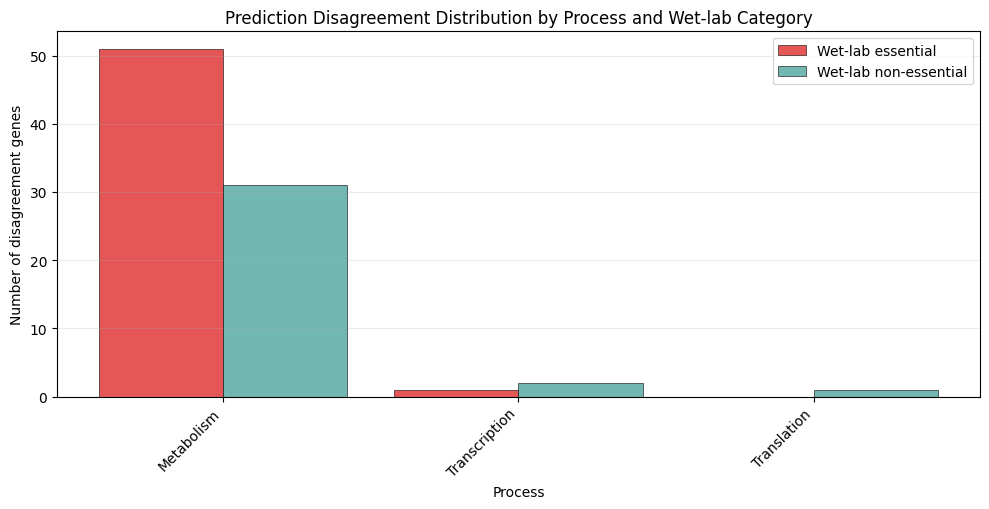

Current total genes: 462
Previous total genes: 462
Total number difference (abs): 0
Presence mismatch rows (only current + only previous): 0
Current mismatch count vs wet-lab: 94
Previous mismatch count vs wet-lab: 104
Mismatch difference (current - previous): -10
Prediction disagreement rows between current/previous: 86
Saved presence mismatch table: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_previous_presence_mismatch_with_process_labels.csv
Saved prediction disagreement table: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_previous_prediction_disagreement_with_process_labels.csv
Saved summary table: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_previous_summary.csv
Saved disagreement process plot: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_previous_prediction_disagreement_by_process_and_category.png


,n_current_genes,n_previous_genes,total_number_difference_abs,n_only_current,n_only_previous,current_mismatch_count,previous_mismatch_count,mismatch_difference_current_minus_previous,mismatch_difference_abs,prediction_disagreement_count_between_models
0,462,462,0,0,0,94,104,-10,10,86


In [8]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Paths ----------
current_path = Path('/user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_compared_to_rosset_all_strains_M9.csv')
previous_path = Path('/user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_previous_study_vs_rousset_all_strains_m9.csv')
process_xlsx_path = Path('/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx')
out_dir = Path('/user/home/il22158/work/vEcoli/surrogate/comparison')
out_dir.mkdir(parents=True, exist_ok=True)

presence_diff_out = out_dir / 'current_vs_previous_presence_mismatch_with_process_labels.csv'
prediction_diff_out = out_dir / 'current_vs_previous_prediction_disagreement_with_process_labels.csv'
summary_out = out_dir / 'current_vs_previous_summary.csv'
plot_out = out_dir / 'current_vs_previous_prediction_disagreement_by_process_and_category.png'


def _canon(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str, required_header_keys=None) -> pd.DataFrame:
    required_header_keys = required_header_keys or []
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    def col_to_idx(cell_ref: str) -> int:
        col = ''.join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord('A') + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            sroot = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                parts = [t.text or '' for t in si.findall('.//a:t', ns)]
                shared_strings.append(''.join(parts))

        sheet_xml = ET.fromstring(zf.read('xl/worksheets/sheet1.xml'))
        parsed_rows = []
        for row in sheet_xml.findall('.//a:sheetData/a:row', ns):
            vals = {}
            for c in row.findall('a:c', ns):
                ref = c.attrib.get('r', '')
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get('t', '')
                v = c.find('a:v', ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == 's' and raw.isdigit() and int(raw) < len(shared_strings):
                    vals[cidx] = shared_strings[int(raw)]
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    header_idx = None
    req = [_canon(k) for k in required_header_keys]
    for i, row in enumerate(grid[:120]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ''}
        if req and all(any((rk == k) or (rk in k) or (k in rk) for k in row_keys) for rk in req):
            header_idx = i
            break
        if not req and len(row_keys) >= 3:
            header_idx = i
            break

    if header_idx is None:
        header_idx = 2 if len(grid) > 2 else 0

    header = [str(x).strip() if x is not None else '' for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    return df.dropna(axis=0, how='all').dropna(axis=1, how='all')


def to_bool_like(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {'true', '1', 'yes', 'y', 'essential', 'failed', 'deadly_gene', 'deadly'}:
        return True
    if s in {'false', '0', 'no', 'n', 'non-essential', 'nonessential', 'unessential', 'successful', 'not_deadly'}:
        return False
    return pd.NA


# ---------- Load input tables ----------
current_df = pd.read_csv(current_path)
previous_df = pd.read_csv(previous_path)

# Build a common RNA-based key to compare both studies directly
curr_rna_col = _find_col(current_df, 'rnaid')
prev_rna_col = _find_col(previous_df, 'rnaid')
if curr_rna_col is None or prev_rna_col is None:
    raise KeyError(
        f'RNA ID column missing. current columns={list(current_df.columns)}, previous columns={list(previous_df.columns)}'
    )

current_df['RNA ID'] = current_df[curr_rna_col].astype(str).str.strip()
previous_df['RNA ID'] = previous_df[prev_rna_col].astype(str).str.strip()
current_df['gene_key'] = current_df['RNA ID'].str.replace(r'_RNA$', '', regex=True).str.strip().str.upper()
previous_df['gene_key'] = previous_df['RNA ID'].str.replace(r'_RNA$', '', regex=True).str.strip().str.upper()

# Normalize main boolean fields
curr_fail_col = _find_col(current_df, 'failedbeforegen8') or 'failed_before_gen8'
prev_fail_col = _find_col(previous_df, 'failedbeforegen8') or 'failed_before_gen8'
curr_match_col = _find_col(current_df, 'criteriamatch') or 'criteria_match'
prev_match_col = _find_col(previous_df, 'criteriamatch') or 'criteria_match'
curr_cat_col = _find_col(current_df, 'expectedcategory') or 'expected_category'
prev_cat_col = _find_col(previous_df, 'expectedcategory') or 'expected_category'

if curr_fail_col not in current_df.columns or prev_fail_col not in previous_df.columns:
    raise KeyError('failed_before_gen8 column missing in one of the input files.')

current_df['failed_bool'] = current_df[curr_fail_col].map(to_bool_like)
previous_df['failed_bool'] = previous_df[prev_fail_col].map(to_bool_like)
current_df['criteria_match_bool'] = current_df[curr_match_col].map(to_bool_like) if curr_match_col in current_df.columns else pd.NA
previous_df['criteria_match_bool'] = previous_df[prev_match_col].map(to_bool_like) if prev_match_col in previous_df.columns else pd.NA

current_df['expected_category'] = current_df[curr_cat_col] if curr_cat_col in current_df.columns else 'unknown'
previous_df['expected_category'] = previous_df[prev_cat_col] if prev_cat_col in previous_df.columns else 'unknown'

# Deduplicate per gene_key if needed
current_gene = (
    current_df.sort_values('RNA ID')
    .drop_duplicates('gene_key')
    [['gene_key', 'RNA ID', 'failed_bool', 'criteria_match_bool', 'expected_category']]
)
previous_gene = (
    previous_df.sort_values('RNA ID')
    .drop_duplicates('gene_key')
    [['gene_key', 'RNA ID', 'failed_bool', 'criteria_match_bool', 'expected_category']]
 )

# ---------- Load process labels ----------
proc_df = read_xlsx_without_openpyxl(
    str(process_xlsx_path),
    required_header_keys=['rna id', 'process'],
)
proc_rna_col = _find_col(proc_df, 'rnaid')
proc_process_col = _find_col(proc_df, 'process')
if proc_rna_col is None or proc_process_col is None:
    raise KeyError(f'Could not find RNA ID/Process columns in process label file: {list(proc_df.columns)}')

proc_df = proc_df.rename(columns={proc_rna_col: 'RNA ID', proc_process_col: 'Process'})
proc_df['gene_key'] = proc_df['RNA ID'].astype(str).str.replace(r'_RNA$', '', regex=True).str.strip().str.upper()
proc_df = proc_df[['gene_key', 'RNA ID', 'Process']].drop_duplicates('gene_key')

# ---------- 1) Total number difference + presence mismatch table ----------
curr_keys = set(current_gene['gene_key'])
prev_keys = set(previous_gene['gene_key'])
only_current = sorted(curr_keys - prev_keys)
only_previous = sorted(prev_keys - curr_keys)

presence_diff = pd.DataFrame({
    'gene_key': only_current + only_previous,
    'presence_status': ['only_current'] * len(only_current) + ['only_previous'] * len(only_previous),
})

presence_diff = presence_diff.merge(
    current_gene.rename(columns={
        'RNA ID': 'current_RNA_ID',
        'failed_bool': 'current_failed_before_gen8',
        'criteria_match_bool': 'current_criteria_match',
        'expected_category': 'current_expected_category',
    }),
    on='gene_key',
    how='left',
)
presence_diff = presence_diff.merge(
    previous_gene.rename(columns={
        'RNA ID': 'previous_RNA_ID',
        'failed_bool': 'previous_failed_before_gen8',
        'criteria_match_bool': 'previous_criteria_match',
        'expected_category': 'previous_expected_category',
    }),
    on='gene_key',
    how='left',
)
presence_diff = presence_diff.merge(proc_df[['gene_key', 'Process']], on='gene_key', how='left')
presence_diff['Process'] = presence_diff['Process'].fillna('Unknown')

presence_counts = presence_diff['Process'].value_counts(dropna=False)
presence_share = (presence_counts / max(len(presence_diff), 1) * 100.0).rename('process_percent_of_mismatch')
presence_diff = presence_diff.merge(
    presence_share.reset_index().rename(columns={'index': 'Process'}),
    on='Process',
    how='left',
)
presence_diff.to_csv(presence_diff_out, index=False)

# ---------- 2) Wet-lab mismatch difference ----------
current_mismatch_count = int((current_gene['criteria_match_bool'] == False).sum())
previous_mismatch_count = int((previous_gene['criteria_match_bool'] == False).sum())
mismatch_difference = current_mismatch_count - previous_mismatch_count

# ---------- 3) Difference between model predictions + process distribution ----------
overlap = current_gene.merge(
    previous_gene,
    on='gene_key',
    how='inner',
    suffixes=('_current', '_previous'),
)
prediction_disagree = overlap[overlap['failed_bool_current'] != overlap['failed_bool_previous']].copy()

prediction_disagree['expected_category_for_plot'] = prediction_disagree['expected_category_current'].fillna('unknown')
prediction_disagree.loc[
    prediction_disagree['expected_category_for_plot'].isin(['', 'unknown', 'nan']),
    'expected_category_for_plot',
] = prediction_disagree['expected_category_previous']

prediction_disagree = prediction_disagree.merge(
    proc_df[['gene_key', 'Process']],
    on='gene_key',
    how='left',
)
prediction_disagree['Process'] = prediction_disagree['Process'].fillna('Unknown')

pred_counts = prediction_disagree['Process'].value_counts(dropna=False)
pred_share = (pred_counts / max(len(prediction_disagree), 1) * 100.0).rename('process_percent_of_mismatch')
prediction_disagree = prediction_disagree.merge(
    pred_share.reset_index().rename(columns={'index': 'Process'}),
    on='Process',
    how='left',
)
prediction_disagree.to_csv(prediction_diff_out, index=False)

# Bar graph in same format as previous cells
valid_classes = ['expected_essential', 'expected_nonessential']
plot_df = prediction_disagree[prediction_disagree['expected_category_for_plot'].isin(valid_classes)].copy()

if plot_df.empty:
    print('No inter-model prediction disagreement rows with expected class labels to plot.')
else:
    counts = (
        plot_df.groupby(['Process', 'expected_category_for_plot'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=valid_classes, fill_value=0)
)
    counts = counts.assign(_total=counts.sum(axis=1)).sort_values('_total', ascending=False).drop(columns=['_total'])

    x = np.arange(len(counts.index))
    bar_w = 0.42

    plt.figure(figsize=(max(10, 0.42 * len(counts.index) + 4), 5.2))
    plt.bar(
        x - bar_w / 2,
        counts['expected_essential'].values,
        width=bar_w,
        color='#E45756',
        edgecolor='black',
        linewidth=0.4,
        label='Wet-lab essential',
    )
    plt.bar(
        x + bar_w / 2,
        counts['expected_nonessential'].values,
        width=bar_w,
        color='#72B7B2',
        edgecolor='black',
        linewidth=0.4,
        label='Wet-lab non-essential',
    )

    plt.title('Prediction Disagreement Distribution by Process and Wet-lab Category')
    plt.xlabel('Process')
    plt.ylabel('Number of disagreement genes')
    plt.xticks(x, counts.index, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_out)
    plt.show()

# ---------- Summary output ----------
summary_df = pd.DataFrame([
    {
        'n_current_genes': len(current_gene),
        'n_previous_genes': len(previous_gene),
        'total_number_difference_abs': abs(len(current_gene) - len(previous_gene)),
        'n_only_current': len(only_current),
        'n_only_previous': len(only_previous),
        'current_mismatch_count': current_mismatch_count,
        'previous_mismatch_count': previous_mismatch_count,
        'mismatch_difference_current_minus_previous': mismatch_difference,
        'mismatch_difference_abs': abs(mismatch_difference),
        'prediction_disagreement_count_between_models': len(prediction_disagree),
    }
])
summary_df.to_csv(summary_out, index=False)

print(f'Current total genes: {len(current_gene)}')
print(f'Previous total genes: {len(previous_gene)}')
print(f'Total number difference (abs): {abs(len(current_gene) - len(previous_gene))}')
print(f'Presence mismatch rows (only current + only previous): {len(presence_diff)}')
print(f'Current mismatch count vs wet-lab: {current_mismatch_count}')
print(f'Previous mismatch count vs wet-lab: {previous_mismatch_count}')
print(f'Mismatch difference (current - previous): {mismatch_difference}')
print(f'Prediction disagreement rows between current/previous: {len(prediction_disagree)}')
print(f'Saved presence mismatch table: {presence_diff_out}')
print(f'Saved prediction disagreement table: {prediction_diff_out}')
print(f'Saved summary table: {summary_out}')
print(f'Saved disagreement process plot: {plot_out}')

summary_df

### Label_death

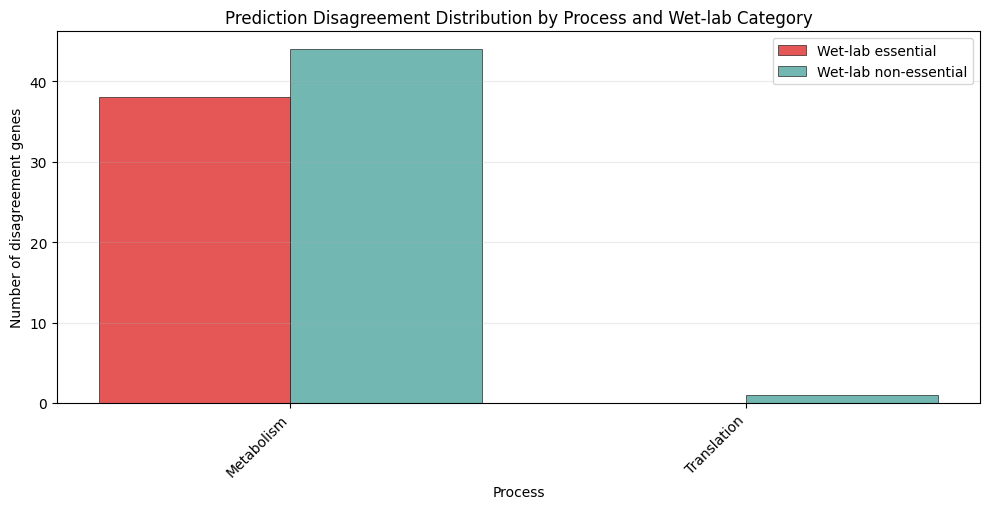

Current total genes: 462
Previous total genes: 462
Total number difference (abs): 0
Presence mismatch rows (only current + only previous): 0
Current mismatch count vs wet-lab: 94
Previous mismatch count vs wet-lab: 101
Mismatch difference (current - previous): -7
Prediction disagreement rows between current/previous: 83
Saved presence mismatch table: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_label_death_presence_mismatch_with_process_labels.csv
Saved prediction disagreement table: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_label_death_prediction_disagreement_with_process_labels.csv
Saved summary table: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_label_death_summary.csv
Saved disagreement process plot: /user/home/il22158/work/vEcoli/surrogate/comparison/current_vs_label_death_prediction_disagreement_by_process_and_category.png


,n_current_genes,n_previous_genes,total_number_difference_abs,n_only_current,n_only_previous,current_mismatch_count,previous_mismatch_count,mismatch_difference_current_minus_previous,mismatch_difference_abs,prediction_disagreement_count_between_models
0,462,462,0,0,0,94,101,-7,7,83


In [3]:
from pathlib import Path
import re
import zipfile
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- Paths ----------
current_path = Path('/user/home/il22158/work/vEcoli/surrogate/comparison/simulation_failure_compared_to_rosset_all_strains_M9.csv')
previous_path = Path('/user/home/il22158/work/vEcoli/surrogate/previous_study_wcm/wcm_label_death_vs_rousset_all_strains_m9.csv')
process_xlsx_path = Path('/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx')
out_dir = Path('/user/home/il22158/work/vEcoli/surrogate/comparison')
out_dir.mkdir(parents=True, exist_ok=True)

presence_diff_out = out_dir / 'current_vs_label_death_presence_mismatch_with_process_labels.csv'
prediction_diff_out = out_dir / 'current_vs_label_death_prediction_disagreement_with_process_labels.csv'
summary_out = out_dir / 'current_vs_label_death_summary.csv'
plot_out = out_dir / 'current_vs_label_death_prediction_disagreement_by_process_and_category.png'


def _canon(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(s).strip().lower())


def _find_col(df: pd.DataFrame, target_key: str):
    cmap = {_canon(c): c for c in df.columns}
    if target_key in cmap:
        return cmap[target_key]
    for k, v in cmap.items():
        if target_key in k or k in target_key:
            return v
    return None


def read_xlsx_without_openpyxl(path: str, required_header_keys=None) -> pd.DataFrame:
    required_header_keys = required_header_keys or []
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    def col_to_idx(cell_ref: str) -> int:
        col = ''.join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord('A') + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            sroot = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                parts = [t.text or '' for t in si.findall('.//a:t', ns)]
                shared_strings.append(''.join(parts))

        sheet_xml = ET.fromstring(zf.read('xl/worksheets/sheet1.xml'))
        parsed_rows = []
        for row in sheet_xml.findall('.//a:sheetData/a:row', ns):
            vals = {}
            for c in row.findall('a:c', ns):
                ref = c.attrib.get('r', '')
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get('t', '')
                v = c.find('a:v', ns)
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == 's' and raw.isdigit() and int(raw) < len(shared_strings):
                    vals[cidx] = shared_strings[int(raw)]
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    grid = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]

    header_idx = None
    req = [_canon(k) for k in required_header_keys]
    for i, row in enumerate(grid[:120]):
        row_keys = {_canon(x) for x in row if x is not None and str(x).strip() != ''}
        if req and all(any((rk == k) or (rk in k) or (k in rk) for k in row_keys) for rk in req):
            header_idx = i
            break
        if not req and len(row_keys) >= 3:
            header_idx = i
            break

    if header_idx is None:
        header_idx = 2 if len(grid) > 2 else 0

    header = [str(x).strip() if x is not None else '' for x in grid[header_idx]]
    data = grid[header_idx + 1 :]
    df = pd.DataFrame(data, columns=header)
    return df.dropna(axis=0, how='all').dropna(axis=1, how='all')


def to_bool_like(x):
    if pd.isna(x):
        return pd.NA
    s = str(x).strip().lower()
    if s in {'true', '1', 'yes', 'y', 'essential', 'failed', 'deadly_gene', 'deadly'}:
        return True
    if s in {'false', '0', 'no', 'n', 'non-essential', 'nonessential', 'unessential', 'successful', 'not_deadly'}:
        return False
    return pd.NA


# ---------- Load input tables ----------
current_df = pd.read_csv(current_path)
previous_df = pd.read_csv(previous_path)

# Build a common RNA-based key to compare both studies directly
curr_rna_col = _find_col(current_df, 'rnaid')
prev_rna_col = _find_col(previous_df, 'rnaid')
if curr_rna_col is None or prev_rna_col is None:
    raise KeyError(
        f'RNA ID column missing. current columns={list(current_df.columns)}, previous columns={list(previous_df.columns)}'
    )

current_df['RNA ID'] = current_df[curr_rna_col].astype(str).str.strip()
previous_df['RNA ID'] = previous_df[prev_rna_col].astype(str).str.strip()
current_df['gene_key'] = current_df['RNA ID'].str.replace(r'_RNA$', '', regex=True).str.strip().str.upper()
previous_df['gene_key'] = previous_df['RNA ID'].str.replace(r'_RNA$', '', regex=True).str.strip().str.upper()

# Normalize booleans
curr_fail_col = _find_col(current_df, 'failedbeforegen8') or 'failed_before_gen8'
if curr_fail_col not in current_df.columns:
    raise KeyError(f'Current file missing failed_before_gen8-like column. Columns: {list(current_df.columns)}')

if _find_col(previous_df, 'failedbeforegen8') in previous_df.columns or 'failed_before_gen8' in previous_df.columns:
    prev_fail_col = _find_col(previous_df, 'failedbeforegen8') or 'failed_before_gen8'
    previous_df['failed_bool'] = previous_df[prev_fail_col].map(to_bool_like)
elif 'label_death_bool' in previous_df.columns:
    previous_df['failed_bool'] = previous_df['label_death_bool'].map(to_bool_like)
elif 'overall_label_death' in previous_df.columns:
    previous_df['failed_bool'] = previous_df['overall_label_death'].map(to_bool_like)
else:
    raise KeyError(
        'Previous file has no failure-equivalent column. Expected one of: failed_before_gen8, label_death_bool, overall_label_death.'
    )

current_df['failed_bool'] = current_df[curr_fail_col].map(to_bool_like)

curr_match_col = _find_col(current_df, 'criteriamatch') or 'criteria_match'
prev_match_col = _find_col(previous_df, 'criteriamatch') or 'criteria_match'
curr_cat_col = _find_col(current_df, 'expectedcategory') or 'expected_category'
prev_cat_col = _find_col(previous_df, 'expectedcategory') or 'expected_category'

current_df['criteria_match_bool'] = current_df[curr_match_col].map(to_bool_like) if curr_match_col in current_df.columns else pd.NA
previous_df['criteria_match_bool'] = previous_df[prev_match_col].map(to_bool_like) if prev_match_col in previous_df.columns else pd.NA
current_df['expected_category'] = current_df[curr_cat_col] if curr_cat_col in current_df.columns else 'unknown'
previous_df['expected_category'] = previous_df[prev_cat_col] if prev_cat_col in previous_df.columns else 'unknown'

# Deduplicate per gene_key if needed
current_gene = (
    current_df.sort_values('RNA ID')
    .drop_duplicates('gene_key')
    [['gene_key', 'RNA ID', 'failed_bool', 'criteria_match_bool', 'expected_category']]
)
previous_gene = (
    previous_df.sort_values('RNA ID')
    .drop_duplicates('gene_key')
    [['gene_key', 'RNA ID', 'failed_bool', 'criteria_match_bool', 'expected_category']]
)

# ---------- Load process labels ----------
proc_df = read_xlsx_without_openpyxl(
    str(process_xlsx_path),
    required_header_keys=['rna id', 'process'],
)
proc_rna_col = _find_col(proc_df, 'rnaid')
proc_process_col = _find_col(proc_df, 'process')
if proc_rna_col is None or proc_process_col is None:
    raise KeyError(f'Could not find RNA ID/Process columns in process label file: {list(proc_df.columns)}')

proc_df = proc_df.rename(columns={proc_rna_col: 'RNA ID', proc_process_col: 'Process'})
proc_df['gene_key'] = proc_df['RNA ID'].astype(str).str.replace(r'_RNA$', '', regex=True).str.strip().str.upper()
proc_df = proc_df[['gene_key', 'RNA ID', 'Process']].drop_duplicates('gene_key')

# ---------- 1) Total number difference + presence mismatch table ----------
curr_keys = set(current_gene['gene_key'])
prev_keys = set(previous_gene['gene_key'])
only_current = sorted(curr_keys - prev_keys)
only_previous = sorted(prev_keys - curr_keys)

presence_diff = pd.DataFrame({
    'gene_key': only_current + only_previous,
    'presence_status': ['only_current'] * len(only_current) + ['only_previous'] * len(only_previous),
})
presence_diff = presence_diff.merge(
    current_gene.rename(columns={
        'RNA ID': 'current_RNA_ID',
        'failed_bool': 'current_failed_before_gen8',
        'criteria_match_bool': 'current_criteria_match',
        'expected_category': 'current_expected_category',
    }),
    on='gene_key',
    how='left',
)
presence_diff = presence_diff.merge(
    previous_gene.rename(columns={
        'RNA ID': 'previous_RNA_ID',
        'failed_bool': 'previous_failed_equivalent',
        'criteria_match_bool': 'previous_criteria_match',
        'expected_category': 'previous_expected_category',
    }),
    on='gene_key',
    how='left',
)
presence_diff = presence_diff.merge(proc_df[['gene_key', 'Process']], on='gene_key', how='left')
presence_diff['Process'] = presence_diff['Process'].fillna('Unknown')
presence_diff.to_csv(presence_diff_out, index=False)

# ---------- 2) Wet-lab mismatch difference ----------
current_mismatch_count = int((current_gene['criteria_match_bool'] == False).sum())
previous_mismatch_count = int((previous_gene['criteria_match_bool'] == False).sum())
mismatch_difference = current_mismatch_count - previous_mismatch_count

# ---------- 3) Difference between predictions + process distribution ----------
overlap = current_gene.merge(
    previous_gene,
    on='gene_key',
    how='inner',
    suffixes=('_current', '_previous'),
)
prediction_disagree = overlap[overlap['failed_bool_current'] != overlap['failed_bool_previous']].copy()
prediction_disagree['expected_category_for_plot'] = prediction_disagree['expected_category_current'].fillna('unknown')
prediction_disagree.loc[
    prediction_disagree['expected_category_for_plot'].isin(['', 'unknown', 'nan']),
    'expected_category_for_plot',
] = prediction_disagree['expected_category_previous']
prediction_disagree = prediction_disagree.merge(proc_df[['gene_key', 'Process']], on='gene_key', how='left')
prediction_disagree['Process'] = prediction_disagree['Process'].fillna('Unknown')
prediction_disagree.to_csv(prediction_diff_out, index=False)

valid_classes = ['expected_essential', 'expected_nonessential']
plot_df = prediction_disagree[prediction_disagree['expected_category_for_plot'].isin(valid_classes)].copy()
if not plot_df.empty:
    counts = (
        plot_df.groupby(['Process', 'expected_category_for_plot'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=valid_classes, fill_value=0)
)
    counts = counts.assign(_total=counts.sum(axis=1)).sort_values('_total', ascending=False).drop(columns=['_total'])
    x = np.arange(len(counts.index))
    bar_w = 0.42
    plt.figure(figsize=(max(10, 0.42 * len(counts.index) + 4), 5.2))
    plt.bar(x - bar_w / 2, counts['expected_essential'].values, width=bar_w, color='#E45756', edgecolor='black', linewidth=0.4, label='Wet-lab essential')
    plt.bar(x + bar_w / 2, counts['expected_nonessential'].values, width=bar_w, color='#72B7B2', edgecolor='black', linewidth=0.4, label='Wet-lab non-essential')
    plt.title('Prediction Disagreement Distribution by Process and Wet-lab Category')
    plt.xlabel('Process')
    plt.ylabel('Number of disagreement genes')
    plt.xticks(x, counts.index, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_out)
    plt.show()

summary_df = pd.DataFrame([
    {
        'n_current_genes': len(current_gene),
        'n_previous_genes': len(previous_gene),
        'total_number_difference_abs': abs(len(current_gene) - len(previous_gene)),
        'n_only_current': len(only_current),
        'n_only_previous': len(only_previous),
        'current_mismatch_count': current_mismatch_count,
        'previous_mismatch_count': previous_mismatch_count,
        'mismatch_difference_current_minus_previous': mismatch_difference,
        'mismatch_difference_abs': abs(mismatch_difference),
        'prediction_disagreement_count_between_models': len(prediction_disagree),
    }
])
summary_df.to_csv(summary_out, index=False)

print(f'Current total genes: {len(current_gene)}')
print(f'Previous total genes: {len(previous_gene)}')
print(f'Total number difference (abs): {abs(len(current_gene) - len(previous_gene))}')
print(f'Presence mismatch rows (only current + only previous): {len(presence_diff)}')
print(f'Current mismatch count vs wet-lab: {current_mismatch_count}')
print(f'Previous mismatch count vs wet-lab: {previous_mismatch_count}')
print(f'Mismatch difference (current - previous): {mismatch_difference}')
print(f'Prediction disagreement rows between current/previous: {len(prediction_disagree)}')
print(f'Saved presence mismatch table: {presence_diff_out}')
print(f'Saved prediction disagreement table: {prediction_diff_out}')
print(f'Saved summary table: {summary_out}')
print(f'Saved disagreement process plot: {plot_out}')

summary_df

# Growth rate analysis for failed/successful cell division

**Procedure**

- Keep all KO variants in the analysis, including those that failed before generation 8.
- Build failure labels from folder existence under out/{project}/success/.../generation=8 (missing folder = failed).
- Use baseline rows strictly from all_media_conditions* with variant=0 and label=baseline.
- Compute each run's growth-rate ratio relative to its seed baseline.
- Compare successful vs failed runs with scatter, box, and overlapping histogram+KDE plots before thresholding.

**KDE Method Explanation**

KDE is used in Plot 3 of Cell 4 to overlay smooth density curves on top of the success/failure histograms of mean growth-rate ratio.

Estimator used
For each group (Reached Gen8 and Failed < Gen8), the notebook estimates density with a Gaussian kernel:
$$\hat{f}(x)=\frac{1}{n h}\sum_{i=1}^{n} K\left(\frac{x-x_i}{h}\right),\quad K(u)=\frac{1}{\sqrt{2\pi}}e^{-u^2/2}$$

Implementation details in code
- Library: sklearn.neighbors.KernelDensity
- Kernel: gaussian
- Evaluation grid: 300 points between the global min and max of all growth-rate ratios (both groups combined).
- Preprocessing: values are converted to float and NaN values are removed before fitting.

Bandwidth choice
- Primary rule: Silverman-style rule of thumb
$$h = 1.06\,\sigma\,n^{-1/5}$$
where $\sigma$ is sample standard deviation and $n$ is group sample size.
- Fallback when variance is zero: use h = 0.05.
- Numerical floor: h is clipped to at least 1e-3.

Assumptions and consequences
- KDE is non-parametric: it does not assume a normal distribution for growth-rate ratios.
- Smoothness is controlled by bandwidth h; larger h gives smoother curves, smaller h gives noisier curves.
- The same kernel family (Gaussian) is used for both groups for fair visual comparison.
- If a group has fewer than 2 valid points, the code returns a zero-density curve (no meaningful KDE fit).
- Histograms are plotted with density=True and 30 bins, so histogram area and KDE curves are on comparable density scale.

## Inspect with data summaries

**Data**
- gene list:
/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt

- growth-rate summaries:
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed100_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed101_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed101_all.csv
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv

- explanation:
1. the single-knockout variants are saved in all four csv files, and the baseline simulation are the one labelled as baseline under "all media conditions..." simulation folder.
2. 2 baseline simulation (wildtype) can be found in /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv and /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv.

### Distogram of last generation

Table: KO run counts by last/longest generation (1-8).


,last_generation,n_runs
0,1,0
1,2,0
2,3,7
3,4,42
4,5,98
5,6,54
6,7,21
7,8,702


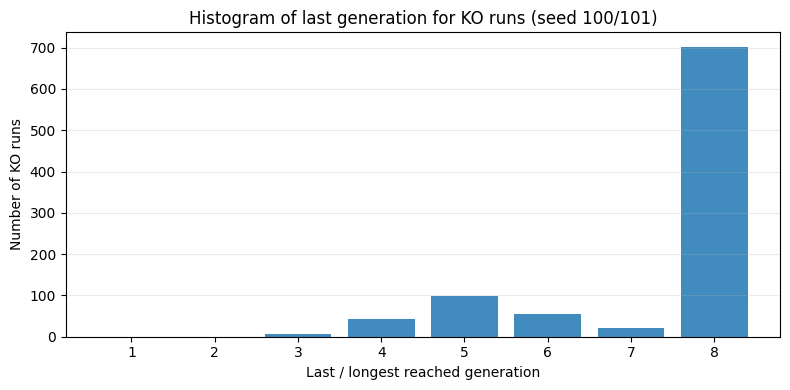

In [20]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Build histogram of last generation from existing KO detail output
# -------------------------
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

KO_DETAIL_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'
if not KO_DETAIL_PATH.exists():
    raise FileNotFoundError(
        f'Missing required file: {KO_DETAIL_PATH}. Run the KO summary cell first.'
    )

ko_df = pd.read_csv(KO_DETAIL_PATH)
required_cols = ['project', 'variant', 'lineage_seed']
for c in required_cols:
    if c not in ko_df.columns:
        raise KeyError(f"Column '{c}' not found in {KO_DETAIL_PATH}. Available columns: {list(ko_df.columns)}")

ko_df['lineage_seed'] = pd.to_numeric(ko_df['lineage_seed'], errors='coerce').astype('Int64')
ko_df['variant'] = pd.to_numeric(ko_df['variant'], errors='coerce').astype('Int64')

# KO-only seed scope requested: keep 100/101 (baseline seed 0 excluded)
ko_df = ko_df[ko_df['lineage_seed'].isin([100, 101])].copy()

# One row per KO simulation run
run_keys = (
    ko_df[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']]
    .dropna(subset=['project', 'variant', 'lineage_seed'])
    .copy()
)

# If max_success_generation is missing, rebuild from folders
if 'max_success_generation' not in run_keys.columns or run_keys['max_success_generation'].isna().all():
    OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')

    def generation_dir(project: str, variant: int, lineage_seed: int, generation: int) -> Path:
        return (
            OUT_ROOT
            / str(project)
            / 'success'
            / f'experiment_id={project}'
            / f'variant={int(variant)}'
            / f'lineage_seed={int(lineage_seed)}'
            / f'generation={int(generation)}'
        )

    def max_existing_generation(project: str, variant: int, lineage_seed: int, max_gen: int = 8) -> int:
        for g in range(max_gen, 0, -1):
            if generation_dir(project, variant, lineage_seed, g).exists():
                return g
        return 0

    base_runs = run_keys[['project', 'variant', 'lineage_seed', 'gene_id']].drop_duplicates().copy()
    base_runs['project'] = base_runs['project'].astype(str)
    base_runs['variant'] = base_runs['variant'].astype(int)
    base_runs['lineage_seed'] = base_runs['lineage_seed'].astype(int)
    base_runs['max_success_generation'] = [
        max_existing_generation(r.project, r.variant, r.lineage_seed, max_gen=8)
        for r in base_runs.itertuples(index=False)
    ]
    run_keys = base_runs
else:
    run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').fillna(0).astype(int)
    run_keys = run_keys[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']].drop_duplicates().copy()

# Histogram for generation 1..8
hist_df = run_keys[run_keys['max_success_generation'].between(1, 8)].copy()
missing_all = int((run_keys['max_success_generation'] == 0).sum())
if missing_all > 0:
    print(f'Runs with no detected success generation folder (0): {missing_all}')

counts = (
    hist_df['max_success_generation']
    .value_counts()
    .reindex(range(1, 9), fill_value=0)
    .rename_axis('last_generation')
    .reset_index(name='n_runs')
)

print('Table: KO run counts by last/longest generation (1-8).')
display(counts)

plt.figure(figsize=(8, 4))
plt.bar(counts['last_generation'], counts['n_runs'], color='#1f77b4', alpha=0.85)
plt.xticks(range(1, 9))
plt.xlabel('Last / longest reached generation')
plt.ylabel('Number of KO runs')
plt.title('Histogram of last generation for KO runs (seed 100/101)')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

Table: KO run counts by last/longest generation (1-7).


,last_generation,n_runs
0,1,0
1,2,0
2,3,7
3,4,42
4,5,98
5,6,54
6,7,21


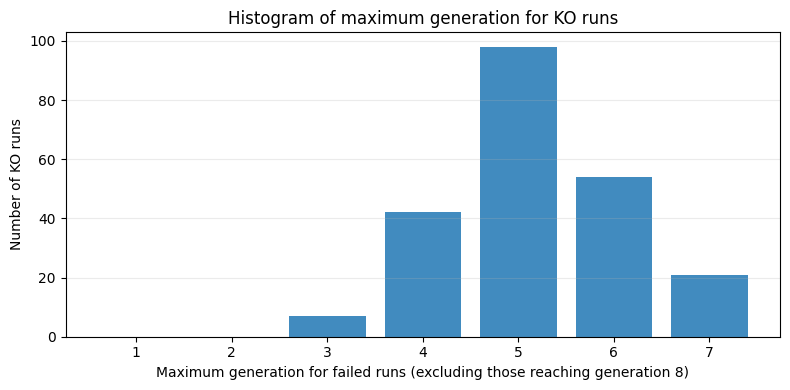

In [21]:
"""Same plot bot excluding the ones successfully reaching generation 8, to focus on the earlier failures"""
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Build histogram of last generation from existing KO detail output
# -------------------------
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

KO_DETAIL_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'
if not KO_DETAIL_PATH.exists():
    raise FileNotFoundError(
        f'Missing required file: {KO_DETAIL_PATH}. Run the KO summary cell first.'
    )

ko_df = pd.read_csv(KO_DETAIL_PATH)
required_cols = ['project', 'variant', 'lineage_seed']
for c in required_cols:
    if c not in ko_df.columns:
        raise KeyError(f"Column '{c}' not found in {KO_DETAIL_PATH}. Available columns: {list(ko_df.columns)}")

ko_df['lineage_seed'] = pd.to_numeric(ko_df['lineage_seed'], errors='coerce').astype('Int64')
ko_df['variant'] = pd.to_numeric(ko_df['variant'], errors='coerce').astype('Int64')

# KO-only seed scope requested: keep 100/101 (baseline seed 0 excluded)
ko_df = ko_df[ko_df['lineage_seed'].isin([100, 101])].copy()

# One row per KO simulation run
run_keys = (
    ko_df[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']]
    .dropna(subset=['project', 'variant', 'lineage_seed'])
    .copy()
)

# If max_success_generation is missing, rebuild from folders
if 'max_success_generation' not in run_keys.columns or run_keys['max_success_generation'].isna().all():
    OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')

    def generation_dir(project: str, variant: int, lineage_seed: int, generation: int) -> Path:
        return (
            OUT_ROOT
            / str(project)
            / 'success'
            / f'experiment_id={project}'
            / f'variant={int(variant)}'
            / f'lineage_seed={int(lineage_seed)}'
            / f'generation={int(generation)}'
        )

    def max_existing_generation(project: str, variant: int, lineage_seed: int, max_gen: int = 8) -> int:
        for g in range(max_gen, 0, -1):
            if generation_dir(project, variant, lineage_seed, g).exists():
                return g
        return 0

    base_runs = run_keys[['project', 'variant', 'lineage_seed', 'gene_id']].drop_duplicates().copy()
    base_runs['project'] = base_runs['project'].astype(str)
    base_runs['variant'] = base_runs['variant'].astype(int)
    base_runs['lineage_seed'] = base_runs['lineage_seed'].astype(int)
    base_runs['max_success_generation'] = [
        max_existing_generation(r.project, r.variant, r.lineage_seed, max_gen=8)
        for r in base_runs.itertuples(index=False)
    ]
    run_keys = base_runs
else:
    run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').fillna(0).astype(int)
    run_keys = run_keys[['project', 'variant', 'lineage_seed', 'gene_id', 'max_success_generation']].drop_duplicates().copy()

# Histogram for generation 1..8
hist_df = run_keys[run_keys['max_success_generation'].between(1, 7)].copy()
missing_all = int((run_keys['max_success_generation'] == 0).sum())
if missing_all > 0:
    print(f'Runs with no detected success generation folder (0): {missing_all}')

counts = (
    hist_df['max_success_generation']
    .value_counts()
    .reindex(range(1, 8), fill_value=0)
    .rename_axis('last_generation')
    .reset_index(name='n_runs')
)

print('Table: KO run counts by last/longest generation (1-7).')
display(counts)

plt.figure(figsize=(8, 4))
plt.bar(counts['last_generation'], counts['n_runs'], color='#1f77b4', alpha=0.85)
plt.xticks(range(1, 8))
plt.xlabel('Maximum generation for failed runs (excluding those reaching generation 8)')
plt.ylabel('Number of KO runs')
plt.title('Histogram of maximum generation for KO runs')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ko_run_last_generation_histogram_excluding_gen8.png')
plt.show()

### Distogram of mean growth rate and mass fold change

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd

# -------------------------
# Inspect growth-rate unit from raw simulation data and convert to per-hour
# -------------------------
OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

KO_DETAIL_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'
if not KO_DETAIL_PATH.exists():
    raise FileNotFoundError(
        f'Missing {KO_DETAIL_PATH}. Run the KO summary analysis cell first.'
    )

ko_detail = pd.read_csv(KO_DETAIL_PATH)
required_cols = ['project', 'variant', 'lineage_seed']
missing_cols = [c for c in required_cols if c not in ko_detail.columns]
if missing_cols:
    raise KeyError(f'Missing columns in {KO_DETAIL_PATH}: {missing_cols}')

# Keep KO run seeds only (100, 101)
ko_detail['lineage_seed'] = pd.to_numeric(ko_detail['lineage_seed'], errors='coerce')
ko_detail['variant'] = pd.to_numeric(ko_detail['variant'], errors='coerce')
ko_runs = ko_detail[ko_detail['lineage_seed'].isin([100, 101])].dropna(subset=['project', 'variant', 'lineage_seed']).copy()
if ko_runs.empty:
    raise RuntimeError('No KO runs found for lineage_seed in [100, 101].')

sample = ko_runs[['project', 'variant', 'lineage_seed']].drop_duplicates().iloc[0]
project = str(sample['project'])
variant = int(sample['variant'])
lineage_seed = int(sample['lineage_seed'])

raw_base = (
    OUT_ROOT
    / project
    / 'history'
    / f'experiment_id={project}'
    / f'variant={variant}'
    / f'lineage_seed={lineage_seed}'
)
raw_files = sorted(raw_base.glob('generation=*/agent_id=*/**/*.pq'))
if not raw_files:
    raise RuntimeError(f'No raw pq files found under: {raw_base}')

raw_df = pd.read_parquet(raw_files[0])
if 'time' not in raw_df.columns or 'listeners__mass__instantaneous_growth_rate' not in raw_df.columns:
    raise KeyError(
        "Raw pq file missing required columns 'time' and/or 'listeners__mass__instantaneous_growth_rate'."
    )

time_s = pd.to_numeric(raw_df['time'], errors='coerce')
inst_rate = pd.to_numeric(raw_df['listeners__mass__instantaneous_growth_rate'], errors='coerce')

dt = np.diff(time_s.dropna().values)
dt = dt[np.isfinite(dt) & (dt > 0)]
median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

# Consistency check against d(log(mass))/dt when dry mass is available
ratio_msg = 'Dry-mass consistency check not available.'
if 'listeners__mass__dry_mass' in raw_df.columns:
    dry_mass = pd.to_numeric(raw_df['listeners__mass__dry_mass'], errors='coerce').values
    t = time_s.values
    r = inst_rate.values
    valid = np.isfinite(dry_mass) & (dry_mass > 0) & np.isfinite(t) & np.isfinite(r)
    dry_mass = dry_mass[valid]
    t = t[valid]
    r = r[valid]
    if len(dry_mass) >= 3:
        dlogm = np.diff(np.log(dry_mass))
        dt_local = np.diff(t)
        empirical = np.divide(dlogm, dt_local, out=np.full_like(dlogm, np.nan, dtype=float), where=dt_local > 0)
        common = np.isfinite(empirical) & np.isfinite(r[1:])
        if common.any():
            med_ratio = float(np.nanmedian(r[1:][common] / empirical[common]))
            ratio_msg = f"Median(inst_rate / dlogM_dt) = {med_ratio:.3f} (near 1 means inst_rate is in 1/time-unit)."

# Infer conversion to per-hour
median_abs_rate = float(np.nanmedian(np.abs(inst_rate.values[np.isfinite(inst_rate.values)])))
if 0.02 <= median_abs_rate <= 10:
    unit_guess = 'already_per_hour'
    to_per_hour = 1.0
elif 0.00001 <= median_abs_rate < 0.02:
    # Typical for 1/s growth rates in bacterial simulations
    unit_guess = 'per_second'
    to_per_hour = 3600.0
else:
    # Conservative fallback for ambiguous magnitudes
    unit_guess = 'assume_per_second'
    to_per_hour = 3600.0

print(f'Sample run for unit inspection: project={project}, variant={variant}, seed={lineage_seed}')
print(f'Sample raw file: {raw_files[0]}')
print(f'Median simulation dt from raw file: {median_dt:.3f}')
print(f'Median |instantaneous_growth_rate| in raw file: {median_abs_rate:.6g}')
print(ratio_msg)
print(f'Unit guess: {unit_guess}; conversion factor to per-hour = {to_per_hour}')

# Convert growth-rate columns used in previous analysis
if 'mean_growth_rate' in ko_detail.columns:
    ko_detail['mean_growth_rate_per_hr'] = pd.to_numeric(ko_detail['mean_growth_rate'], errors='coerce') * to_per_hour
if 'seed_baseline_mean_growth_rate' in ko_detail.columns:
    ko_detail['seed_baseline_mean_growth_rate_per_hr'] = (
        pd.to_numeric(ko_detail['seed_baseline_mean_growth_rate'], errors='coerce') * to_per_hour
    )

# Ratios are dimensionless and remain unchanged
out_path = OUT_DIR / 'ko_runs_with_success_generation_per_hr.csv'
ko_detail.to_csv(out_path, index=False)
print(f'Saved converted table: {out_path}')

show_cols = [c for c in [
    'project',
    'variant',
    'lineage_seed',
    'mean_growth_rate',
    'mean_growth_rate_per_hr',
    'seed_baseline_mean_growth_rate',
    'seed_baseline_mean_growth_rate_per_hr',
    'mean_growth_rate_ratio',
    'max_success_generation',
] if c in ko_detail.columns]

print('Preview of converted values:')
display(ko_detail[show_cols].head(10))

Sample run for unit inspection: project=gene_ko_441imported_2seeds, variant=1, seed=100
Sample raw file: /user/home/il22158/work/vEcoli/out/gene_ko_441imported_2seeds/history/experiment_id=gene_ko_441imported_2seeds/variant=1/lineage_seed=100/generation=1/agent_id=0/204.pq
Median simulation dt from raw file: 20.000
Median |instantaneous_growth_rate| in raw file: 0.000276136
Median(inst_rate / dlogM_dt) = 1.001 (near 1 means inst_rate is in 1/time-unit).
Unit guess: per_second; conversion factor to per-hour = 3600.0
Saved converted table: /user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation_per_hr.csv
Preview of converted values:


,project,variant,lineage_seed,mean_growth_rate,mean_growth_rate_per_hr,seed_baseline_mean_growth_rate,seed_baseline_mean_growth_rate_per_hr,mean_growth_rate_ratio,max_success_generation
0,gene_ko_441imported_2seeds,1,100,0.000189,0.680705,0.000231,0.830272,0.819858,8
1,gene_ko_441imported_2seeds,2,100,0.000152,0.546511,0.000231,0.830272,0.658231,5
2,gene_ko_441imported_2seeds,3,100,0.000192,0.690630,0.000231,0.830272,0.831812,8
3,gene_ko_441imported_2seeds,4,100,0.000193,0.694245,0.000231,0.830272,0.836166,8
4,gene_ko_441imported_2seeds,5,100,0.000211,0.758633,0.000231,0.830272,0.913717,8
5,gene_ko_441imported_2seeds,6,100,0.000087,0.313414,0.000231,0.830272,0.377483,3
6,gene_ko_441imported_2seeds,7,100,0.000310,1.116969,0.000231,0.830272,1.345305,4
7,gene_ko_441imported_2seeds,8,100,0.000213,0.765255,0.000231,0.830272,0.921692,6
8,gene_ko_441imported_2seeds,9,100,0.000208,0.747315,0.000231,0.830272,0.900084,8
9,gene_ko_441imported_2seeds,10,100,0.000190,0.685179,0.000231,0.830272,0.825247,8


KO samples used: 924
Data range: min=0.2715, max=2.2175 (1/hr)
Centered axis: center=1.2445, xmin=0.2445, xmax=2.2445, bin_step=0.05, label_step=0.25
Table: number of simulations in each growth-rate bin.


,bin_left,bin_right,bin_center,n_simulations
0,0.174,0.225,0.1995,0
1,0.225,0.275,0.2500,4
2,0.275,0.325,0.3000,32
3,0.325,0.375,0.3500,48
4,0.375,0.425,0.4000,30
5,0.425,0.475,0.4500,7
6,0.475,0.525,0.5000,7
7,0.525,0.575,0.5500,9
8,0.575,0.625,0.6000,1
9,0.625,0.675,0.6500,56


Bins with exactly 1 run: 9 | bins with 2-3 runs: 1


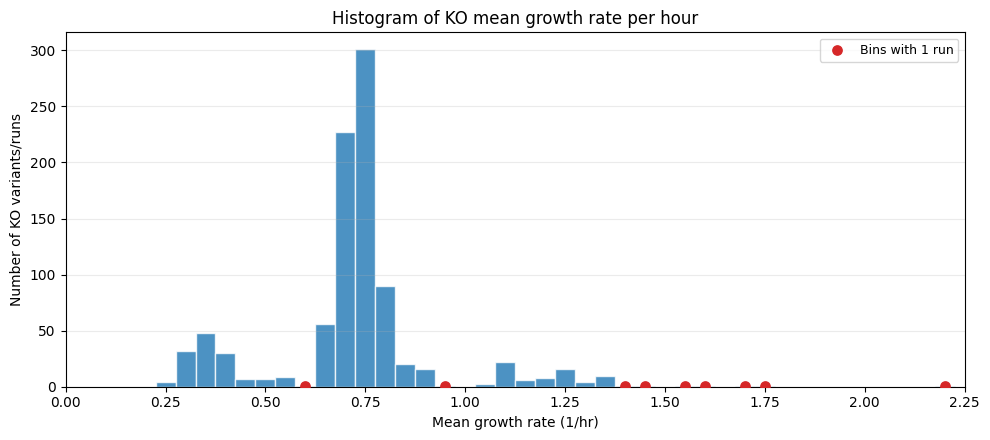

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Histogram of KO mean growth rate in per-hour unit
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
PER_HR_PATH = OUT_DIR / 'ko_runs_with_success_generation_per_hr.csv'
BASE_PATH = OUT_DIR / 'ko_runs_with_success_generation.csv'

if PER_HR_PATH.exists():
    df = pd.read_csv(PER_HR_PATH)
elif BASE_PATH.exists():
    df = pd.read_csv(BASE_PATH)
    if 'mean_growth_rate' not in df.columns:
        raise KeyError(f"'mean_growth_rate' not found in {BASE_PATH}")
    # Fallback conversion from 1/s to 1/hr when per-hour file is not yet generated.
    df['mean_growth_rate_per_hr'] = pd.to_numeric(df['mean_growth_rate'], errors='coerce') * 3600.0
    print('Info: per-hour file not found; converted mean_growth_rate to per hour using x3600.')
else:
    raise FileNotFoundError(f'Neither {PER_HR_PATH} nor {BASE_PATH} exists.')

if 'mean_growth_rate_per_hr' not in df.columns:
    raise KeyError("'mean_growth_rate_per_hr' column is required.")

# KO seed scope used in previous analysis
if 'lineage_seed' in df.columns:
    seed_num = pd.to_numeric(df['lineage_seed'], errors='coerce')
    df = df[seed_num.isin([100, 101])].copy()

x = pd.to_numeric(df['mean_growth_rate_per_hr'], errors='coerce').dropna()
x = x[np.isfinite(x)]
if x.empty:
    raise RuntimeError('No valid mean_growth_rate_per_hr values found for plotting.')

x_min = float(x.min())
x_max = float(x.max())
x_center = 0.5 * (x_min + x_max)

step = 0.05
half_span = max(x_center - x_min, x_max - x_center)
half_span_aligned = np.ceil(half_span / step) * step
xmin_plot = x_center - half_span_aligned
xmax_plot = x_center + half_span_aligned

# Bin edges so that bin centers align to 0.05 grid
center_anchor = np.round(x_center / step) * step
left_center = center_anchor + np.floor((xmin_plot - center_anchor) / step) * step
right_center = center_anchor + np.ceil((xmax_plot - center_anchor) / step) * step
centers = np.arange(left_center, right_center + 0.05 * step, step)
bin_edges = np.r_[centers - step / 2, centers[-1] + step / 2]

# Show x-axis labels in wider spacing for readability
tick_step = 0.25
tick_start = np.floor(xmin_plot / tick_step) * tick_step
tick_end = np.ceil(xmax_plot / tick_step) * tick_step
x_ticks = np.arange(tick_start, tick_end + 0.5 * tick_step, tick_step)

# Table: number of simulations in each histogram bin
bin_cats = pd.cut(x, bins=bin_edges, include_lowest=True, right=True)
bin_counts = bin_cats.value_counts(sort=False).reset_index()
bin_counts.columns = ['bin_interval', 'n_simulations']
bin_counts['bin_left'] = bin_counts['bin_interval'].map(lambda iv: iv.left).astype(float)
bin_counts['bin_right'] = bin_counts['bin_interval'].map(lambda iv: iv.right).astype(float)
bin_counts['bin_center'] = ((bin_counts['bin_left'] + bin_counts['bin_right']) / 2.0).astype(float)
bin_counts = bin_counts[['bin_left', 'bin_right', 'bin_center', 'n_simulations']]

# Highlight sparse bins so count=1 bars are visible on top of high-count bins
single_bins = bin_counts[bin_counts['n_simulations'] == 1].copy()
few_bins = bin_counts[(bin_counts['n_simulations'] > 1) & (bin_counts['n_simulations'] <= 3)].copy()

print(f'KO samples used: {len(x)}')
print(f'Data range: min={x_min:.4f}, max={x_max:.4f} (1/hr)')
print(f'Centered axis: center={x_center:.4f}, xmin={xmin_plot:.4f}, xmax={xmax_plot:.4f}, bin_step={step}, label_step={tick_step}')
print('Table: number of simulations in each growth-rate bin.')
display(bin_counts)
print(f'Bins with exactly 1 run: {len(single_bins)} | bins with 2-3 runs: {len(few_bins)}')

plt.figure(figsize=(10, 4.5))
plt.hist(x.values, bins=bin_edges, color='#1f77b4', alpha=0.8, edgecolor='white')

if len(single_bins) > 0:
    plt.scatter(
        single_bins['bin_center'].values,
        single_bins['n_simulations'].values,
        color='#d62728',
        s=45,
        marker='o',
        zorder=4,
        label='Bins with 1 run',
    )
# if len(few_bins) > 0:
#     plt.scatter(
#         few_bins['bin_center'].values,
#         few_bins['n_simulations'].values,
#         color='#ff7f0e',
#         s=35,
#         marker='^',
#         zorder=4,
#         label='Bins with 2-3 runs',
#     )

plt.xlim(xmin_plot, xmax_plot)
plt.xticks(x_ticks)
plt.xlabel('Mean growth rate (1/hr)')
plt.ylabel('Number of KO variants/runs')
plt.title('Histogram of KO mean growth rate per hour')
if (len(single_bins) > 0) or (len(few_bins) > 0):
    plt.legend(loc='upper right', fontsize=9)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ko_mean_growth_rate_per_hr_histogram.png')
plt.show()

Expected KO genes from list: 462
Observed KO genes in summaries (after list filter): 462
Table: baseline growth-rate reference by lineage seed (0 and 100).


,lineage_seed,seed_baseline_mean_growth_rate
0,0,0.000226
1,100,0.000235


Holistic baseline mean growth rate (mean of seeds 0 and 100): 0.000231
Loaded KO rows: 924
Unique KO genes (final): 462
Runs with generation=8 folder: 702 / 924
Failure rate (run-level): 0.2403
Failure rate (gene-level any-seed): 0.2532
Table: gene-level aggregate summary of KO growth and failure statistics across runs/seeds.


,gene_id,mean_growth_rate,mean_growth_rate_ratio,std_growth_rate,failed_before_gen8,fail_rate,n_runs,mean_success_generation
0,EG10001,0.000230,0.997648,0.000005,0,0.0,2,8.0
1,EG10004,0.000238,1.033866,0.000003,0,0.0,2,8.0
2,EG10006,0.000211,0.915048,0.000011,0,0.0,2,8.0
3,EG10007,0.000201,0.869981,0.000001,0,0.0,2,8.0
4,EG10012,0.000208,0.901152,0.000005,0,0.0,2,8.0
5,EG10016,0.000234,1.015461,0.000005,0,0.0,2,8.0
6,EG10017,0.000214,0.926616,0.000008,0,0.0,2,8.0
7,EG10022,0.000204,0.885255,0.000016,0,0.0,2,8.0
8,EG10023,0.000204,0.885255,0.000016,0,0.0,2,8.0
9,EG10024,0.000201,0.873308,0.000009,0,0.0,2,8.0


Table: run-level growth-rate ratio distribution summary for success vs failure groups.


,status,count,mean,std,median,min,max
0,Failed<Gen8,222,0.842936,0.497685,0.504972,0.326958,2.085727
1,ReachedGen8,702,0.884164,0.093936,0.883817,0.470864,2.670818


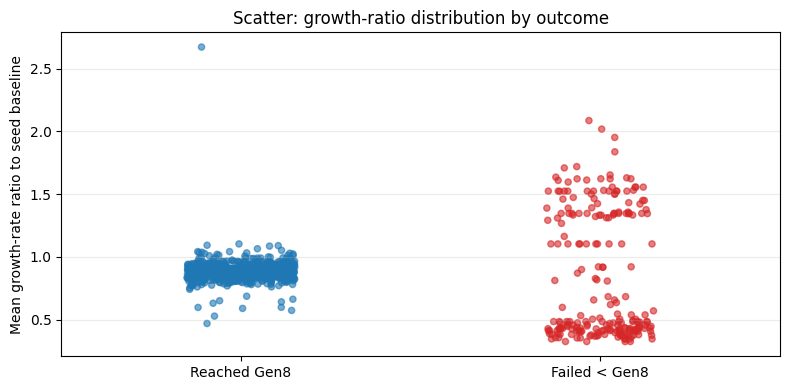

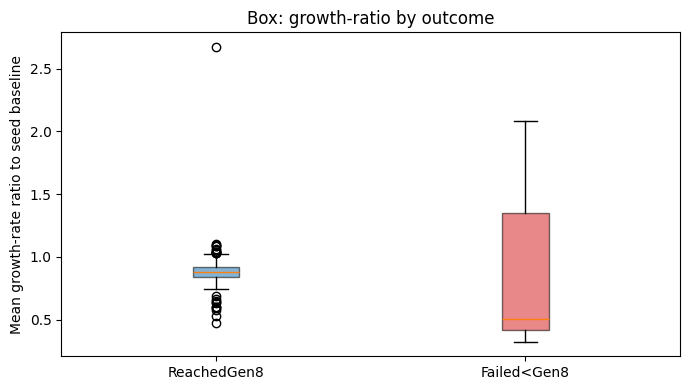

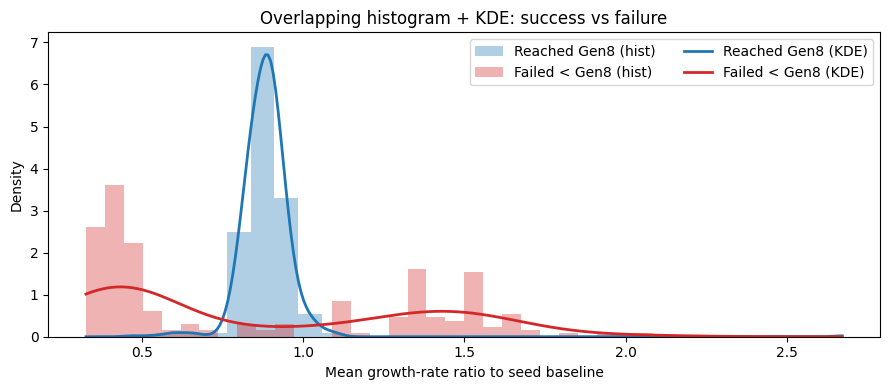

Saved: /user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

# -------------------------
# Paths from markdown "Data" section
# -------------------------
OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')
GENE_LIST_PATH = Path('/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt')
SUMMARY_FILE_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed100_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_441_KOs_seed101_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed101_all.csv'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv'),
]
OUT_DIR = Path('/user/home/il22158/work/vEcoli/surrogate/results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Load expected KO gene list (462 unique genes expected)
# -------------------------
gene_df = pd.read_csv(GENE_LIST_PATH, header=None, names=['gene_id'])
gene_df['gene_id'] = gene_df['gene_id'].astype(str).str.strip()
gene_df = gene_df[gene_df['gene_id'] != ''].drop_duplicates().reset_index(drop=True)
expected_ko_genes = gene_df['gene_id'].nunique()
print(f'Expected KO genes from list: {expected_ko_genes}')

# -------------------------
# Load ALL summary files and split KO rows + baseline rows
# -------------------------
all_frames = []
for fp in SUMMARY_FILE_PATHS:
    df = pd.read_csv(fp)
    df['source_file'] = fp.name
    all_frames.append(df)

all_df = pd.concat(all_frames, ignore_index=True)

# KO rows are in all four files according to markdown
ko_df = all_df[all_df['label'].astype(str).str.startswith('KO:')].copy()
ko_df['gene_id'] = ko_df['label'].astype(str).str.extract(r'KO:\s*([^,\s]+)')[0]
ko_df = ko_df.dropna(subset=['gene_id'])

# Keep KO genes that are present in the provided KO gene list
ko_df = ko_df[ko_df['gene_id'].isin(gene_df['gene_id'])].copy()
observed_ko_genes = ko_df['gene_id'].nunique()
print(f'Observed KO genes in summaries (after list filter): {observed_ko_genes}')
if observed_ko_genes != expected_ko_genes:
    missing = sorted(set(gene_df['gene_id']) - set(ko_df['gene_id']))
    print(f'Warning: {expected_ko_genes - observed_ko_genes} expected KO genes are missing from the loaded summaries.')
    print('First missing genes:', missing[:15])

# If lineage_seed is not present in csv, infer from source filename
if 'lineage_seed' not in ko_df.columns:
    ko_df['lineage_seed'] = ko_df['source_file'].str.extract(r'seed(\d+)')[0]
    ko_df.loc[ko_df['lineage_seed'].isna() & ko_df['source_file'].str.contains('default', case=False, na=False), 'lineage_seed'] = '0'
ko_df['lineage_seed'] = pd.to_numeric(ko_df['lineage_seed'], errors='coerce').astype('Int64')
ko_df = ko_df[ko_df['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows
ko_df['variant'] = pd.to_numeric(ko_df['variant'], errors='coerce').astype('Int64')

# -------------------------
# Baseline rows: strict selection from all_media_conditions* variant=0 label=baseline
# -------------------------
baseline_df = all_df.copy()
if 'lineage_seed' not in baseline_df.columns:
    baseline_df['lineage_seed'] = baseline_df['source_file'].str.extract(r'seed(\d+)')[0]
    baseline_df.loc[baseline_df['lineage_seed'].isna() & baseline_df['source_file'].str.contains('default', case=False, na=False), 'lineage_seed'] = '0'
else:
    inferred_seed = baseline_df['source_file'].str.extract(r'seed(\d+)')[0]
    baseline_df['lineage_seed'] = baseline_df['lineage_seed'].fillna(inferred_seed)
    baseline_df.loc[baseline_df['lineage_seed'].isna() & baseline_df['source_file'].str.contains('default', case=False, na=False), 'lineage_seed'] = '0'
baseline_df['lineage_seed'] = pd.to_numeric(baseline_df['lineage_seed'], errors='coerce')
baseline_df['variant'] = pd.to_numeric(baseline_df.get('variant'), errors='coerce')

label_series = baseline_df['label'].astype(str).str.strip().str.lower()
project_series = baseline_df['project'].astype(str).str.strip()
baseline_mask = (
    label_series.eq('baseline')
    & project_series.str.startswith('all_media_conditions')
    & baseline_df['variant'].eq(0)
)

baseline_df = baseline_df.loc[baseline_mask, ['lineage_seed', 'mean_growth_rate', 'project', 'variant', 'label']].copy()
if baseline_df.empty:
    raise RuntimeError(
        'No valid baseline rows found. Expected rows with label=baseline, project starting with all_media_conditions, and variant=0.'
    )

baseline_df = baseline_df.dropna(subset=['lineage_seed'])
baseline_df = baseline_df[baseline_df['lineage_seed'].isin([0, 100])].copy()
baseline_df = (
    baseline_df.groupby('lineage_seed', as_index=False)['mean_growth_rate']
    .mean()
    .rename(columns={'mean_growth_rate': 'seed_baseline_mean_growth_rate'})
)
baseline_rows = []
for seed in [0, 100]:
    values = baseline_df.loc[baseline_df['lineage_seed'] == seed, 'seed_baseline_mean_growth_rate']
    baseline_rows.append({'lineage_seed': seed, 'seed_baseline_mean_growth_rate': values.iloc[0] if len(values) > 0 else np.nan})
baseline_df = pd.DataFrame(baseline_rows)
if baseline_df['seed_baseline_mean_growth_rate'].isna().any():
    raise RuntimeError('Missing baseline rows for lineage_seed 0 and/or 100. Check baseline source files and labels.')
holistic_baseline_mean_growth_rate = float(baseline_df['seed_baseline_mean_growth_rate'].mean())

print('Table: baseline growth-rate reference by lineage seed (0 and 100).')
display(baseline_df)
print(f'Holistic baseline mean growth rate (mean of seeds 0 and 100): {holistic_baseline_mean_growth_rate:.6f}')

# Use one holistic baseline (mean of seeds 0 and 100) for all KO variants
ko_df['seed_baseline_mean_growth_rate'] = holistic_baseline_mean_growth_rate
ko_df['mean_growth_rate_ratio'] = ko_df['mean_growth_rate'] / ko_df['seed_baseline_mean_growth_rate']

missing_baseline = int(ko_df['seed_baseline_mean_growth_rate'].isna().sum())
if missing_baseline > 0:
    print(f'Warning: {missing_baseline} KO rows have no matched baseline seed; ratio is NaN for these rows.')

# -------------------------
# Filesystem-based success labeling (generation=8 folder existence)
# -------------------------
def generation_dir(project: str, variant: int, lineage_seed: int, generation: int) -> Path:
    return (
        OUT_ROOT
        / str(project)
        / 'success'
        / f'experiment_id={project}'
        / f'variant={int(variant)}'
        / f'lineage_seed={int(lineage_seed)}'
        / f'generation={int(generation)}'
    )

def max_existing_generation(project: str, variant: int, lineage_seed: int, max_gen: int = 8) -> int:
    for g in range(max_gen, 0, -1):
        if generation_dir(project, variant, lineage_seed, g).exists():
            return g
    return 0

def has_gen8_folder(project: str, variant: int, lineage_seed: int) -> int:
    return int(generation_dir(project, variant, lineage_seed, 8).exists())

key_cols = ['project', 'variant', 'lineage_seed']
run_keys = ko_df[key_cols].drop_duplicates().dropna().copy()
run_keys['project'] = run_keys['project'].astype(str)
run_keys['variant'] = run_keys['variant'].astype(int)
run_keys['lineage_seed'] = run_keys['lineage_seed'].astype(int)

run_keys['reached_gen8_by_folder'] = run_keys.apply(
    lambda r: has_gen8_folder(r['project'], r['variant'], r['lineage_seed']),
    axis=1,
 )
run_keys['max_success_generation'] = run_keys.apply(
    lambda r: max_existing_generation(r['project'], r['variant'], r['lineage_seed'], max_gen=8),
    axis=1,
 )
run_keys['failed_before_gen8'] = (run_keys['reached_gen8_by_folder'] == 0).astype(int)

ko_df = ko_df.merge(
    run_keys[['project', 'variant', 'lineage_seed', 'reached_gen8_by_folder', 'max_success_generation', 'failed_before_gen8']],
    on=['project', 'variant', 'lineage_seed'],
    how='left',
)

# Aggregate by gene for stable reporting
agg = (
    ko_df.groupby(['gene_id'], as_index=False)
    .agg(
        mean_growth_rate=('mean_growth_rate', 'mean'),
        mean_growth_rate_ratio=('mean_growth_rate_ratio', 'mean'),
        std_growth_rate=('mean_growth_rate', 'std'),
        failed_before_gen8=('failed_before_gen8', 'max'),
        fail_rate=('failed_before_gen8', 'mean'),
        n_runs=('gene_id', 'size'),
        mean_success_generation=('max_success_generation', 'mean'),
    )
)
agg['std_growth_rate'] = agg['std_growth_rate'].fillna(0.0)

print('Loaded KO rows:', len(ko_df))
print('Unique KO genes (final):', agg['gene_id'].nunique())
print('Runs with generation=8 folder:', int(run_keys['reached_gen8_by_folder'].sum()), '/', len(run_keys))
print('Failure rate (run-level):', round(ko_df['failed_before_gen8'].mean(), 4))
print('Failure rate (gene-level any-seed):', round(agg['failed_before_gen8'].mean(), 4))

print('Table: gene-level aggregate summary of KO growth and failure statistics across runs/seeds.')
display(agg.head(10))

# -------------------------
# Visual comparison before thresholding
# -------------------------
plot_df = ko_df[['mean_growth_rate_ratio', 'failed_before_gen8']].dropna().copy()
if plot_df.empty:
    raise RuntimeError('No valid growth-rate ratios were produced. Check baseline matching by lineage_seed.')
plot_df['failed_before_gen8'] = plot_df['failed_before_gen8'].astype(int)
plot_df['status'] = np.where(plot_df['failed_before_gen8'] == 1, 'Failed<Gen8', 'ReachedGen8')

group_stats = (
    plot_df.groupby('status')['mean_growth_rate_ratio']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
print('Table: run-level growth-rate ratio distribution summary for success vs failure groups.')
display(group_stats)

# Plot 1: scatter with centered groups + jitter
rng = np.random.default_rng(42)
centers = np.where(plot_df['failed_before_gen8'].values == 1, 0.2, -0.2)
x = centers + rng.uniform(-0.06, 0.06, size=len(plot_df))
plt.figure(figsize=(8, 4))
colors = np.where(plot_df['failed_before_gen8'].values == 1, '#d62728', '#1f77b4')
plt.scatter(x, plot_df['mean_growth_rate_ratio'].values, c=colors, alpha=0.6, s=20)
plt.xticks([-0.2, 0.2], ['Reached Gen8', 'Failed < Gen8'])
plt.xlim(-0.4, 0.4)
plt.ylabel('Mean growth-rate ratio to seed baseline')
plt.title('Scatter: growth-ratio distribution by outcome')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: box plot
ordered = group_stats.set_index('status').reindex(['ReachedGen8', 'Failed<Gen8']).reset_index()
plt.figure(figsize=(7, 4))
box_data = [
    plot_df.loc[plot_df['failed_before_gen8'] == 0, 'mean_growth_rate_ratio'].values,
    plot_df.loc[plot_df['failed_before_gen8'] == 1, 'mean_growth_rate_ratio'].values,
]
bp = plt.boxplot(box_data, tick_labels=['ReachedGen8', 'Failed<Gen8'], patch_artist=True)
bp['boxes'][0].set(facecolor='#1f77b4', alpha=0.55)
bp['boxes'][1].set(facecolor='#d62728', alpha=0.55)
plt.ylabel('Mean growth-rate ratio to seed baseline')
plt.title('Box: growth-ratio by outcome')
plt.tight_layout()
plt.show()

# Plot 3: overlapping histogram + KDE
ratio_success = plot_df.loc[plot_df['failed_before_gen8'] == 0, 'mean_growth_rate_ratio'].values
ratio_failed = plot_df.loc[plot_df['failed_before_gen8'] == 1, 'mean_growth_rate_ratio'].values
all_ratio = plot_df['mean_growth_rate_ratio'].values
xmin, xmax = float(np.nanmin(all_ratio)), float(np.nanmax(all_ratio))
x_grid = np.linspace(xmin, xmax, 300)[:, None]

def _kde_curve(values, x_grid_2d):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.zeros(len(x_grid_2d), dtype=float)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    bw = 1.06 * std * (len(values) ** (-1 / 5)) if std > 0 else 0.05
    bw = max(float(bw), 1e-3)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(values.reshape(-1, 1))
    return np.exp(kde.score_samples(x_grid_2d))

plt.figure(figsize=(9, 4))
plt.hist(ratio_success, bins=30, density=True, alpha=0.35, color='#1f77b4', label='Reached Gen8 (hist)')
plt.hist(ratio_failed, bins=30, density=True, alpha=0.35, color='#d62728', label='Failed < Gen8 (hist)')
plt.plot(x_grid.ravel(), _kde_curve(ratio_success, x_grid), color='#1f77b4', linewidth=2, label='Reached Gen8 (KDE)')
plt.plot(x_grid.ravel(), _kde_curve(ratio_failed, x_grid), color='#d62728', linewidth=2, label='Failed < Gen8 (KDE)')
plt.xlabel('Mean growth-rate ratio to seed baseline')
plt.ylabel('Density')
plt.title('Overlapping histogram + KDE: success vs failure')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Save output (single primary table)
ko_detail_path = OUT_DIR / 'ko_runs_with_success_generation.csv'
ko_df.to_csv(ko_detail_path, index=False)
print(f'Saved: {ko_detail_path}')

Table: run-level fold_change_mass distribution summary for success vs failure groups.


,status,count,mean,std,median,min,max
0,Failed<Gen8,222,6.233903,7.403566,1.282984,0.463922,30.857087
1,ReachedGen8,702,1.896317,0.450308,1.797149,0.840704,2.930225


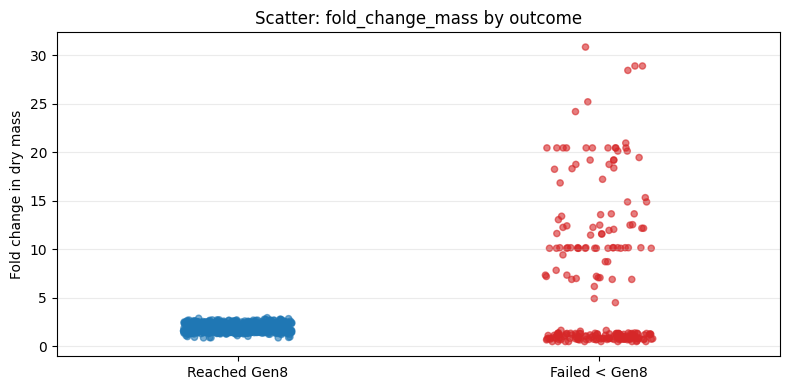

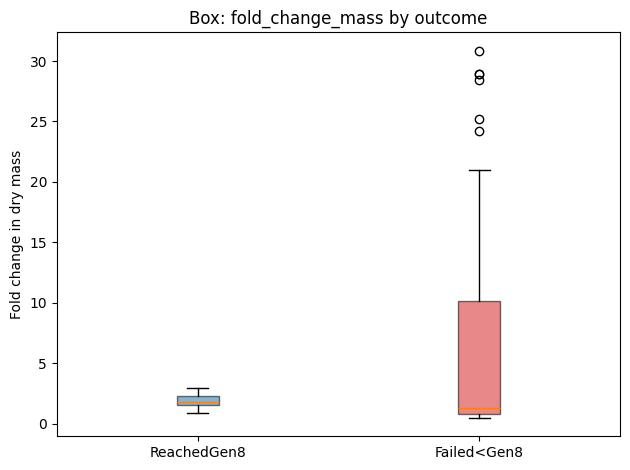

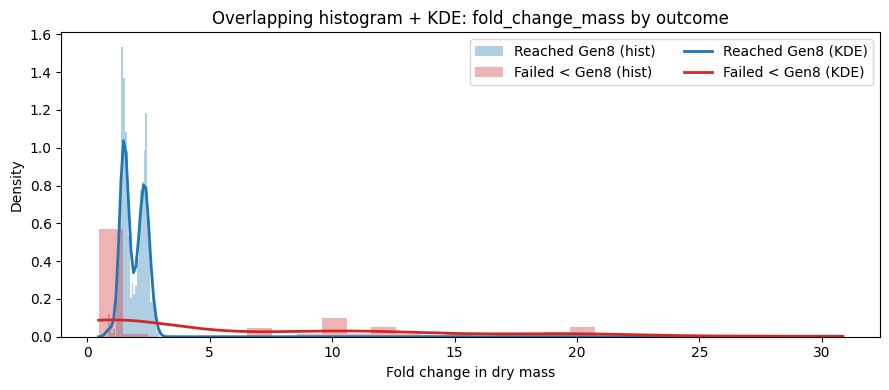

In [6]:
# Compare fold_change_mass between successful vs failed runs (same style as Cell 5)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
df = pd.read_csv(KO_DETAIL_PATH)

# Validate required outcome label
if 'failed_before_gen8' not in df.columns:
    raise KeyError(f"Column 'failed_before_gen8' not found. Available columns: {list(df.columns)}")

# Use fold_change_mass directly when present; otherwise derive from dry-mass columns if possible
if 'fold_change_mass' in df.columns:
    metric = pd.to_numeric(df['fold_change_mass'], errors='coerce')
else:
    if {'final_dry_mass', 'initial_dry_mass'}.issubset(df.columns):
        final_mass = pd.to_numeric(df['final_dry_mass'], errors='coerce')
        initial_mass = pd.to_numeric(df['initial_dry_mass'], errors='coerce')
        metric = final_mass / initial_mass.replace(0, np.nan)
        print("Info: 'fold_change_mass' not present; derived as final_dry_mass / initial_dry_mass.")
    else:
        raise KeyError(
            "No 'fold_change_mass' column, and cannot derive it because 'final_dry_mass'/'initial_dry_mass' are missing. "
            f"Available columns: {list(df.columns)}"
        )

plot_df = pd.DataFrame({
    'fold_change_mass': metric,
    'failed_before_gen8': pd.to_numeric(df['failed_before_gen8'], errors='coerce')
})
plot_df = plot_df.dropna(subset=['fold_change_mass', 'failed_before_gen8']).copy()
plot_df = plot_df[np.isfinite(plot_df['fold_change_mass'])].copy()
plot_df['failed_before_gen8'] = plot_df['failed_before_gen8'].astype(int)
plot_df['status'] = np.where(plot_df['failed_before_gen8'] == 1, 'Failed<Gen8', 'ReachedGen8')

if plot_df.empty:
    raise RuntimeError('No valid fold_change_mass rows available after filtering.')

group_stats = (
    plot_df.groupby('status')['fold_change_mass']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
print('Table: run-level fold_change_mass distribution summary for success vs failure groups.')
display(group_stats)

# Plot 1: scatter with centered groups + jitter
rng = np.random.default_rng(42)
centers = np.where(plot_df['failed_before_gen8'].values == 1, 0.2, -0.2)
x = centers + rng.uniform(-0.06, 0.06, size=len(plot_df))
plt.figure(figsize=(8, 4))
colors = np.where(plot_df['failed_before_gen8'].values == 1, '#d62728', '#1f77b4')
plt.scatter(x, plot_df['fold_change_mass'].values, c=colors, alpha=0.6, s=20)
plt.xticks([-0.2, 0.2], ['Reached Gen8', 'Failed < Gen8'])
plt.xlim(-0.4, 0.4)
plt.ylabel('Fold change in dry mass')
plt.title('Scatter: fold_change_mass by outcome')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: box plot
box_data = [
    plot_df.loc[plot_df['failed_before_gen8'] == 0, 'fold_change_mass'].values,
    plot_df.loc[plot_df['failed_before_gen8'] == 1, 'fold_change_mass'].values,
]
bp = plt.boxplot(box_data, tick_labels=['ReachedGen8', 'Failed<Gen8'], patch_artist=True)
bp['boxes'][0].set(facecolor='#1f77b4', alpha=0.55)
bp['boxes'][1].set(facecolor='#d62728', alpha=0.55)
plt.ylabel('Fold change in dry mass')
plt.title('Box: fold_change_mass by outcome')
plt.tight_layout()
plt.show()

# Plot 3: overlapping histogram + KDE
fc_success = plot_df.loc[plot_df['failed_before_gen8'] == 0, 'fold_change_mass'].values
fc_failed = plot_df.loc[plot_df['failed_before_gen8'] == 1, 'fold_change_mass'].values
all_fc = plot_df['fold_change_mass'].values
xmin, xmax = float(np.nanmin(all_fc)), float(np.nanmax(all_fc))
x_grid = np.linspace(xmin, xmax, 300)[:, None]

def _kde_curve(values, x_grid_2d):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.zeros(len(x_grid_2d), dtype=float)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    bw = 1.06 * std * (len(values) ** (-1 / 5)) if std > 0 else 0.05
    bw = max(float(bw), 1e-3)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(values.reshape(-1, 1))
    return np.exp(kde.score_samples(x_grid_2d))

plt.figure(figsize=(9, 4))
plt.hist(fc_success, bins=30, density=True, alpha=0.35, color='#1f77b4', label='Reached Gen8 (hist)')
plt.hist(fc_failed, bins=30, density=True, alpha=0.35, color='#d62728', label='Failed < Gen8 (hist)')
plt.plot(x_grid.ravel(), _kde_curve(fc_success, x_grid), color='#1f77b4', linewidth=2, label='Reached Gen8 (KDE)')
plt.plot(x_grid.ravel(), _kde_curve(fc_failed, x_grid), color='#d62728', linewidth=2, label='Failed < Gen8 (KDE)')
plt.xlabel('Fold change in dry mass')
plt.ylabel('Density')
plt.title('Overlapping histogram + KDE: fold_change_mass by outcome')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

Table: summary of generation-normalized mass-change metric by outcome.


,status,count,mean,std,median,min,max
0,Failed<Gen8,224,1.143338,1.713636,0.059468,-0.089346,7.731989
1,ReachedGen8,721,0.111344,0.055799,0.096988,-0.019912,0.241278


Table: reference summary for geometric per-generation fold change by outcome.


,status,count,mean,std,median,min,max
0,Failed<Gen8,224,1.294793,0.415979,1.053069,0.879848,2.892329
1,ReachedGen8,721,1.079487,0.032624,1.074428,0.978544,1.143833


Using symlog scale for plots (linthresh=0.05).


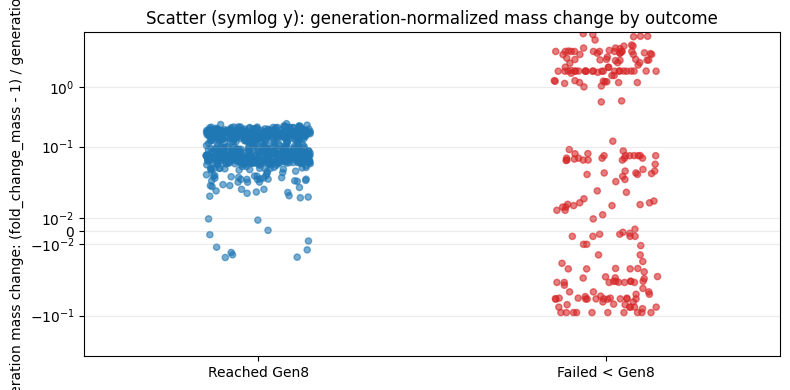

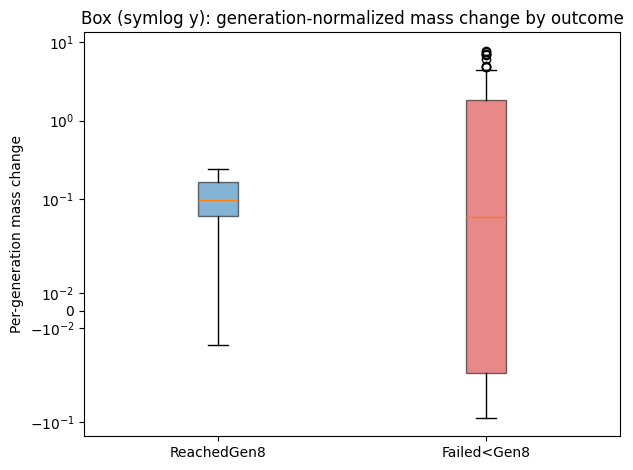

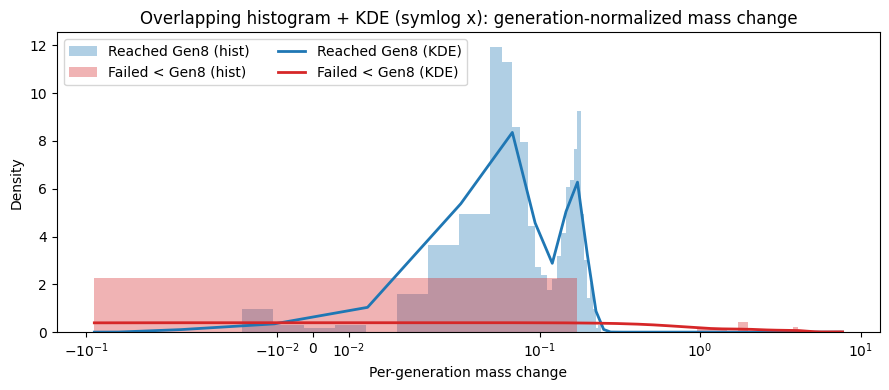

In [ ]:
# Compare generation-normalized mass change between successful vs failed runs
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
df = pd.read_csv(KO_DETAIL_PATH)

required_cols = ['failed_before_gen8', 'max_success_generation']
for c in required_cols:
    if c not in df.columns:
        raise KeyError(f"Column '{c}' not found. Available columns: {list(df.columns)}")

# Base total fold-change metric
if 'fold_change_mass' in df.columns:
    total_fc = pd.to_numeric(df['fold_change_mass'], errors='coerce')
elif {'final_dry_mass', 'initial_dry_mass'}.issubset(df.columns):
    final_mass = pd.to_numeric(df['final_dry_mass'], errors='coerce')
    initial_mass = pd.to_numeric(df['initial_dry_mass'], errors='coerce')
    total_fc = final_mass / initial_mass.replace(0, np.nan)
    print("Info: 'fold_change_mass' not present; derived as final_dry_mass / initial_dry_mass.")
else:
    raise KeyError(
        "No 'fold_change_mass' column, and cannot derive it because 'final_dry_mass'/'initial_dry_mass' are missing. "
        f"Available columns: {list(df.columns)}"
    )

# Generation count from run metadata
gen_count = pd.to_numeric(df['max_success_generation'], errors='coerce')
gen_count = gen_count.where(gen_count > 0, np.nan)

# User-requested normalization idea: divide total mass change by generation count
# total_mass_change = fold_change_mass - 1
per_gen_mass_change = (total_fc - 1.0) / gen_count

# Optional reference metric (geometric per-generation fold change)
per_gen_fc_geom = np.where(
    (total_fc > 0) & np.isfinite(total_fc) & np.isfinite(gen_count),
    np.power(total_fc, 1.0 / gen_count),
    np.nan,
 )

plot_df = pd.DataFrame({
    'per_gen_mass_change': per_gen_mass_change,
    'per_gen_fc_geom': per_gen_fc_geom,
    'fold_change_mass': total_fc,
    'generation_count': gen_count,
    'failed_before_gen8': pd.to_numeric(df['failed_before_gen8'], errors='coerce'),
})
plot_df = plot_df.dropna(subset=['per_gen_mass_change', 'failed_before_gen8']).copy()
plot_df = plot_df[np.isfinite(plot_df['per_gen_mass_change'])].copy()
plot_df['failed_before_gen8'] = plot_df['failed_before_gen8'].astype(int)
plot_df['status'] = np.where(plot_df['failed_before_gen8'] == 1, 'Failed<Gen8', 'ReachedGen8')

if plot_df.empty:
    raise RuntimeError('No valid rows available after filtering for per-generation mass change analysis.')

print('Table: summary of generation-normalized mass-change metric by outcome.')
group_stats = (
    plot_df.groupby('status')['per_gen_mass_change']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
display(group_stats)

print('Table: reference summary for geometric per-generation fold change by outcome.')
group_stats_geom = (
    plot_df.groupby('status')['per_gen_fc_geom']
    .agg(['count', 'mean', 'std', 'median', 'min', 'max'])
    .reset_index()
)
display(group_stats_geom)

# Signed log scaling compresses long tails while preserving negative values around zero
SYMLINTHRESH = 0.05
print(f'Using symlog scale for plots (linthresh={SYMLINTHRESH}).')

# Plot 1: scatter with centered groups + jitter
rng = np.random.default_rng(42)
centers = np.where(plot_df['failed_before_gen8'].values == 1, 0.2, -0.2)
x = centers + rng.uniform(-0.06, 0.06, size=len(plot_df))
plt.figure(figsize=(8, 4))
colors = np.where(plot_df['failed_before_gen8'].values == 1, '#d62728', '#1f77b4')
plt.scatter(x, plot_df['per_gen_mass_change'].values, c=colors, alpha=0.6, s=20)
plt.xticks([-0.2, 0.2], ['Reached Gen8', 'Failed < Gen8'])
plt.xlim(-0.4, 0.4)
plt.yscale('symlog', linthresh=SYMLINTHRESH)
plt.ylabel('Per-generation mass change: (fold_change_mass - 1) / generation_count')
plt.title('Scatter (symlog y): generation-normalized mass change by outcome')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Plot 2: box plot
box_data = [
    plot_df.loc[plot_df['failed_before_gen8'] == 0, 'per_gen_mass_change'].values,
    plot_df.loc[plot_df['failed_before_gen8'] == 1, 'per_gen_mass_change'].values,
]
bp = plt.boxplot(box_data, tick_labels=['ReachedGen8', 'Failed<Gen8'], patch_artist=True)
bp['boxes'][0].set(facecolor='#1f77b4', alpha=0.55)
bp['boxes'][1].set(facecolor='#d62728', alpha=0.55)
plt.yscale('symlog', linthresh=SYMLINTHRESH)
plt.ylabel('Per-generation mass change')
plt.title('Box (symlog y): generation-normalized mass change by outcome')
plt.tight_layout()
plt.show()

# Plot 3: overlapping histogram + KDE
m_success = plot_df.loc[plot_df['failed_before_gen8'] == 0, 'per_gen_mass_change'].values
m_failed = plot_df.loc[plot_df['failed_before_gen8'] == 1, 'per_gen_mass_change'].values
all_m = plot_df['per_gen_mass_change'].values
xmin, xmax = float(np.nanmin(all_m)), float(np.nanmax(all_m))
x_grid = np.linspace(xmin, xmax, 300)[:, None]

def _kde_curve(values, x_grid_2d):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) < 2:
        return np.zeros(len(x_grid_2d), dtype=float)
    std = np.std(values, ddof=1) if len(values) > 1 else 0.0
    bw = 1.06 * std * (len(values) ** (-1 / 5)) if std > 0 else 0.05
    bw = max(float(bw), 1e-3)
    kde = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde.fit(values.reshape(-1, 1))
    return np.exp(kde.score_samples(x_grid_2d))

plt.figure(figsize=(9, 4))
plt.hist(m_success, bins=30, density=True, alpha=0.35, color='#1f77b4', label='Reached Gen8 (hist)')
plt.hist(m_failed, bins=30, density=True, alpha=0.35, color='#d62728', label='Failed < Gen8 (hist)')
plt.plot(x_grid.ravel(), _kde_curve(m_success, x_grid), color='#1f77b4', linewidth=2, label='Reached Gen8 (KDE)')
plt.plot(x_grid.ravel(), _kde_curve(m_failed, x_grid), color='#d62728', linewidth=2, label='Failed < Gen8 (KDE)')
plt.xscale('symlog', linthresh=SYMLINTHRESH)
plt.xlabel('Per-generation mass change')
plt.ylabel('Density')
plt.title('Overlapping histogram + KDE (symlog x): generation-normalized mass change')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

## Analyse with time-series data instead of data summaries

- Full data:

/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet

### pq data format inspection

In [1]:
# Inspect pq time-series structure before preprocessing
from pathlib import Path
import pandas as pd

TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

print('PQ files to inspect:')
for p in TIMESERIES_PATHS:
    print('-', p)

schema_rows = []

for p in TIMESERIES_PATHS:
    if not p.exists():
        print(f'Warning: missing file: {p}')
        continue

    df = pd.read_parquet(p)
    n_rows, n_cols = df.shape
    cols = list(df.columns)

    print('\n' + '=' * 90)
    print(f'File: {p.name}')
    print(f'Shape: {n_rows} rows x {n_cols} columns')
    print('Columns:')
    print(cols)
    print('Dtypes:')
    print(df.dtypes.astype(str))

    key_cols = [
        c for c in [
            'project', 'experiment_id', 'variant', 'lineage_seed', 'seed', 'generation',
            'time', 'label', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass'
        ] if c in df.columns
    ]
    if key_cols:
        print('Sample rows (key columns):')
        display(df[key_cols].head(5))
    else:
        print('Sample rows (first 5):')
        display(df.head(5))

    # Show ALL time points for one simulation in this file
    run_id_cols = [c for c in ['project', 'variant', 'label'] if c in df.columns]
    if ('time' in df.columns) and run_id_cols:
        run_key = df[run_id_cols].drop_duplicates().iloc[0]
        run_mask = pd.Series(True, index=df.index)
        for c in run_id_cols:
            run_mask &= df[c].astype(str) == str(run_key[c])
        run_times = pd.to_numeric(df.loc[run_mask, 'time'], errors='coerce').dropna().drop_duplicates().sort_values().reset_index(drop=True)

        print('One simulation used for full time-point display:')
        print({c: str(run_key[c]) for c in run_id_cols})
        print(f'Total unique time points for this simulation: {len(run_times)}')
        display(pd.DataFrame({'time': run_times}))

    row = {'file': p.name, 'n_rows': n_rows, 'n_cols': n_cols}
    for c in cols:
        row[f'has::{c}'] = 1
    schema_rows.append(row)

if not schema_rows:
    raise RuntimeError('No parquet files were loaded. Check TIMESERIES_PATHS.')

schema_df = pd.DataFrame(schema_rows).fillna(0)
has_cols = sorted([c for c in schema_df.columns if c.startswith('has::')])

print('\n' + '=' * 90)
print('Schema presence matrix (1=present, 0=absent):')
display(schema_df[['file', 'n_rows', 'n_cols'] + has_cols])

print('Column coverage summary across files:')
coverage = pd.DataFrame({
    'column': [c.replace('has::', '') for c in has_cols],
    'files_with_column': [int(schema_df[c].sum()) for c in has_cols],
    'total_files': [len(schema_df)] * len(has_cols),
})
coverage['all_files'] = coverage['files_with_column'] == coverage['total_files']
display(coverage.sort_values(['all_files', 'column'], ascending=[True, True]).reset_index(drop=True))

# Load merged frame for quick global checks
parts = []
for p in TIMESERIES_PATHS:
    if p.exists():
        x = pd.read_parquet(p).copy()
        x['source_file'] = p.name
        parts.append(x)
ts = pd.concat(parts, ignore_index=True)

print('\nMerged pq shape:', ts.shape)
print('Merged columns:', list(ts.columns))

for c in ['project', 'experiment_id', 'variant', 'lineage_seed', 'seed', 'generation', 'time', 'label']:
    if c in ts.columns:
        print(f'Unique non-null {c}:', int(ts[c].dropna().nunique()))

if 'time' in ts.columns:
    t = pd.to_numeric(ts['time'], errors='coerce')
    print('Time min/max:', float(t.min()), float(t.max()))

print('\nDone: use this structure info to finalize preprocessing assumptions.')

PQ files to inspect:
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
- /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet

File: growth_rate_timeseries_441_KOs_seed100_all.parquet
Shape: 29944 rows x 6 columns
Columns:
['project', 'variant', 'label', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
Dtypes:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dty

,project,variant,time,label,listeners__mass__instantaneous_growth_rate,listeners__mass__dry_mass
0,gene_ko_441imported_2seeds,1,0.0,KO: EG10109,0.000000,266.982849
1,gene_ko_441imported_2seeds,1,400.0,KO: EG10109,0.000182,289.433248
2,gene_ko_441imported_2seeds,1,800.0,KO: EG10109,0.000253,317.276584
3,gene_ko_441imported_2seeds,1,1200.0,KO: EG10109,0.000313,354.977569
4,gene_ko_441imported_2seeds,1,1600.0,KO: EG10109,0.000300,400.173977


One simulation used for full time-point display:
{'project': 'gene_ko_441imported_2seeds', 'variant': '1', 'label': 'KO: EG10109'}
Total unique time points for this simulation: 69


,time
0,0.0
1,400.0
2,800.0
3,1200.0
4,1600.0
...,...
64,24288.0
65,24688.0
66,25088.0
67,25488.0



File: growth_rate_timeseries_441_KOs_seed101_all.parquet
Shape: 27357 rows x 6 columns
Columns:
['project', 'variant', 'label', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass']
Dtypes:
project                                        object
variant                                         int64
label                                          object
time                                          float64
listeners__mass__instantaneous_growth_rate    float64
listeners__mass__dry_mass                     float64
dtype: object
Sample rows (key columns):


...


Schema presence matrix (1=present, 0=absent):


,file,n_rows,n_cols,has::label,has::listeners__mass__dry_mass,has::listeners__mass__instantaneous_growth_rate,has::project,has::time,has::variant
0,growth_rate_timeseries_441_KOs_seed100_all.par...,29944,6,1,1,1,1,1,1
1,growth_rate_timeseries_441_KOs_seed101_all.par...,27357,6,1,1,1,1,1,1
2,growth_rate_timeseries_seed100_all.parquet,56096,6,1,1,1,1,1,1
3,growth_rate_timeseries_seed101_all.parquet,46577,6,1,1,1,1,1,1


Column coverage summary across files:


,column,files_with_column,total_files,all_files
0,label,4,4,True
1,listeners__mass__dry_mass,4,4,True
2,listeners__mass__instantaneous_growth_rate,4,4,True
3,project,4,4,True
4,time,4,4,True
5,variant,4,4,True



Merged pq shape: (159974, 7)
Merged columns: ['project', 'variant', 'label', 'time', 'listeners__mass__instantaneous_growth_rate', 'listeners__mass__dry_mass', 'source_file']
Unique non-null project: 5
Unique non-null variant: 442
Unique non-null time: 25029
Unique non-null label: 486
Time min/max: 0.0 48214.0

Done: use this structure info to finalize preprocessing assumptions.


### plot individual simulation growth rates

Number of simulations that stop at generation 7: 21
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 10 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


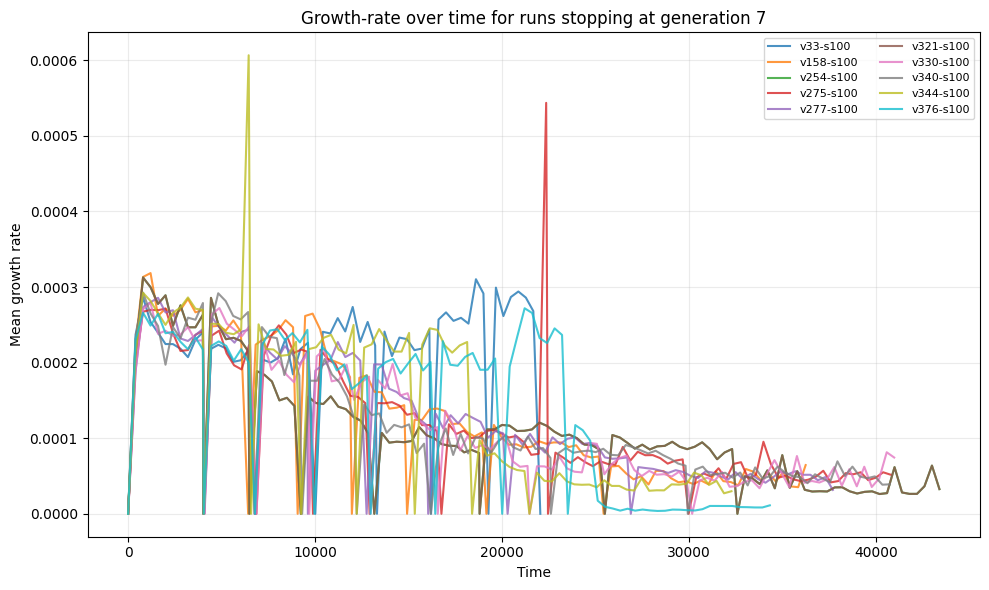

In [4]:
# Inspect runs that stop at generation 7 and plot growth-rate trajectories
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load stop-7 run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

stop7_runs = run_keys[run_keys['max_success_generation'] == 7].copy()
n_stop7 = len(stop7_runs)
print(f'Number of simulations that stop at generation 7: {n_stop7}')

if n_stop7 == 0:
    print('No generation-7 stop simulations found.')
else:
    # Load all extracted timeseries data
    ts_parts = []
    for p in TIMESERIES_PATHS:
        part = pd.read_parquet(p)
        part['source_file'] = p.name
        ts_parts.append(part)
    ts = pd.concat(ts_parts, ignore_index=True)

    # Resolve essential columns dynamically (robust to schema changes)
    col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
    col_variant = pick_col(ts, ['variant'])
    col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
    col_generation = pick_col(ts, ['generation'], required=False)
    col_growth = pick_col(ts, [
        'mean_growth_rate',
        'listeners__mass__instantaneous_growth_rate',
        'instantaneous_growth_rate',
        'growth_rate',
    ])
    col_time = pick_col(ts, ['time'], required=False)

    # Fallback: extract lineage seed from project text when no explicit seed column exists
    if col_seed is None:
        project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
        source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
        ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
        default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
        ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
        if ts['_lineage_seed_from_project'].isna().all():
            raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
        col_seed = '_lineage_seed_from_project'

    # Fallback: infer generation from time resets when parquet has no generation column
    if col_generation is None:
        if col_time is None:
            raise KeyError('No generation column found, and no time column available to infer generation.')
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
        run_group_cols = [col_variant, col_seed]
        if col_project is not None:
            run_group_cols.append(col_project)
        ts['_generation_from_time'] = (
            ts.groupby(run_group_cols, dropna=False)[col_time]
            .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
        )
        col_generation = '_generation_from_time'
        print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

    ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
    ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
    ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
    ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')

    if col_time is not None:
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

    # Keep only rows with usable keys and growth values
    required_cols = [col_variant, col_seed, col_generation, col_growth]
    if col_time is not None:
        required_cols.append(col_time)
    ts = ts.dropna(subset=required_cols).copy()

    to_plot = stop7_runs.head(10).copy()
    print(f'Plotting first {len(to_plot)} run(s).')

    plt.figure(figsize=(10, 6))
    plotted = 0
    used_time_axis = False

    for _, row in to_plot.reset_index(drop=True).iterrows():
        project = str(row['project'])
        variant = int(row['variant'])
        seed = int(row['lineage_seed'])

        mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
        if col_project is not None:
            mask &= (ts[col_project].astype(str) == project)

        run_cols = [col_generation, col_growth]
        if col_time is not None:
            run_cols.append(col_time)
        run_ts = ts.loc[mask, run_cols].copy()
        if run_ts.empty:
            continue

        gen_curve = (
            run_ts.groupby(col_generation, as_index=False)[col_growth]
            .mean()
            .sort_values(col_generation)
        )

        # Plot only generations up to 7 for this analysis
        gen_curve = gen_curve[gen_curve[col_generation] <= 7]
        if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
            plotted += 1
            plt.plot(
                gen_curve[col_generation].values,
                gen_curve[col_growth].values,
                marker='o',
                linewidth=1.5,
                alpha=0.8,
                label=f'v{variant}-s{seed}'
            )
            continue

        # If generation collapses to one value, fallback to time-based trajectory
        if col_time is not None:
            time_curve = (
                run_ts.groupby(col_time, as_index=False)[col_growth]
                .mean()
                .sort_values(col_time)
            )
            if not time_curve.empty and time_curve[col_time].nunique() > 1:
                used_time_axis = True
                plotted += 1
                plt.plot(
                    time_curve[col_time].values,
                    time_curve[col_growth].values,
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s{seed}'
                )

    if used_time_axis:
        plt.xlabel('Time')
        plt.title('Growth-rate over time for runs stopping at generation 7')
        print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
    else:
        plt.xlabel('Generation')
        plt.title('Growth-rate over generation for runs stopping at generation 7')
        plt.xticks(range(1, 8))
    plt.ylabel('Mean growth rate')
    plt.grid(alpha=0.25)
    if plotted > 0:
        plt.legend(fontsize=8, ncol=2)
    else:
        print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
    plt.tight_layout()
    plt.show()

Number of simulations that reach generation 8: 702
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 10 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


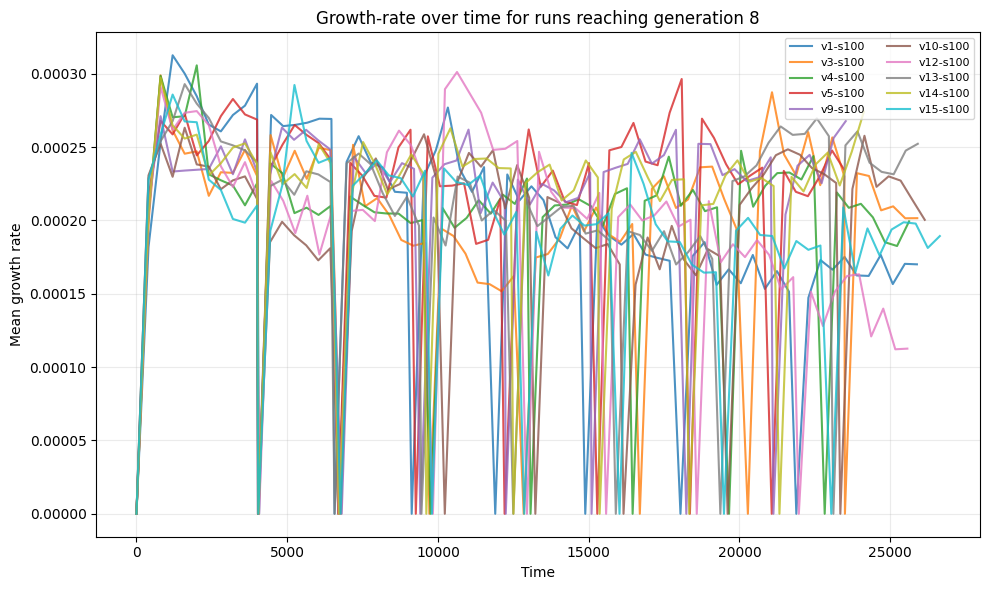

In [2]:
# Inspect runs that successfully reach generation 8 and plot growth-rate trajectories
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

reach8_runs = run_keys[run_keys['max_success_generation'] >= 8].copy()
n_reach8 = len(reach8_runs)
print(f'Number of simulations that reach generation 8: {n_reach8}')

if n_reach8 == 0:
    print('No generation-8-success simulations found.')
else:
    # Load all extracted timeseries data
    ts_parts = []
    for p in TIMESERIES_PATHS:
        part = pd.read_parquet(p)
        part['source_file'] = p.name
        ts_parts.append(part)
    ts = pd.concat(ts_parts, ignore_index=True)

    # Resolve essential columns dynamically (robust to schema changes)
    col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
    col_variant = pick_col(ts, ['variant'])
    col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
    col_generation = pick_col(ts, ['generation'], required=False)
    col_growth = pick_col(ts, [
        'mean_growth_rate',
        'listeners__mass__instantaneous_growth_rate',
        'instantaneous_growth_rate',
        'growth_rate',
    ])
    col_time = pick_col(ts, ['time'], required=False)

    # Fallback: extract lineage seed from project/source text when no explicit seed column exists
    if col_seed is None:
        project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
        source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
        ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
        default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
        ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
        if ts['_lineage_seed_from_project'].isna().all():
            raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
        col_seed = '_lineage_seed_from_project'

    # Fallback: infer generation from time resets when parquet has no generation column
    if col_generation is None:
        if col_time is None:
            raise KeyError('No generation column found, and no time column available to infer generation.')
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
        run_group_cols = [col_variant, col_seed]
        if col_project is not None:
            run_group_cols.append(col_project)
        ts['_generation_from_time'] = (
            ts.groupby(run_group_cols, dropna=False)[col_time]
            .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
        )
        col_generation = '_generation_from_time'
        print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

    ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
    ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
    ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
    ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')
    if col_time is not None:
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

    # Keep only rows with usable keys and growth values
    required_cols = [col_variant, col_seed, col_generation, col_growth]
    if col_time is not None:
        required_cols.append(col_time)
    ts = ts.dropna(subset=required_cols).copy()

    to_plot = reach8_runs.head(10).copy()
    print(f'Plotting first {len(to_plot)} run(s).')

    plt.figure(figsize=(10, 6))
    plotted = 0
    used_time_axis = False

    for _, row in to_plot.reset_index(drop=True).iterrows():
        project = str(row['project'])
        variant = int(row['variant'])
        seed = int(row['lineage_seed'])

        mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
        if col_project is not None:
            mask &= (ts[col_project].astype(str) == project)

        run_cols = [col_generation, col_growth]
        if col_time is not None:
            run_cols.append(col_time)
        run_ts = ts.loc[mask, run_cols].copy()
        if run_ts.empty:
            continue

        gen_curve = (
            run_ts.groupby(col_generation, as_index=False)[col_growth]
            .mean()
            .sort_values(col_generation)
        )

        # Plot only generations up to 8 for this analysis
        gen_curve = gen_curve[gen_curve[col_generation] <= 8]
        if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
            plotted += 1
            plt.plot(
                gen_curve[col_generation].values,
                gen_curve[col_growth].values,
                marker='o',
                linewidth=1.5,
                alpha=0.8,
                label=f'v{variant}-s{seed}'
            )
            continue

        # If generation collapses to one value, fallback to time-based trajectory
        if col_time is not None:
            time_curve = (
                run_ts.groupby(col_time, as_index=False)[col_growth]
                .mean()
                .sort_values(col_time)
            )
            if not time_curve.empty and time_curve[col_time].nunique() > 1:
                used_time_axis = True
                plotted += 1
                plt.plot(
                    time_curve[col_time].values,
                    time_curve[col_growth].values,
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s{seed}'
                )

    if used_time_axis:
        plt.xlabel('Time')
        plt.title('Growth-rate over time for runs reaching generation 8')
        print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
    else:
        plt.xlabel('Generation')
        plt.title('Growth-rate over generation for runs reaching generation 8')
        plt.xticks(range(1, 9))
    plt.ylabel('Mean growth rate')
    plt.grid(alpha=0.25)
    if plotted > 0:
        plt.legend(fontsize=8, ncol=2)
    else:
        print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
    plt.tight_layout()
    plt.show()

Number of simulations that fail within first 1-3 generations: 7
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 7 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


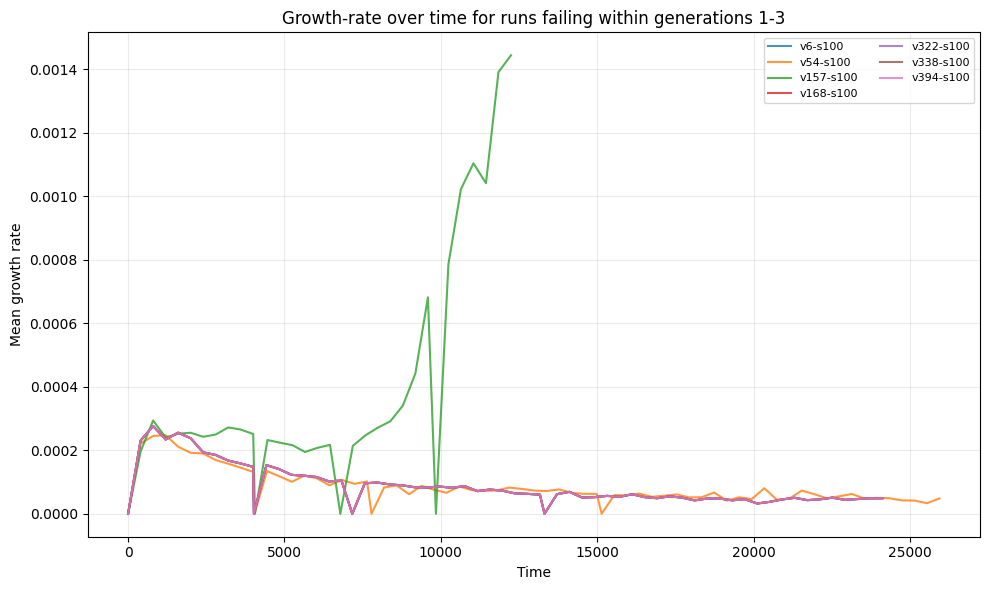

In [3]:
# Inspect runs that fail in the first 1-2 generations and plot growth-rate trajectories
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

early_fail_runs = run_keys[run_keys['max_success_generation'].between(1, 3)].copy()
n_early_fail = len(early_fail_runs)
print(f'Number of simulations that fail within first 1-3 generations: {n_early_fail}')

if n_early_fail == 0:
    print('No early-failure (gen 1-3) simulations found.')
else:
    # Load all extracted timeseries data
    ts_parts = []
    for p in TIMESERIES_PATHS:
        part = pd.read_parquet(p)
        part['source_file'] = p.name
        ts_parts.append(part)
    ts = pd.concat(ts_parts, ignore_index=True)

    # Resolve essential columns dynamically (robust to schema changes)
    col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
    col_variant = pick_col(ts, ['variant'])
    col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
    col_generation = pick_col(ts, ['generation'], required=False)
    col_growth = pick_col(ts, [
        'mean_growth_rate',
        'listeners__mass__instantaneous_growth_rate',
        'instantaneous_growth_rate',
        'growth_rate',
    ])
    col_time = pick_col(ts, ['time'], required=False)

    # Fallback: extract lineage seed from project text when no explicit seed column exists
    if col_seed is None:
        project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
        source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
        ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
        ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
        default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
        ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
        if ts['_lineage_seed_from_project'].isna().all():
            raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
        col_seed = '_lineage_seed_from_project'

    # Fallback: infer generation from time resets when parquet has no generation column
    if col_generation is None:
        if col_time is None:
            raise KeyError('No generation column found, and no time column available to infer generation.')
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
        run_group_cols = [col_variant, col_seed]
        if col_project is not None:
            run_group_cols.append(col_project)
        ts['_generation_from_time'] = (
            ts.groupby(run_group_cols, dropna=False)[col_time]
            .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
        )
        col_generation = '_generation_from_time'
        print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

    ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
    ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
    ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
    ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')

    if col_time is not None:
        ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

    # Keep only rows with usable keys and growth values
    required_cols = [col_variant, col_seed, col_generation, col_growth]
    if col_time is not None:
        required_cols.append(col_time)
    ts = ts.dropna(subset=required_cols).copy()

    to_plot = early_fail_runs.head(10).copy()
    print(f'Plotting first {len(to_plot)} run(s).')

    plt.figure(figsize=(10, 6))
    plotted = 0
    used_time_axis = False

    for _, row in to_plot.reset_index(drop=True).iterrows():
        project = str(row['project'])
        variant = int(row['variant'])
        seed = int(row['lineage_seed'])

        mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
        if col_project is not None:
            mask &= (ts[col_project].astype(str) == project)

        run_cols = [col_generation, col_growth]
        if col_time is not None:
            run_cols.append(col_time)
        run_ts = ts.loc[mask, run_cols].copy()
        if run_ts.empty:
            continue

        gen_curve = (
            run_ts.groupby(col_generation, as_index=False)[col_growth]
            .mean()
            .sort_values(col_generation)
        )

        # Plot only generations up to 2 for this early-failure analysis
        gen_curve = gen_curve[gen_curve[col_generation] <= 2]
        if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
            plotted += 1
            plt.plot(
                gen_curve[col_generation].values,
                gen_curve[col_growth].values,
                marker='o',
                linewidth=1.5,
                alpha=0.8,
                label=f'v{variant}-s{seed}'
            )
            continue

        # If generation collapses to one value, fallback to time-based trajectory
        if col_time is not None:
            time_curve = (
                run_ts.groupby(col_time, as_index=False)[col_growth]
                .mean()
                .sort_values(col_time)
            )
            if not time_curve.empty and time_curve[col_time].nunique() > 1:
                used_time_axis = True
                plotted += 1
                plt.plot(
                    time_curve[col_time].values,
                    time_curve[col_growth].values,
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s{seed}'
                )

    if used_time_axis:
        plt.xlabel('Time')
        plt.title('Growth-rate over time for runs failing within generations 1-3')
        print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
    else:
        plt.xlabel('Generation')
        plt.title('Growth-rate over generation for runs failing within generations 1-3')
        plt.xticks([1, 2, 3])
    plt.ylabel('Mean growth rate')
    plt.grid(alpha=0.25)
    if plotted > 0:
        plt.legend(fontsize=8, ncol=2)
    else:
        print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
    plt.tight_layout()
    plt.show()

Seed 100 runs failing at generations 1-3: 7
Matched seed 101 runs for those KO variants: 7
Info: generation column missing in parquet; inferred generation from time resets within each run.
Plotting first 7 matched seed-101 run(s).
Info: showing time-based trajectories because generation values collapsed to single points in parquet data.


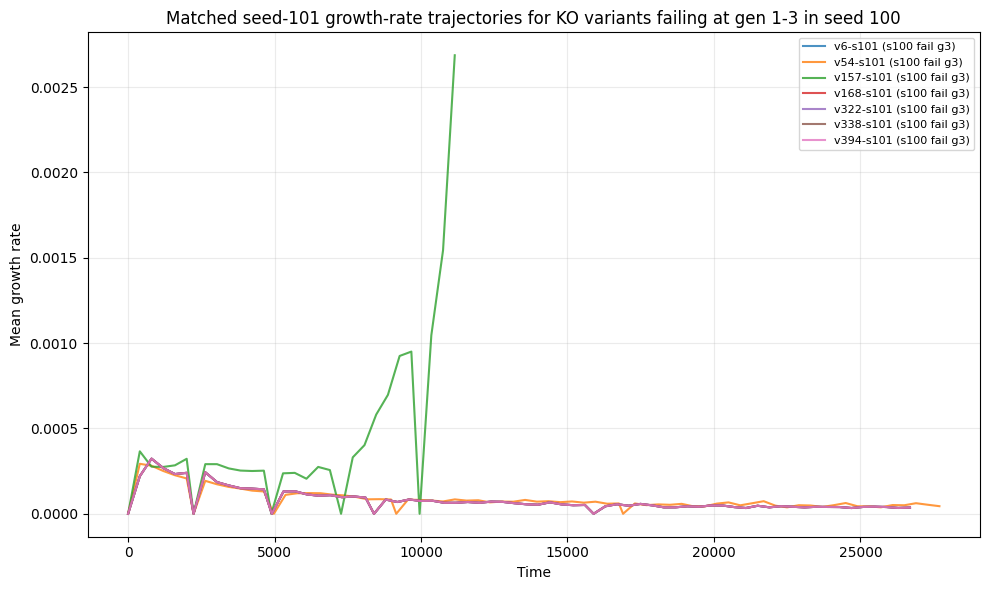

In [5]:
# Plot the same KO simulations in seed 101 for variants that fail at generations 1-3 in seed 100
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

KO_DETAIL_PATH = Path('/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of candidate columns found: {candidates}. Available columns: {list(df.columns)}')
    return None

# Load run keys from saved KO detail table
run_df = pd.read_csv(KO_DETAIL_PATH)
run_keys = run_df[['project', 'variant', 'lineage_seed', 'max_success_generation']].drop_duplicates().copy()
run_keys['variant'] = pd.to_numeric(run_keys['variant'], errors='coerce').astype('Int64')
run_keys['lineage_seed'] = pd.to_numeric(run_keys['lineage_seed'], errors='coerce').astype('Int64')
run_keys['max_success_generation'] = pd.to_numeric(run_keys['max_success_generation'], errors='coerce').astype('Int64')
run_keys = run_keys.dropna(subset=['project', 'variant', 'lineage_seed', 'max_success_generation'])
run_keys = run_keys[run_keys['lineage_seed'].isin([100, 101])].copy() # exclude any non-seed or unexpected seeds for KO rows

# Source set: failures at generations 1-3 on seed 100
seed100_fail_1to3 = run_keys[
    (run_keys['lineage_seed'] == 100)
    & (run_keys['max_success_generation'].between(1, 3))
].copy()

print(f'Seed 100 runs failing at generations 1-3: {len(seed100_fail_1to3)}')
if seed100_fail_1to3.empty:
    print('No seed-100 failures in generations 1-3 found.')
else:
    # Match same project+variant on seed 101
    target_pairs = seed100_fail_1to3[['project', 'variant', 'max_success_generation']].copy()
    target_pairs = target_pairs.rename(columns={'max_success_generation': 'seed100_fail_generation'})

    seed101_runs = run_keys[run_keys['lineage_seed'] == 101].copy()
    matched_seed101 = seed101_runs.merge(
        target_pairs[['project', 'variant', 'seed100_fail_generation']],
        on=['project', 'variant'],
        how='inner',
    )

    print(f'Matched seed 101 runs for those KO variants: {len(matched_seed101)}')

    if matched_seed101.empty:
        print('No matching seed-101 runs found for the selected seed-100 early-failure variants.')
    else:
        # Load all extracted timeseries data
        ts_parts = []
        for p in TIMESERIES_PATHS:
            part = pd.read_parquet(p)
            part['source_file'] = p.name
            ts_parts.append(part)
        ts = pd.concat(ts_parts, ignore_index=True)

        # Resolve essential columns dynamically (robust to schema changes)
        col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
        col_variant = pick_col(ts, ['variant'])
        col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
        col_generation = pick_col(ts, ['generation'], required=False)
        col_growth = pick_col(ts, [
            'mean_growth_rate',
            'listeners__mass__instantaneous_growth_rate',
            'instantaneous_growth_rate',
            'growth_rate',
        ])
        col_time = pick_col(ts, ['time'], required=False)

        # Fallback: extract lineage seed from project/source text when no explicit seed column exists
        if col_seed is None:
            project_text = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
            source_text = ts['source_file'].astype(str) if 'source_file' in ts.columns else pd.Series('', index=ts.index)
            ts['_lineage_seed_from_project'] = project_text.str.extract(r'seed(?:=|_)?(\d+)')[0]
            ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(project_text.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
            ts['_lineage_seed_from_project'] = ts['_lineage_seed_from_project'].fillna(source_text.str.extract(r'seed(?:=|_)?(\d+)')[0])
            default_mask = project_text.str.contains('default', case=False, na=False) | source_text.str.contains('default', case=False, na=False)
            ts.loc[ts['_lineage_seed_from_project'].isna() & default_mask, '_lineage_seed_from_project'] = '0'
            if ts['_lineage_seed_from_project'].isna().all():
                raise KeyError('No seed column found and could not infer seed from project/experiment_id or source_file names.')
            col_seed = '_lineage_seed_from_project'

        # Fallback: infer generation from time resets when parquet has no generation column
        if col_generation is None:
            if col_time is None:
                raise KeyError('No generation column found, and no time column available to infer generation.')
            ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
            run_group_cols = [col_variant, col_seed]
            if col_project is not None:
                run_group_cols.append(col_project)
            ts['_generation_from_time'] = (
                ts.groupby(run_group_cols, dropna=False)[col_time]
                .transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
            )
            col_generation = '_generation_from_time'
            print('Info: generation column missing in parquet; inferred generation from time resets within each run.')

        ts[col_variant] = pd.to_numeric(ts[col_variant], errors='coerce')
        ts[col_seed] = pd.to_numeric(ts[col_seed], errors='coerce')
        ts[col_generation] = pd.to_numeric(ts[col_generation], errors='coerce')
        ts[col_growth] = pd.to_numeric(ts[col_growth], errors='coerce')

        if col_time is not None:
            ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')

        # Keep only rows with usable keys and growth values
        required_cols = [col_variant, col_seed, col_generation, col_growth]
        if col_time is not None:
            required_cols.append(col_time)
        ts = ts.dropna(subset=required_cols).copy()

        to_plot = matched_seed101.head(10).copy()
        print(f'Plotting first {len(to_plot)} matched seed-101 run(s).')

        plt.figure(figsize=(10, 6))
        plotted = 0
        used_time_axis = False

        for _, row in to_plot.reset_index(drop=True).iterrows():
            project = str(row['project'])
            variant = int(row['variant'])
            seed = int(row['lineage_seed'])
            seed100_fail_gen = int(row['seed100_fail_generation'])

            mask = (ts[col_variant].astype(int) == variant) & (ts[col_seed].astype(int) == seed)
            if col_project is not None:
                mask &= (ts[col_project].astype(str) == project)

            run_cols = [col_generation, col_growth]
            if col_time is not None:
                run_cols.append(col_time)
            run_ts = ts.loc[mask, run_cols].copy()
            if run_ts.empty:
                continue

            gen_curve = (
                run_ts.groupby(col_generation, as_index=False)[col_growth]
                .mean()
                .sort_values(col_generation)
            )

            # For matched seed-101 runs, show trajectory up to generation 8 for direct comparison
            gen_curve = gen_curve[gen_curve[col_generation] <= 8]
            if (not gen_curve.empty) and (gen_curve[col_generation].nunique() > 1):
                plotted += 1
                plt.plot(
                    gen_curve[col_generation].values,
                    gen_curve[col_growth].values,
                    marker='o',
                    linewidth=1.5,
                    alpha=0.8,
                    label=f'v{variant}-s101 (s100 fail g{seed100_fail_gen})'
                )
                continue

            # If generation collapses to one value, fallback to time-based trajectory
            if col_time is not None:
                time_curve = (
                    run_ts.groupby(col_time, as_index=False)[col_growth]
                    .mean()
                    .sort_values(col_time)
                )
                if not time_curve.empty and time_curve[col_time].nunique() > 1:
                    used_time_axis = True
                    plotted += 1
                    plt.plot(
                        time_curve[col_time].values,
                        time_curve[col_growth].values,
                        linewidth=1.5,
                        alpha=0.8,
                        label=f'v{variant}-s101 (s100 fail g{seed100_fail_gen})'
                    )

        if used_time_axis:
            plt.xlabel('Time')
            plt.title('Matched seed-101 growth-rate trajectories for KO variants failing at gen 1-3 in seed 100')
            print('Info: showing time-based trajectories because generation values collapsed to single points in parquet data.')
        else:
            plt.xlabel('Generation')
            plt.title('Matched seed-101 growth-rate trajectories for KO variants failing at gen 1-3 in seed 100')
            plt.xticks(range(1, 9))
        plt.ylabel('Mean growth rate')
        plt.grid(alpha=0.25)
        if plotted > 0:
            plt.legend(fontsize=8, ncol=1)
        else:
            print('No trajectories plotted from extracted timeseries parquet files. Check key-column matching.')
        plt.tight_layout()
        plt.show()

Fact check: the seed 101 with same knockout also failed to proceed to 8th generation, but the failure happens at 4th generation instead.


### Time-series plot for outliers

#### Load data

In [1]:
# Outlier growth plot (trimmed): parquet extraction + raw points + median/IQR
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTLIER_CSV = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/knockout_function_check.csv')
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'Missing columns: {candidates}')
    return None

# Outlier run keys from CSV
outlier_df = pd.read_csv(OUTLIER_CSV)
outlier_df['variant'] = pd.to_numeric(outlier_df.get('variant'), errors='coerce')
outlier_df['lineage_seed'] = pd.to_numeric(outlier_df.get('lineage_seed'), errors='coerce')
outlier_df = outlier_df.dropna(subset=['variant', 'lineage_seed']).copy()
outlier_df['variant'] = outlier_df['variant'].astype(int)
outlier_df['lineage_seed'] = outlier_df['lineage_seed'].astype(int)
outlier_df['_run_key'] = outlier_df['variant'].astype(str) + '_' + outlier_df['lineage_seed'].astype(str)
if 'run' in outlier_df.columns:
    run_txt = outlier_df['run'].astype(str).str.strip()
    outlier_df.loc[run_txt.ne('') & run_txt.ne('nan'), '_run_key'] = run_txt[run_txt.ne('') & run_txt.ne('nan')]
outlier_run_keys = set(outlier_df['_run_key'])

# Load timeseries parquet files
ts = pd.concat([pd.read_parquet(p).assign(source_file=p.name) for p in TIMESERIES_PATHS], ignore_index=True)

# Resolve schema
col_project = pick_col(ts, ['project', 'experiment_id'], required=False)
col_variant = pick_col(ts, ['variant'])
col_seed = pick_col(ts, ['lineage_seed', 'seed'], required=False)
col_gen = pick_col(ts, ['generation'], required=False)
col_time = pick_col(ts, ['time'], required=False)
col_growth = pick_col(ts, ['mean_growth_rate', 'listeners__mass__instantaneous_growth_rate', 'instantaneous_growth_rate', 'growth_rate'])

# Seed fallback (from project/source text)
if col_seed is None:
    proj_txt = ts[col_project].astype(str) if col_project is not None else pd.Series('', index=ts.index)
    src_txt = ts['source_file'].astype(str)
    ts['_seed_infer'] = proj_txt.str.extract(r'seed(?:=|_)?(\d+)')[0]
    ts['_seed_infer'] = ts['_seed_infer'].fillna(proj_txt.str.extract(r'lineage_seed(?:=|_)?(\d+)')[0])
    ts['_seed_infer'] = ts['_seed_infer'].fillna(src_txt.str.extract(r'seed(?:=|_)?(\d+)')[0])
    if ts['_seed_infer'].isna().all():
        raise KeyError('No seed column found and seed inference failed.')
    col_seed = '_seed_infer'

# Generation fallback (infer from time resets)
if col_gen is None:
    if col_time is None:
        raise KeyError('No generation/time columns available.')
    ts[col_time] = pd.to_numeric(ts[col_time], errors='coerce')
    grp_cols = [col_variant, col_seed] + ([col_project] if col_project is not None else [])
    ts['_gen_infer'] = ts.groupby(grp_cols, dropna=False)[col_time].transform(lambda s: np.cumsum(s.diff().fillna(0) < 0) + 1)
    col_gen = '_gen_infer'
    print('Info: generation inferred from time resets.')

# Normalize numerics and filter
for c in [col_variant, col_seed, col_gen, col_growth]:
    ts[c] = pd.to_numeric(ts[c], errors='coerce')
ts = ts.dropna(subset=[col_variant, col_seed, col_gen, col_growth]).copy()
ts[col_variant] = ts[col_variant].astype(int)
ts[col_seed] = ts[col_seed].astype(int)
ts['_run_key'] = ts[col_variant].astype(str) + '_' + ts[col_seed].astype(str)
ts_outlier = ts[ts['_run_key'].isin(outlier_run_keys)].copy()
if ts_outlier.empty:
    raise RuntimeError('No matching outlier runs between CSV and parquet.')

# Shared x-axis variables (used by next cell too)
x_col = col_gen
x_label = 'Generation'
if col_gen == '_gen_infer' and col_time is not None:
    x_col = col_time
    x_label = 'Time'

print(f'Outlier runs in CSV: {len(outlier_run_keys)}')
print(f'Matched outlier runs in parquet: {ts_outlier["_run_key"].nunique()}')

Info: generation inferred from time resets.
Outlier runs in CSV: 90
Matched outlier runs in parquet: 90


#### Growth rate

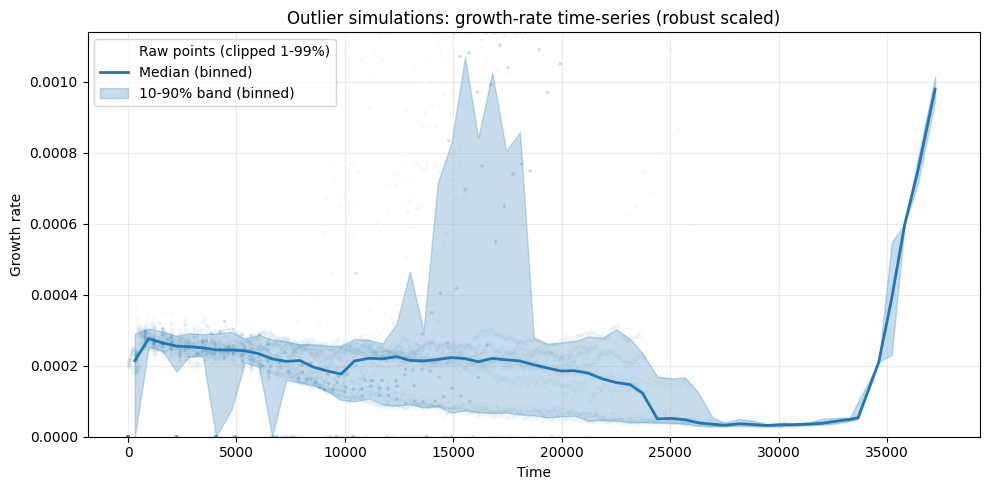

In [7]:
"""Growth rate plot"""
plot_df = ts_outlier[[x_col, col_growth]].dropna().copy()
plot_df = plot_df.sort_values(x_col)

# Keep the display robust against extreme spikes
lo = float(plot_df[col_growth].quantile(0.01))
hi = float(plot_df[col_growth].quantile(0.99))
plot_df['y_clip'] = plot_df[col_growth].clip(lo, hi)

# Bin dense x-values so ribbon/line are readable
n_bins = min(200, max(40, int(np.sqrt(len(plot_df)) // 2)))
plot_df['_x_bin'] = pd.cut(plot_df[x_col], bins=n_bins, include_lowest=True)
stats = (
    plot_df.groupby('_x_bin', observed=True)
    .agg(
        x_mid=(x_col, 'median'),
        q10=('y_clip', lambda s: s.quantile(0.10)),
        median=('y_clip', 'median'),
        q90=('y_clip', lambda s: s.quantile(0.90)),
    )
    .reset_index(drop=True)
    .sort_values('x_mid')
)

# Plot a subsample of raw points for texture without over-drawing
max_points = 30000
if len(plot_df) > max_points:
    scatter_df = plot_df.sample(n=max_points, random_state=0)
else:
    scatter_df = plot_df

plt.figure(figsize=(10, 5))
plt.scatter(scatter_df[x_col], scatter_df['y_clip'], s=6, alpha=0.02, color='tab:blue', edgecolors='none', label='Raw points (clipped 1-99%)')
plt.plot(stats['x_mid'], stats['median'], color='tab:blue', lw=2, label='Median (binned)')
plt.fill_between(stats['x_mid'], stats['q10'], stats['q90'], color='tab:blue', alpha=0.25, label='10-90% band (binned)')
plt.title('Outlier simulations: growth-rate time-series (robust scaled)')
plt.xlabel(x_label)
plt.ylabel('Growth rate')
plt.ylim(lo, hi)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

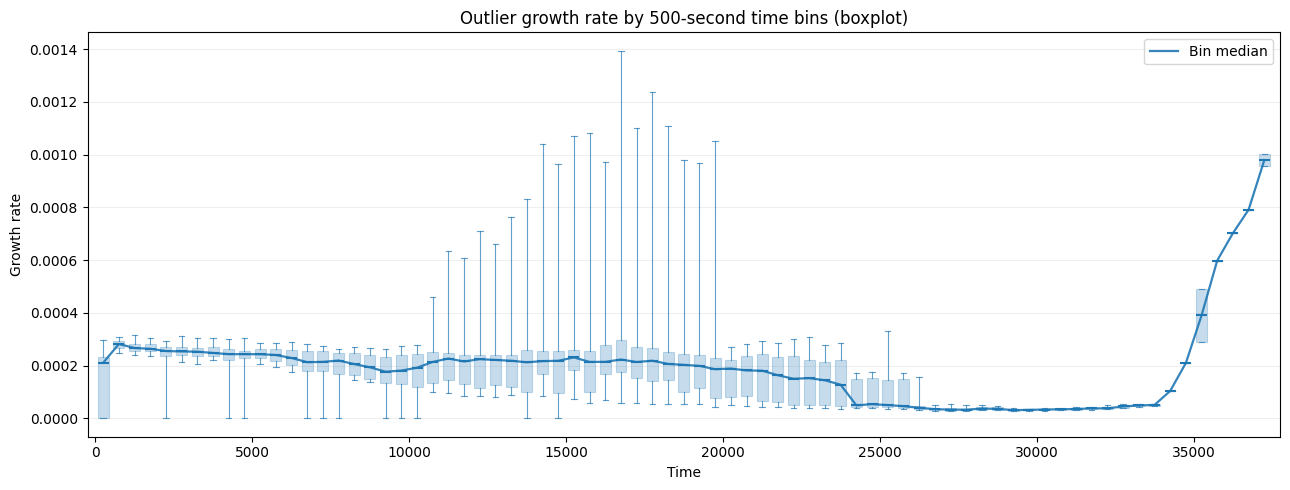

In [16]:
"""Growth rate plot - boxplot per 500-second interval for outliers"""
from matplotlib.ticker import MaxNLocator, ScalarFormatter

if col_time is None:
    raise KeyError('No time column available in parquet schema, so fixed-second binning cannot be applied.')

g_df = ts_outlier[[col_time, col_growth]].copy()
g_df[col_time] = pd.to_numeric(g_df[col_time], errors='coerce')
g_df[col_growth] = pd.to_numeric(g_df[col_growth], errors='coerce')
g_df = g_df.dropna().sort_values(col_time)
if g_df.empty:
    raise RuntimeError('No valid outlier growth-rate rows with time values.')

bin_sec = 500.0
g_df['time_bin_start'] = (np.floor(g_df[col_time] / bin_sec) * bin_sec).astype(float)

# Group to build boxplot data
by_bin = g_df.groupby('time_bin_start', observed=True)[col_growth]
bin_starts = np.array(sorted(by_bin.groups.keys()), dtype=float)
box_data = [by_bin.get_group(b).values for b in bin_starts]
positions = bin_starts + (bin_sec / 2.0)

# Median trend for easier reading
median_series = by_bin.median().reindex(bin_starts).values

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(
    box_data,
    positions=positions,
    widths=bin_sec * 0.7,
    showfliers=False,
    patch_artist=True,
    whis=(5, 95), #set whiskers at percentile bounds
    manage_ticks=False,
    medianprops={'color': 'tab:blue', 'linewidth': 1.5},
    boxprops={'facecolor': 'tab:blue', 'alpha': 0.25, 'edgecolor': 'tab:blue', 'linewidth': 0.8},
    whiskerprops={'color': 'tab:blue', 'alpha': 0.7, 'linewidth': 0.8},
    capprops={'color': 'tab:blue', 'alpha': 0.7, 'linewidth': 0.8},
)
ax.plot(positions, median_series, color='tab:blue', linewidth=1.6, alpha=0.9, label='Bin median')

# Keep x-axis notation consistent and readable (numeric time, sparse ticks)
ax.set_xlabel(x_label)
ax.set_ylabel('Growth rate')
ax.set_title('Outlier growth rate by 500-second time bins (boxplot)')
ax.set_xlim(positions.min() - bin_sec, positions.max() + bin_sec)
ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
xfmt = ScalarFormatter(useOffset=False)
xfmt.set_scientific(False)
ax.xaxis.set_major_formatter(xfmt)
ax.grid(alpha=0.2, axis='y')
ax.legend()
fig.tight_layout()
plt.show()

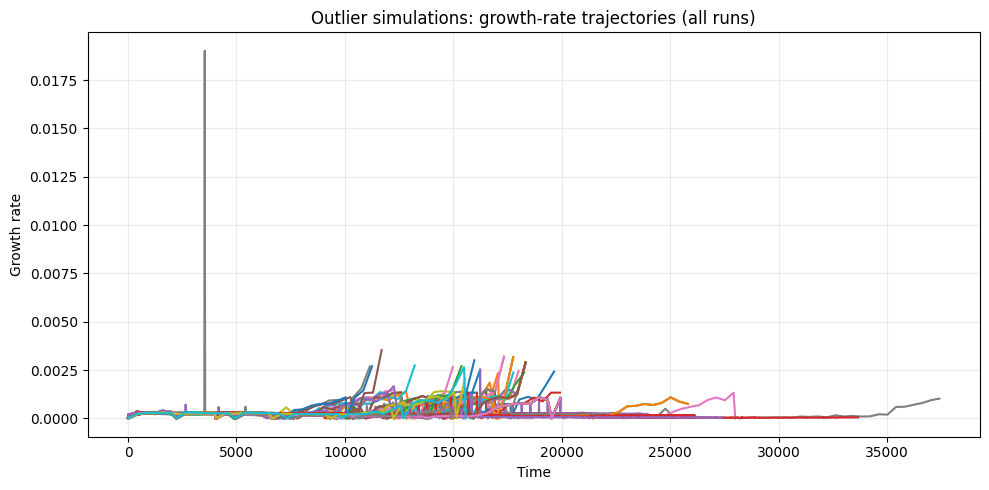

In [ ]:
"""Growth rate plot - all outlier runs as full lines (no trimming)"""
out_dir = Path()
plot_df = ts_outlier[[x_col, col_growth, '_run_key']].copy()
plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors='coerce')
plot_df[col_growth] = pd.to_numeric(plot_df[col_growth], errors='coerce')
plot_df = plot_df.dropna(subset=[x_col, col_growth, '_run_key']).sort_values(['_run_key', x_col])

if plot_df.empty:
    raise RuntimeError('No valid outlier growth-rate rows to plot.')

plt.figure(figsize=(10, 5))
for _, g in plot_df.groupby('_run_key', sort=False):
    run_curve = g.groupby(x_col, as_index=False)[col_growth].mean().sort_values(x_col)
    if len(run_curve) >= 2:
        plt.plot(run_curve[x_col], run_curve[col_growth])

plt.title('Outlier simulations: growth-rate trajectories (all runs)')
plt.xlabel(x_label)
plt.ylabel('Growth rate')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Dry mass

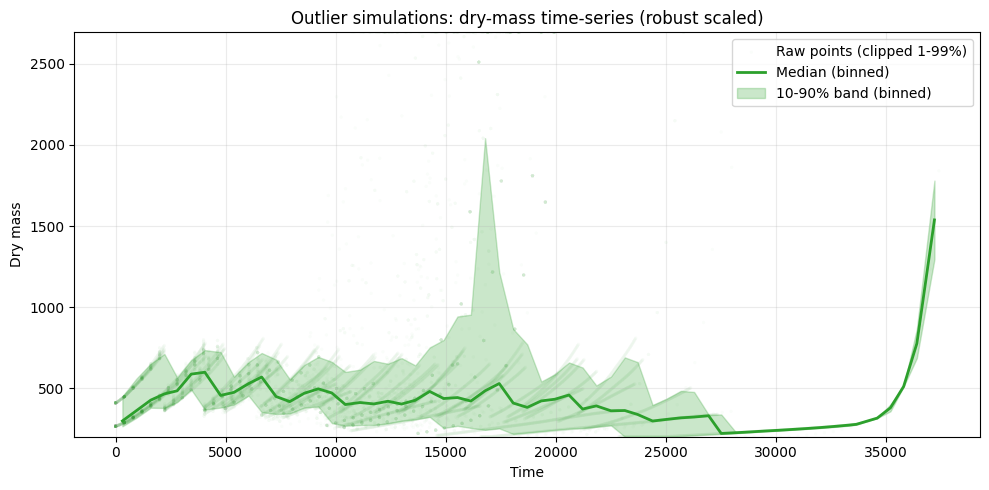

In [19]:
"""Dry mass plot"""
col_dry_mass = pick_col(ts_outlier, ['dry_mass', 'listeners__mass__dry_mass', 'dryMass', 'mass'], required=True)

mass_df = ts_outlier[[x_col, col_dry_mass]].copy()
mass_df[col_dry_mass] = pd.to_numeric(mass_df[col_dry_mass], errors='coerce')
mass_df = mass_df.dropna().sort_values(x_col)
if mass_df.empty:
    raise RuntimeError('No valid dry-mass rows after numeric conversion.')

# Robust display range (clip only for visualization)
lo = float(mass_df[col_dry_mass].quantile(0.01))
hi = float(mass_df[col_dry_mass].quantile(0.99))
mass_df['y_clip'] = mass_df[col_dry_mass].clip(lo, hi)

# Bin x-axis to reduce noise and show stable spread
n_bins = min(200, max(40, int(np.sqrt(len(mass_df)) // 2)))
mass_df['_x_bin'] = pd.cut(mass_df[x_col], bins=n_bins, include_lowest=True)
stats = (
    mass_df.groupby('_x_bin', observed=True)
    .agg(
        x_mid=(x_col, 'median'),
        q10=('y_clip', lambda s: s.quantile(0.10)),
        median=('y_clip', 'median'),
        q90=('y_clip', lambda s: s.quantile(0.90)),
    )
    .reset_index(drop=True)
    .sort_values('x_mid')
)

# Raw-point texture via subsampling
max_points = 30000
scatter_df = mass_df.sample(n=max_points, random_state=0) if len(mass_df) > max_points else mass_df

plt.figure(figsize=(10, 5))
plt.scatter(scatter_df[x_col], scatter_df['y_clip'], s=6, alpha=0.02, color='tab:green', edgecolors='none', label='Raw points (clipped 1-99%)')
plt.plot(stats['x_mid'], stats['median'], color='tab:green', lw=2, label='Median (binned)')
plt.fill_between(stats['x_mid'], stats['q10'], stats['q90'], color='tab:green', alpha=0.25, label='10-90% band (binned)')
plt.title('Outlier simulations: dry-mass time-series (robust scaled)')
plt.xlabel(x_label)
plt.ylabel('Dry mass')
plt.ylim(lo, hi)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

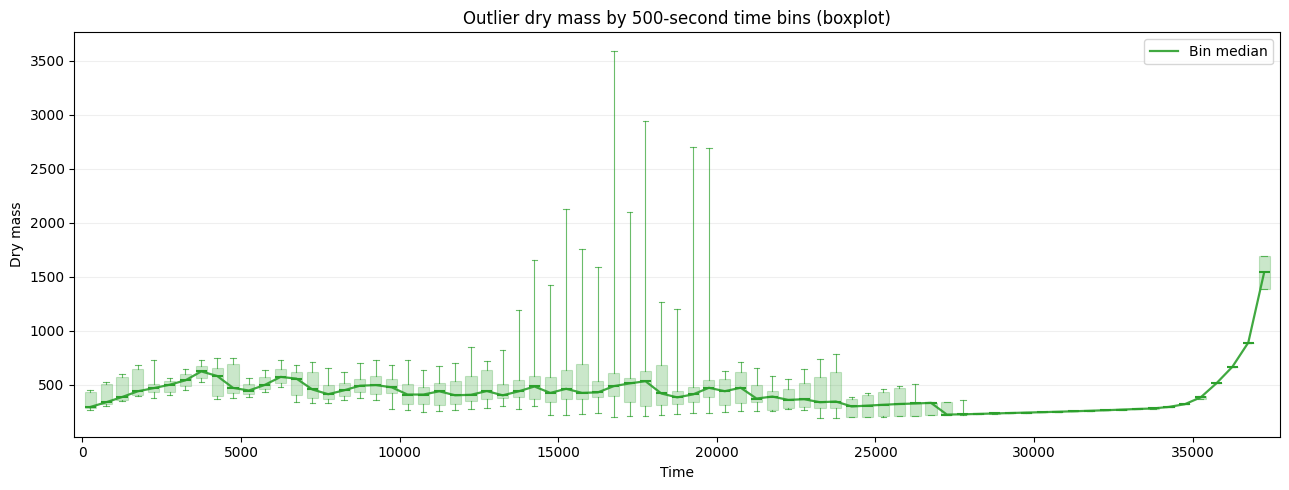

In [20]:
"""Dry mass plot - boxplot per 500-second interval for outliers"""
from matplotlib.ticker import MaxNLocator, ScalarFormatter

if col_time is None:
    raise KeyError('No time column available in parquet schema, so fixed-second binning cannot be applied.')

col_dry_mass = pick_col(ts_outlier, ['dry_mass', 'listeners__mass__dry_mass', 'dryMass', 'mass'], required=True)

d_df = ts_outlier[[col_time, col_dry_mass]].copy()
d_df[col_time] = pd.to_numeric(d_df[col_time], errors='coerce')
d_df[col_dry_mass] = pd.to_numeric(d_df[col_dry_mass], errors='coerce')
d_df = d_df.dropna().sort_values(col_time)
if d_df.empty:
    raise RuntimeError('No valid outlier dry-mass rows with time values.')

bin_sec = 500.0
d_df['time_bin_start'] = (np.floor(d_df[col_time] / bin_sec) * bin_sec).astype(float)

# Group to build boxplot data
by_bin = d_df.groupby('time_bin_start', observed=True)[col_dry_mass]
bin_starts = np.array(sorted(by_bin.groups.keys()), dtype=float)
box_data = [by_bin.get_group(b).values for b in bin_starts]
positions = bin_starts + (bin_sec / 2.0)

# Median trend for easier reading
median_series = by_bin.median().reindex(bin_starts).values

fig, ax = plt.subplots(figsize=(13, 5))
ax.boxplot(
    box_data,
    positions=positions,
    widths=bin_sec * 0.7,
    showfliers=False,
    patch_artist=True,
    whis=(5, 95),
    manage_ticks=False,
    medianprops={'color': 'tab:green', 'linewidth': 1.5},
    boxprops={'facecolor': 'tab:green', 'alpha': 0.25, 'edgecolor': 'tab:green', 'linewidth': 0.8},
    whiskerprops={'color': 'tab:green', 'alpha': 0.7, 'linewidth': 0.8},
    capprops={'color': 'tab:green', 'alpha': 0.7, 'linewidth': 0.8},
)
ax.plot(positions, median_series, color='tab:green', linewidth=1.6, alpha=0.9, label='Bin median')

ax.set_xlabel(x_label)
ax.set_ylabel('Dry mass')
ax.set_title('Outlier dry mass by 500-second time bins (boxplot)')
ax.set_xlim(positions.min() - bin_sec, positions.max() + bin_sec)
ax.xaxis.set_major_locator(MaxNLocator(nbins=8))
xfmt = ScalarFormatter(useOffset=False)
xfmt.set_scientific(False)
ax.xaxis.set_major_formatter(xfmt)
ax.grid(alpha=0.2, axis='y')
ax.legend()
fig.tight_layout()
plt.show()

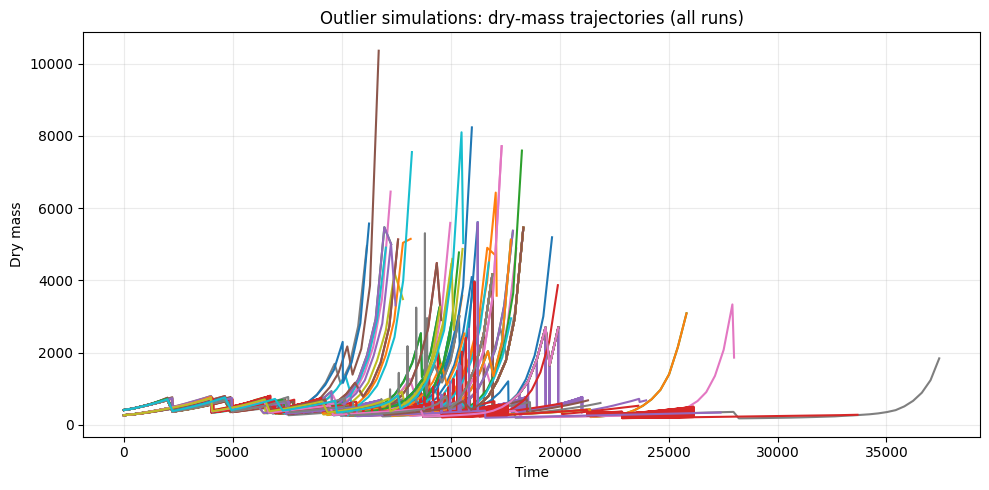

In [21]:
"""Dry mass plot - all outlier runs as full lines (no trimming)"""
col_dry_mass = pick_col(ts_outlier, ['dry_mass', 'listeners__mass__dry_mass', 'dryMass', 'mass'], required=True)

plot_df = ts_outlier[[x_col, col_dry_mass, '_run_key']].copy()
plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors='coerce')
plot_df[col_dry_mass] = pd.to_numeric(plot_df[col_dry_mass], errors='coerce')
plot_df = plot_df.dropna(subset=[x_col, col_dry_mass, '_run_key']).sort_values(['_run_key', x_col])

if plot_df.empty:
    raise RuntimeError('No valid outlier dry-mass rows to plot.')

plt.figure(figsize=(10, 5))
for _, g in plot_df.groupby('_run_key', sort=False):
    run_curve = g.groupby(x_col, as_index=False)[col_dry_mass].mean().sort_values(x_col)
    if len(run_curve) >= 2:
        plt.plot(run_curve[x_col], run_curve[col_dry_mass])

plt.title('Outlier simulations: dry-mass trajectories (all runs)')
plt.xlabel(x_label)
plt.ylabel('Dry mass')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Plot for genes that only show spark in mass or growth rate

#### Protein Level

#### RNA Level

# Compare to wcEcoli sim

In [5]:
import pandas as pd

wc_path = "/user/home/il22158/work/vEcoli/surrogate/comparison_to_new_wcEcoli_sim/ko_master_results.csv"
my_path = "/user/home/il22158/work/vEcoli/surrogate/results/ko_runs_with_success_generation.csv"

wc = pd.read_csv(wc_path)
my = pd.read_csv(my_path)

# Pick an available max-gen column from wcEcoli summary.
for c in ["max_gen", "max_gen_min", "max_gen_mean"]:
    if c in wc.columns:
        wc_max_col = c
        break
else:
    raise ValueError("No max_gen-like column found in ko_master_results.csv")

# Expand operon-level eg_ids so each gene gets its own row.
wc_expanded = wc.copy()
wc_expanded["eg_ids"] = wc_expanded["eg_ids"].astype(str).str.split(",")
wc_expanded = wc_expanded.explode("eg_ids")
wc_expanded["gene_id"] = wc_expanded["eg_ids"].str.strip()
wc_expanded["wc_max_gen"] = pd.to_numeric(wc_expanded[wc_max_col], errors="coerce")
wc_expanded["wc_success"] = wc_expanded["wc_max_gen"] >= 7

# Your success definition: failed_before_gen8 == 0.
my_cmp = my.copy()
my_cmp["gene_id"] = my_cmp["gene_id"].astype(str).str.strip()
my_cmp["my_failed_before_gen8"] = pd.to_numeric(my_cmp["failed_before_gen8"], errors="coerce")
my_cmp["my_success"] = my_cmp["my_failed_before_gen8"] == 0

# Keep one row per gene before comparison.
wc_gene = (
    wc_expanded.sort_values(["gene_id", "wc_max_gen"], ascending=[True, False])
    .drop_duplicates(subset=["gene_id"], keep="first")
    [["gene_id", "wc_max_gen", "wc_success"]]
)

my_gene = (
    my_cmp.sort_values(["gene_id", "max_success_generation"], ascending=[True, False])
    .drop_duplicates(subset=["gene_id"], keep="first")
    [["gene_id", "my_failed_before_gen8", "my_success", "max_success_generation"]]
)

cmp = my_gene.merge(wc_gene, on="gene_id", how="inner")
cmp["match"] = cmp["my_success"] == cmp["wc_success"]

missing_in_wc = my_gene.loc[~my_gene["gene_id"].isin(wc_gene["gene_id"]), ["gene_id"]]

n_overlap = len(cmp)
n_match = int(cmp["match"].sum()) if n_overlap else 0
n_mismatch = int((~cmp["match"]).sum()) if n_overlap else 0

print(f"col={wc_max_col} overlap={n_overlap} match={n_match} mismatch={n_mismatch} missing_in_wc={len(missing_in_wc)}")

if n_mismatch:
    display(
        cmp.loc[
            ~cmp["match"],
            ["gene_id", "my_failed_before_gen8", "max_success_generation", "wc_max_gen"],
        ]
        .sort_values("gene_id")
        .head(20)
    )

col=max_gen_min overlap=52 match=27 mismatch=25 missing_in_wc=410


,gene_id,my_failed_before_gen8,max_success_generation,wc_max_gen
2,EG10864,1,5,7.0
6,EG10868,1,6,7.0
7,EG10869,1,6,7.0
9,EG10872,1,5,7.0
11,EG10875,1,6,7.0
12,EG10876,1,6,7.0
14,EG10879,1,6,7.0
16,EG10881,1,5,7.0
19,EG10884,1,6,7.0
21,EG10886,1,5,7.0


In [7]:
from pathlib import Path

out_dir = Path("/user/home/il22158/work/vEcoli/surrogate/comparison_to_new_wcEcoli_sim")
out_dir.mkdir(parents=True, exist_ok=True)

printed_table = (
    cmp.loc[
        ~cmp["match"],
        ["gene_id", "my_failed_before_gen8", "max_success_generation", "wc_max_gen"],
    ]
    .sort_values("gene_id")
)

printed_table.to_csv(out_dir / "ko_fate_mismatches_printed_table.csv", index=False)

# GO term and BioCyc search

In [8]:
# Annotate outlier genes with GO terms from MyGene.info and group RNA-related genes.
# Data source: https://mygene.info/ (aggregates NCBI/UniProt/GO)

from pathlib import Path
import json
import ssl
import urllib.parse
import urllib.request
from urllib.error import URLError

import certifi
import pandas as pd

# ---------- Inputs ----------
outlier_csv = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_genes_all_unique_with_criteria.csv')
# Set this to an integer (e.g., 50) for quick tests; keep None for full list.
max_genes_for_test = None

# SSL handling:
# 1) strict verification using certifi CA bundle (recommended)
# 2) optional insecure fallback for environments with intercepting proxy/certs
allow_insecure_ssl_fallback = True

# ---------- RNA term matching rules ----------
rna_keyword_groups = {
    'RNA_replication_transcription': [
        'rna replication',
        'rna biosynthetic process',
        'rna metabolic process',
        'transcription',
        'rna polymerase',
        'dna-templated transcription',
    ],
    'RNA_processing_stability': [
        'rna processing',
        'rrna processing',
        'trna processing',
        'mrna processing',
        'rna degradation',
        'ribonuclease',
        'rna helicase',
        'rna methyltransferase',
    ],
    'Ribosome_translation_rRNA_tRNA': [
        'ribosome',
        'structural constituent of ribosome',
        'translation',
        'ribosomal subunit',
        'rrna',
        'trna',
    ],
}

all_keywords = sorted({kw.lower() for kws in rna_keyword_groups.values() for kw in kws})


def _to_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return [x]


def extract_go_terms(hit):
    go = hit.get('go', {}) if isinstance(hit, dict) else {}
    terms = []
    for namespace in ['BP', 'CC', 'MF']:
        block = go.get(namespace)
        for item in _to_list(block):
            if isinstance(item, dict) and item.get('term'):
                terms.append(item['term'])
    return sorted(set(terms))


def safe_urlopen(req, timeout=60):
    strict_ctx = ssl.create_default_context(cafile=certifi.where())
    try:
        return urllib.request.urlopen(req, timeout=timeout, context=strict_ctx)
    except URLError as e:
        if not allow_insecure_ssl_fallback:
            raise
        if 'CERTIFICATE_VERIFY_FAILED' not in str(e):
            raise

        print('Warning: SSL verification failed with strict CA bundle; retrying with unverified SSL context.')
        insecure_ctx = ssl._create_unverified_context()
        return urllib.request.urlopen(req, timeout=timeout, context=insecure_ctx)


def query_mygene_by_symbol(symbol, species='511145'):
    """
    Query MyGene query endpoint for one symbol.
    Returns best hit dict, or {} if no hit.
    """
    base_url = 'https://mygene.info/v3/query'
    q = f'symbol:{symbol} AND taxid:{species}'
    params = {
        'q': q,
        'fields': 'symbol,name,entrezgene,go.BP.term,go.CC.term,go.MF.term,summary',
        'size': '1',
    }
    url = f"{base_url}?{urllib.parse.urlencode(params)}"
    req = urllib.request.Request(url, method='GET')

    with safe_urlopen(req, timeout=60) as resp:
        data = json.loads(resp.read().decode('utf-8'))

    hits = data.get('hits', []) if isinstance(data, dict) else []
    if not hits:
        return {}
    return hits[0]


def query_mygene_symbols(symbols, species='511145'):
    best = {}
    for sym in symbols:
        hit = query_mygene_by_symbol(sym, species=species)
        if hit:
            best[sym] = hit
    return best


def match_rna_terms(go_terms):
    matches = []
    lower_terms = [t.lower() for t in go_terms]
    for term in lower_terms:
        for kw in all_keywords:
            if kw in term:
                matches.append(term)
                break
    return sorted(set(matches))


def assign_group(term_matches):
    if not term_matches:
        return 'Not_RNA_related'

    matched_groups = []
    for group_name, kws in rna_keyword_groups.items():
        kws_l = [k.lower() for k in kws]
        if any(any(k in t for k in kws_l) for t in term_matches):
            matched_groups.append(group_name)

    if not matched_groups:
        return 'RNA_related_other'
    return '|'.join(matched_groups)


# ---------- Load genes ----------
outlier_df = pd.read_csv(outlier_csv)
if 'gene_symbol' not in outlier_df.columns:
    raise ValueError(f"Expected 'gene_symbol' column in {outlier_csv}")

symbols = outlier_df['gene_symbol'].dropna().astype(str).str.strip()
symbols = symbols[symbols != ''].unique().tolist()
if max_genes_for_test is not None:
    symbols = symbols[:max_genes_for_test]

print(f'Querying MyGene for {len(symbols)} gene symbols...')
mygene_hits = query_mygene_symbols(symbols)
print(f'Found annotations for {len(mygene_hits)} / {len(symbols)} symbols')

# ---------- Build annotation table ----------
rows = []
for sym in symbols:
    hit = mygene_hits.get(sym, {})
    go_terms = extract_go_terms(hit)
    rna_matches = match_rna_terms(go_terms)
    rows.append(
        {
            'gene_symbol': sym,
            'mygene_found': bool(hit),
            'mygene_name': hit.get('name', None),
            'entrezgene': hit.get('entrezgene', None),
            'n_go_terms': len(go_terms),
            'go_terms': '; '.join(go_terms),
            'rna_match_terms': '; '.join(rna_matches),
            'is_rna_related': len(rna_matches) > 0,
            'rna_group': assign_group(rna_matches),
        }
    )

anno_df = pd.DataFrame(rows)

# Join back to all outlier metadata
result_df = outlier_df.merge(anno_df, on='gene_symbol', how='left')

# ---------- Outputs ----------
out_dir = outlier_csv.parent
all_out = out_dir / 'outlier_genes_with_go_rna_grouping.csv'
rna_only_out = out_dir / 'outlier_genes_rna_related_only.csv'

result_df.to_csv(all_out, index=False)
rna_only_df = result_df[result_df['is_rna_related'] == True].copy()
rna_only_df.to_csv(rna_only_out, index=False)

print(f'Wrote: {all_out}')
print(f'Wrote: {rna_only_out}')

print('\nRNA group counts:')
display(
    rna_only_df['rna_group']
    .value_counts(dropna=False)
    .rename_axis('rna_group')
    .reset_index(name='n_genes')
)

print('\nRNA-related outlier genes (preview):')
display(
    rna_only_df[
        [
            'gene_symbol',
            'mygene_name',
            'rna_group',
            'rna_match_terms',
            'n_go_terms',
        ]
    ].sort_values(['rna_group', 'gene_symbol']).head(10)
)


Querying MyGene for 52 gene symbols...
Found annotations for 52 / 52 symbols
Wrote: /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_genes_with_go_rna_grouping.csv
Wrote: /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_genes_rna_related_only.csv

RNA group counts:


,rna_group,n_genes
0,Ribosome_translation_rRNA_tRNA,47
1,RNA_replication_transcription|RNA_processing_s...,1
2,RNA_replication_transcription|Ribosome_transla...,1



RNA-related outlier genes (preview):


,gene_symbol,mygene_name,rna_group,rna_match_terms,n_go_terms
3,rplD,50S ribosomal subunit protein L4,RNA_replication_transcription|RNA_processing_s...,cytoplasmic translation; cytosolic large ribos...,25
34,rpsJ,30S ribosomal subunit protein S10,RNA_replication_transcription|Ribosome_transla...,cytoplasmic translation; cytosolic small ribos...,16
48,cysS,cysteine--tRNA ligase,Ribosome_translation_rRNA_tRNA,aminoacyl-trna ligase activity; cysteine-trna ...,12
0,rplA,50S ribosomal subunit protein L1,Ribosome_translation_rRNA_tRNA,cytoplasmic translation; cytosolic large ribos...,17
1,rplB,50S ribosomal subunit protein L2,Ribosome_translation_rRNA_tRNA,cytoplasmic translation; cytosolic large ribos...,16
2,rplC,50S ribosomal subunit protein L3,Ribosome_translation_rRNA_tRNA,cytoplasmic translation; cytosolic large ribos...,12
4,rplE,50S ribosomal subunit protein L5,Ribosome_translation_rRNA_tRNA,5s rrna binding; cytoplasmic translation; cyto...,13
5,rplF,50S ribosomal subunit protein L6,Ribosome_translation_rRNA_tRNA,cytoplasmic translation; cytosolic large ribos...,13
43,rplI,50S ribosomal subunit protein L9,Ribosome_translation_rRNA_tRNA,cytoplasmic translation; cytosolic large ribos...,12
6,rplK,50S ribosomal subunit protein L11,Ribosome_translation_rRNA_tRNA,cytoplasmic translation; cytosolic large ribos...,15


In [14]:
# Short BioCyc-only cross-check for the 3 genes marked Not_RNA_related.
# This is independent from previous MyGene/UniProt workflows.

from pathlib import Path
import re
import html

import certifi
import pandas as pd
import requests

# Genes from the prior result table
targets = [
    {'gene_id': 'EG10707', 'gene_symbol': 'pheA'},
    {'gene_id': 'EG11024', 'gene_symbol': 'trpA'},
    {'gene_id': 'EG11026', 'gene_symbol': 'trpC'},
]

# Strict RNA-focused keywords (avoid generic terms like transcription/translation)
rna_keywords = [
    'rna replication', 'rna polymerase', 'rna processing', 'rna degradation',
    'ribonuclease', 'rna helicase', 'rna methyltransferase',
    'rrna', 'trna', 'mrna processing', 'ribosome biogenesis',
]


def fetch_biocyc_text(gene_id):
    url = f'https://ecocyc.org/gene?orgid=ECOLI&id={gene_id}'
    headers = {'User-Agent': 'Mozilla/5.0'}

    # Prefer strict TLS; allow fallback for cluster certificate environments.
    try:
        r = requests.get(url, headers=headers, timeout=30, verify=certifi.where())
        r.raise_for_status()
    except requests.exceptions.SSLError:
        r = requests.get(url, headers=headers, timeout=30, verify=False)
        r.raise_for_status()

    text = html.unescape(re.sub(r'<[^>]+>', ' ', r.text))
    text = re.sub(r'\s+', ' ', text)

    # Restrict to the central content region to reduce site-level boilerplate noise.
    start = text.find('SummaryGO Annotations')
    end = text.find('Gene-Reaction Schematic')
    if start != -1 and end != -1 and end > start:
        text = text[start:end]

    return url, text


def first_snippet(text, keyword, width=110):
    i = text.lower().find(keyword)
    if i < 0:
        return ''
    start = max(0, i - width)
    end = min(len(text), i + len(keyword) + width)
    return text[start:end]


rows = []
for g in targets:
    url, txt = fetch_biocyc_text(g['gene_id'])
    txt_l = txt.lower()
    hits = [k for k in rna_keywords if k in txt_l]
    snippet = first_snippet(txt, hits[0]) if hits else ''

    rows.append(
        {
            'gene_id': g['gene_id'],
            'gene_symbol': g['gene_symbol'],
            'biocyc_url': url,
            'biocyc_rna_keyword_hits': '; '.join(sorted(set(hits))),
            'biocyc_is_rna_related_by_keyword': bool(hits),
            'biocyc_example_snippet': snippet,
        }
    )

biocyc_df = pd.DataFrame(rows)

# Save and display
out_path = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/biocyc_three_gene_rna_check.csv')
biocyc_df.to_csv(out_path, index=False)
print(f'Wrote: {out_path}')
display(biocyc_df)

print('\nInterpretation note: keyword-based BioCyc check; no hit means no explicit RNA-specific signal found on the gene page text block.')

Wrote: /user/home/il22158/work/vEcoli/surrogate/results/failure/biocyc_three_gene_rna_check.csv


,gene_id,gene_symbol,biocyc_url,biocyc_rna_keyword_hits,biocyc_is_rna_related_by_keyword,biocyc_example_snippet
0,EG10707,pheA,https://ecocyc.org/gene?orgid=ECOLI&id=EG10707,,False,
1,EG11024,trpA,https://ecocyc.org/gene?orgid=ECOLI&id=EG11024,,False,
2,EG11026,trpC,https://ecocyc.org/gene?orgid=ECOLI&id=EG11026,,False,



Interpretation note: keyword-based BioCyc check; no hit means no explicit RNA-specific signal found on the gene page text block.


# Logic about building ML surrogate

For this surrogate, the target is derived from pq time-series dry-mass trajectories rather than summary CSV growth averages. This aligns with simulation mechanics: advancement to the next generation is driven by mass accumulation, so per-generation dry-mass fold change is directly tied to viability and growth dynamics.

## Notation and target construction
Let run $i$ have a maximum horizon of $G=8$ generations.

- $M_{i,g}^{\text{start}}$: dry mass at start of generation $g$
- $M_{i,g}^{\text{end}}$: dry mass at end of generation $g$
- Per-generation fold change:
$$f_{i,g}=\frac{M_{i,g}^{\text{end}}}{M_{i,g}^{\text{start}}}$$
- Log fold change:
$$z_{i,g}=\log f_{i,g}$$

If the run reaches only $n_i<8$ generations (early termination), define a fixed penalty fold change $f_{\text{pen}}\in(0,1]$ for missing generations, with $z_{\text{pen}}=\log(f_{\text{pen}})$.
The horizon-normalized scalar target is then
$$\bar z_i=\frac{1}{G}\left(\sum_{g=1}^{n_i} z_{i,g}+\sum_{g=n_i+1}^{G} z_{\text{pen}}\right), \qquad y_i=\exp(\bar z_i).$$

Interpretation: $y_i$ is an effective per-generation fold-change score over a fixed 8-generation horizon, where early failure is encoded through penalty-filled missing generations.

## Why this form is useful
- Multiplicative growth becomes additive in log space, making aggregation stable and interpretable.
- A fixed horizon gives targets comparable across runs with different stopping points.
- Penalty-filling keeps a single scalar regression target while still encoding failure severity.

## Suggested training target
Use $\bar z_i$ (log-space target) for regression, then map back with $\hat y_i=\exp(\hat z_i)$ for interpretation.
A simple weighted objective is
$$\mathcal{L}=\frac{1}{N}\sum_{i=1}^{N} w_i\,(\hat z_i-\bar z_i)^2,\quad w_i=1+\lambda\,\mathbf{1}[n_i<8],$$
where $\lambda\ge 0$ increases emphasis on failed runs if needed.

## Notes on censoring semantics
Early-terminated runs are effectively right-censored with respect to full-horizon growth potential. The penalty-fill approach is a pragmatic surrogate-target design that preserves single-output simplicity while reflecting censoring/failure information.

## References
- Box, G. E. P., and Cox, D. R. (1964). An Analysis of Transformations. Journal of the Royal Statistical Society, Series B.
- Cox, D. R. (1972). Regression Models and Life-Tables. Journal of the Royal Statistical Society, Series B.
- Kalbfleisch, J. D., and Prentice, R. L. (2002). The Statistical Analysis of Failure Time Data (2nd ed.).

# New Data Preprocessing - separate to generations

**Data**
- gene list:
/user/home/il22158/work/vEcoli/reading/imported/Single_KO_RNA_names.txt

- Time-series data
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet; /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_default_all.parquet
- explanation:
1. the single-knockout variants are saved in first four timeseries files, and the baseline simulation are the one labelled as baseline under "all media conditions..." simulation folder.
2. 2 baseline simulation (wildtype) can be found in /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_seed100_all.csv and /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_summary_default_all.csv.

## Code testing
Coverted to function - preprocess.py

In [ ]:
# Prototype conversion: rebuild generation labels for one variant using raw filename endpoints
from pathlib import Path
import numpy as np
import pandas as pd

# ----------
# 1) Choose one run to test (editable)
# ----------
project = 'gene_ko_441imported_2seeds'
variant = 6
lineage_seed = 101

OUT_ROOT = Path('/user/home/il22158/work/vEcoli/out')
RAW_BASE = OUT_ROOT / project / 'history' / f'experiment_id={project}' / f'variant={variant}' / f'lineage_seed={lineage_seed}'
TIMESERIES_PATHS = [
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_441_KOs_seed101_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet'),
    Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed101_all.parquet'),
]

# ----------
# 2) Parse generation endpoint hints from raw filenames
# ----------
raw_rows = []
for p in RAW_BASE.glob('generation=*/agent_id=*/**/*.pq'):
    gen_token = [x for x in p.parts if x.startswith('generation=')]
    if not gen_token:
        continue
    g = int(gen_token[0].split('=')[1])
    # Stem is the last recorded step index in that generation
    step_idx = pd.to_numeric(p.stem, errors='coerce')
    if pd.isna(step_idx):
        continue
    raw_rows.append({'generation': g, 'step_idx_hint': float(step_idx), 'raw_file': str(p)})

raw_meta = pd.DataFrame(raw_rows)
if raw_meta.empty:
    raise RuntimeError(f'No raw generation pq files found under: {RAW_BASE}')

# Keep one representative endpoint per generation (max step index if duplicates exist)
raw_meta = (
    raw_meta.groupby('generation', as_index=False)['step_idx_hint']
    .max()
    .sort_values('generation')
    .reset_index(drop=True)
)

# Calibrate simulation dt from one raw generation file (fallback to 20.0)
first_raw = next(RAW_BASE.glob('generation=*/agent_id=*/**/*.pq'))
first_df = pd.read_parquet(first_raw)
if 'time' in first_df.columns and len(first_df) >= 2:
    t = pd.to_numeric(first_df['time'], errors='coerce').dropna().values
    dt = float(np.nanmedian(np.diff(t))) if len(t) >= 2 else 20.0
    if not np.isfinite(dt) or dt <= 0:
        dt = 20.0
else:
    dt = 20.0

# Convert step-index hints to within-generation end-time hints
raw_meta['gen_end_time_hint'] = (raw_meta['step_idx_hint'] - 1.0) * dt
raw_meta['cum_end_time_hint'] = raw_meta['gen_end_time_hint'].cumsum()
raw_meta['cum_start_time_hint'] = raw_meta['cum_end_time_hint'].shift(fill_value=0.0)

print('Raw generation endpoint hints for selected run:')
display(raw_meta)
print(f'Estimated dt from raw pq = {dt:.3f}')

# ----------
# 3) Load saved extracted pq and isolate this run
# ----------
parts = []
for p in TIMESERIES_PATHS:
    x = pd.read_parquet(p).copy()
    x['source_file'] = p.name
    parts.append(x)
saved = pd.concat(parts, ignore_index=True)

# In saved pq, seed is not explicit; use source file to split seed100/seed101 rows
seed_token = f'seed{lineage_seed}'
saved_run = saved[
    (saved['project'].astype(str) == project)
    & (pd.to_numeric(saved['variant'], errors='coerce') == variant)
    & (saved['source_file'].astype(str).str.contains(seed_token, case=False, na=False))
].copy()

if saved_run.empty:
    raise RuntimeError('No matching rows found in saved pq for selected project/variant/seed token.')

saved_run['time'] = pd.to_numeric(saved_run['time'], errors='coerce')
saved_run['growth_rate'] = pd.to_numeric(saved_run['listeners__mass__instantaneous_growth_rate'], errors='coerce')
saved_run['dry_mass'] = pd.to_numeric(saved_run['listeners__mass__dry_mass'], errors='coerce')
saved_run = saved_run.dropna(subset=['time', 'growth_rate', 'dry_mass']).sort_values('time').reset_index(drop=True)

print(f'Saved rows selected: {len(saved_run)}')
print(f"Saved time range: {saved_run['time'].min():.3f} to {saved_run['time'].max():.3f}")

# ----------
# 4) Reconstruct generation from cumulative endpoint hints
# ----------
bin_edges = np.r_[0.0, raw_meta['cum_end_time_hint'].values]
gen_labels = np.arange(1, len(bin_edges))

# Small tolerance handles slight extraction offsets
tol = max(2.5 * dt, 50.0)
bin_edges_tol = bin_edges.copy()
bin_edges_tol[-1] = bin_edges_tol[-1] + tol

saved_run['generation_reconstructed'] = pd.cut(
    saved_run['time'],
    bins=bin_edges_tol,
    labels=gen_labels,
    include_lowest=True,
    right=True,
).astype('Int64')

# ----------
# 5) Build surrogate-ready per-generation features for this one run
# ----------
gen_table = (
    saved_run.dropna(subset=['generation_reconstructed'])
    .groupby('generation_reconstructed', as_index=False)
    .agg(
        start_time=('time', 'min'),
        end_time=('time', 'max'),
        n_points=('time', 'size'),
        growth_mean=('growth_rate', 'mean'),
        dry_mass_start=('dry_mass', 'first'),
        dry_mass_end=('dry_mass', 'last'),
    )
    .sort_values('generation_reconstructed')
    .reset_index(drop=True)
)
gen_table['fold_change_mass'] = gen_table['dry_mass_end'] / gen_table['dry_mass_start'].replace(0, np.nan)
gen_table['log_fold_change_mass'] = np.log(gen_table['fold_change_mass'])

print('Reconstructed per-generation table (prototype for surrogate input):')
display(gen_table)

# Optional wide format for a single-row surrogate feature target preview
wide = gen_table[['generation_reconstructed', 'growth_mean', 'fold_change_mass', 'log_fold_change_mass']].copy()
wide = wide.set_index('generation_reconstructed')
wide.columns = [f'{c}_g{{}}'.format('') for c in wide.columns]
wide_out = wide.T
print('Wide preview (single-run feature/target style):')
display(wide_out)

Raw generation endpoint hints for selected run:


,generation,step_idx_hint,gen_end_time_hint,cum_end_time_hint,cum_start_time_hint
0,1,112.0,2220.0,2220.0,0.0
1,2,134.0,2660.0,4880.0,2220.0
2,3,175.0,3480.0,8360.0,4880.0
3,4,375.0,7480.0,15840.0,8360.0
4,5,541.0,10800.0,26640.0,15840.0


Estimated dt from raw pq = 20.000
Saved rows selected: 69
Saved time range: 0.000 to 26693.000
Reconstructed per-generation table (prototype for surrogate input):


,generation_reconstructed,start_time,end_time,n_points,growth_mean,dry_mass_start,dry_mass_end,fold_change_mass,log_fold_change_mass
0,1,0.0,2000.0,6,0.000214,411.038504,696.662962,1.694885,0.527615
1,2,2235.0,4635.0,7,0.000148,371.372644,573.037570,1.543026,0.433745
2,3,4906.0,8106.0,9,0.000098,297.461478,428.465929,1.440408,0.364926
3,4,8395.0,15595.0,19,0.000062,219.673786,359.796603,1.637868,0.493395
4,5,15893.0,26293.0,27,0.000041,183.252674,287.830148,1.570674,0.451505


Wide preview (single-run feature/target style):


generation_reconstructed,1,2,3,4,5
growth_mean_g,0.000214,0.000148,0.000098,0.000062,0.000041
fold_change_mass_g,1.694885,1.543026,1.440408,1.637868,1.570674
log_fold_change_mass_g,0.527615,0.433745,0.364926,0.493395,0.451505


# Analyse the outliers

## Locate genes/simulations based on two criteria

- Define failed KO runs: max(generation_reconstructed) < 8 per run.
- Build run-level KO averages:
  - avg_growth = mean(growth_mean)
  - avg_fold = mean(fold_change_mass)
- Define baseline thresholds from seed-default data:
  - base_growth = mean(avg_growth of the first 2 baseline runs)
  - base_fold = mean(avg_fold of the first 2 baseline runs)
- Flag run-level outliers when either condition is true:
  - growth_outlier: avg_growth > base_growth
  - fold_outlier: avg_fold > base_fold
  - outlier = growth_outlier OR fold_outlier
- Plot only outlier failed runs, and only points above corresponding baseline threshold.

Baseline avg growth (2 runs): 2.306e-04
Baseline avg fold (2 runs):   1.88181
Failed runs: 198 | Outlier runs: 90


,run,avg_growth,avg_fold,growth_outlier,fold_outlier,outlier
0,101_100,0.000450,2.122659,True,True,True
1,101_101,0.000399,1.655153,True,False,True
4,117_100,0.000334,3.547278,True,True,True
5,117_101,0.000275,2.754271,True,True,True
6,11_100,0.000356,1.968500,True,True,True
...,...,...,...,...,...,...
186,79_101,0.000145,0.976441,False,False,False
190,84_101,0.000133,0.855928,False,False,False
191,88_100,0.000116,1.069742,False,False,False
192,88_101,0.000123,0.960461,False,False,False


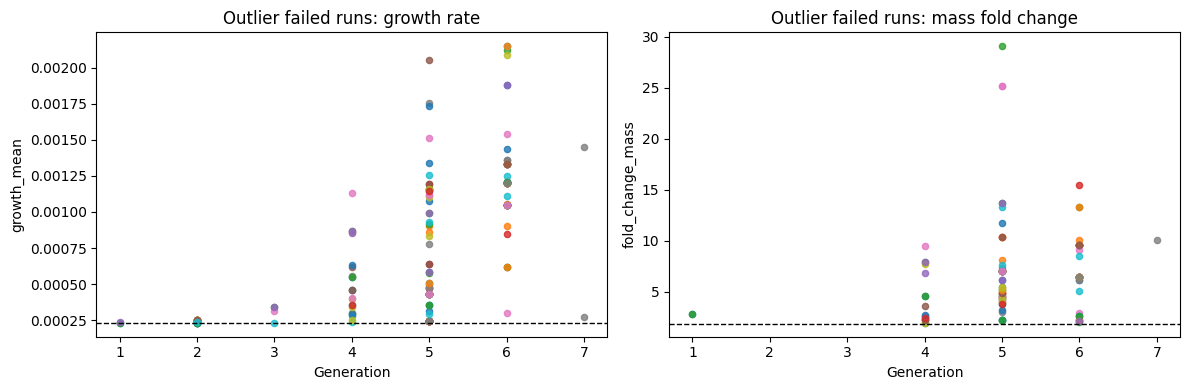

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

res = Path('/user/home/il22158/work/vEcoli/surrogate/results')
ko = pd.read_csv(res / 'surrogate_preprocessed_ko441_generation_long.csv')
base = pd.read_csv(res / 'surrogate_preprocessed_seed_default_generation_long.csv')

for df in (ko, base):
    for c in ['generation_reconstructed', 'growth_mean', 'fold_change_mass', 'variant', 'lineage_seed']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df['run'] = df['variant'].astype('Int64').astype(str) + '_' + df['lineage_seed'].astype('Int64').astype(str)

failed_runs = ko.groupby('run')['generation_reconstructed'].max()
failed_runs = failed_runs[failed_runs < 8].index
ko_failed = ko[ko['run'].isin(failed_runs)].copy()

ko_avg = ko_failed.groupby('run', as_index=False).agg(avg_growth=('growth_mean', 'mean'), avg_fold=('fold_change_mass', 'mean'))
base_avg = base.groupby('run', as_index=False).agg(avg_growth=('growth_mean', 'mean'), avg_fold=('fold_change_mass', 'mean'))
base_growth = base_avg['avg_growth'].head(2).mean()
base_fold = base_avg['avg_fold'].head(2).mean()

ko_avg['growth_outlier'] = ko_avg['avg_growth'] > base_growth
ko_avg['fold_outlier'] = ko_avg['avg_fold'] > base_fold
ko_avg['outlier'] = ko_avg['growth_outlier'] | ko_avg['fold_outlier']
outlier_runs = ko_avg.loc[ko_avg['outlier'], 'run']
plot_df = ko_failed[ko_failed['run'].isin(outlier_runs)].copy()

print(f'Baseline avg growth (2 runs): {base_growth:.3e}')
print(f'Baseline avg fold (2 runs):   {base_fold:.6g}')
print(f'Failed runs: {len(failed_runs)} | Outlier runs: {outlier_runs.nunique()}')
display(ko_avg.sort_values(['outlier', 'run'], ascending=[False, True]))

if plot_df.empty:
    print('No outlier failed runs found with the requested criteria.')
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    for _, g in plot_df.groupby('run'):
        gg = g[g['growth_mean'] > base_growth]
        gf = g[g['fold_change_mass'] > base_fold]
        if not gg.empty:
            ax[0].scatter(gg['generation_reconstructed'], gg['growth_mean'], s=20, alpha=0.8)
        if not gf.empty:
            ax[1].scatter(gf['generation_reconstructed'], gf['fold_change_mass'], s=20, alpha=0.8)
    ax[0].axhline(base_growth, color='black', ls='--', lw=1)
    ax[1].axhline(base_fold, color='black', ls='--', lw=1)
    ax[0].set_title('Outlier failed runs: growth rate')
    ax[1].set_title('Outlier failed runs: mass fold change')
    ax[0].set_xlabel('Generation')
    ax[1].set_xlabel('Generation')
    ax[0].set_ylabel('growth_mean')
    ax[1].set_ylabel('fold_change_mass')
    plt.tight_layout()
    plt.show()

In [5]:
DIR = "/user/home/il22158/work/vEcoli/surrogate/results/failure"
File = "Failred_runs_outliers.csv"
ko_avg.to_csv(Path(DIR) / File, index=False)

In [4]:
# Truth table for outlier criteria overlap (run-level)
tt = (ko_avg.groupby(['growth_outlier', 'fold_outlier']).size()
      .rename('n_runs').reset_index())
tt['group'] = tt.apply(
    lambda r: 'both' if r.growth_outlier and r.fold_outlier
    else ('growth_only' if r.growth_outlier else ('fold_only' if r.fold_outlier else 'neither')),
    axis=1,
 )
display(tt[['growth_outlier', 'fold_outlier', 'group', 'n_runs']].sort_values(['growth_outlier', 'fold_outlier']))

summary = tt.set_index('group')['n_runs']
print(f"both: {int(summary.get('both', 0))}")
print(f"one metric only: {int(summary.get('growth_only', 0) + summary.get('fold_only', 0))}")
print(f"  growth_only: {int(summary.get('growth_only', 0))}")
print(f"  fold_only:   {int(summary.get('fold_only', 0))}")

,growth_outlier,fold_outlier,group,n_runs
0,False,False,neither,108
1,False,True,fold_only,4
2,True,False,growth_only,24
3,True,True,both,62


both: 62
one metric only: 28
  growth_only: 24
  fold_only:   4


growth panel runs (growth_only + both): 86
fold panel runs (fold_only + both):     66
both-criteria runs included in both panels: 62


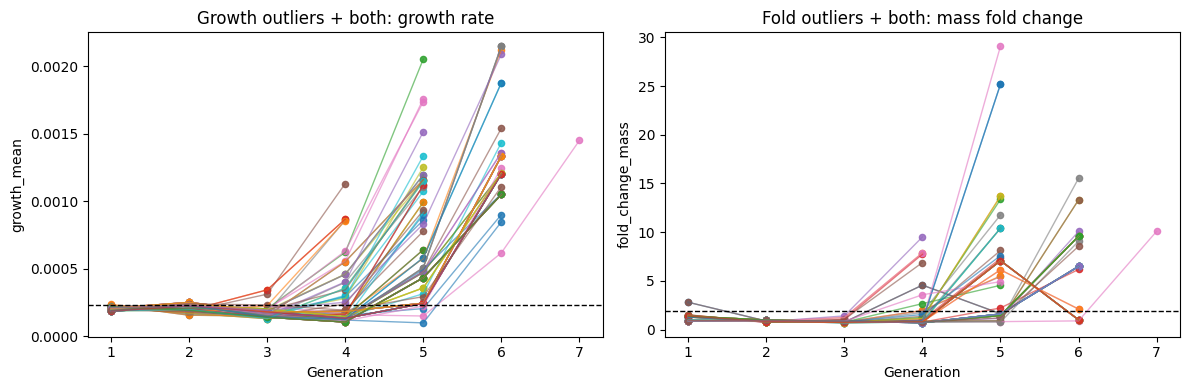

In [14]:
# Reuse ko_avg, ko_failed, base_growth, base_fold from previous cells
growth_only_runs = ko_avg.loc[ko_avg['growth_outlier'] & ~ko_avg['fold_outlier'], 'run']
fold_only_runs = ko_avg.loc[~ko_avg['growth_outlier'] & ko_avg['fold_outlier'], 'run']
both_runs = ko_avg.loc[ko_avg['growth_outlier'] & ko_avg['fold_outlier'], 'run']

growth_panel_runs = pd.Index(growth_only_runs).union(pd.Index(both_runs))
fold_panel_runs = pd.Index(fold_only_runs).union(pd.Index(both_runs))

g_growth = ko_failed[ko_failed['run'].isin(growth_panel_runs)].copy()
g_fold = ko_failed[ko_failed['run'].isin(fold_panel_runs)].copy()

print(f'growth panel runs (growth_only + both): {len(growth_panel_runs)}')
print(f'fold panel runs (fold_only + both):     {len(fold_panel_runs)}')
print(f'both-criteria runs included in both panels: {both_runs.nunique()}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for _, g in g_growth.groupby('run'):
    g = g.sort_values('generation_reconstructed')
    if len(g) > 1:
        ax[0].plot(g['generation_reconstructed'], g['growth_mean'], '-', lw=1, alpha=0.6)
    ax[0].scatter(g['generation_reconstructed'], g['growth_mean'], s=20, alpha=0.85)
for _, g in g_fold.groupby('run'):
    g = g.sort_values('generation_reconstructed')
    if len(g) > 1:
        ax[1].plot(g['generation_reconstructed'], g['fold_change_mass'], '-', lw=1, alpha=0.6)
    ax[1].scatter(g['generation_reconstructed'], g['fold_change_mass'], s=20, alpha=0.85)

ax[0].axhline(base_growth, color='black', ls='--', lw=1)
ax[1].axhline(base_fold, color='black', ls='--', lw=1)
ax[0].set_title('Growth outliers + both: growth rate')
ax[1].set_title('Fold outliers + both: mass fold change')
ax[0].set_xlabel('Generation')
ax[1].set_xlabel('Generation')
ax[0].set_ylabel('growth_mean')
ax[1].set_ylabel('fold_change_mass')
plt.tight_layout()
plt.show()

Total outlier runs: 90
Mapped outlier runs: 90
Unmapped outlier runs: 0
Saved: /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_runs_with_process_label.csv


,Process,n_outlier_runs
0,Translation,86
1,Metabolism,4


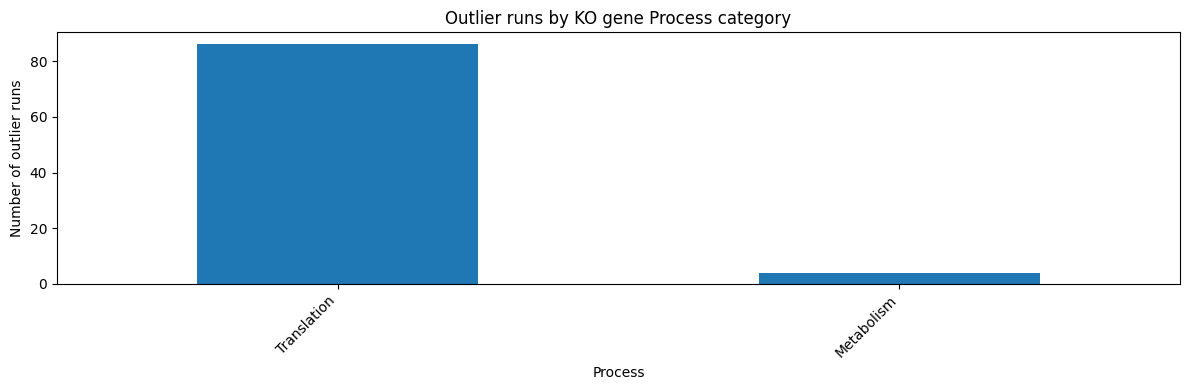

In [21]:
import re
import zipfile
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def read_xlsx_without_openpyxl(path: str, required_header_keys=None) -> pd.DataFrame:
    required_header_keys = required_header_keys or []
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    def col_to_idx(cell_ref: str) -> int:
        col = ''.join(ch for ch in cell_ref if ch.isalpha())
        idx = 0
        for ch in col:
            idx = idx * 26 + (ord(ch.upper()) - ord('A') + 1)
        return idx - 1

    with zipfile.ZipFile(path) as zf:
        shared_strings = []
        if 'xl/sharedStrings.xml' in zf.namelist():
            sroot = ET.fromstring(zf.read('xl/sharedStrings.xml'))
            for si in sroot.findall('a:si', ns):
                parts = [t.text or '' for t in si.findall('.//a:t', ns)]
                shared_strings.append(''.join(parts))

        sheet_xml = ET.fromstring(zf.read('xl/worksheets/sheet1.xml'))
        parsed_rows = []
        for row in sheet_xml.findall('.//a:sheetData/a:row', ns):
            vals = {}
            for c in row.findall('a:c', ns):
                ref = c.attrib.get('r', '')
                if not ref:
                    continue
                cidx = col_to_idx(ref)
                ctype = c.attrib.get('t', '')
                v = c.find('a:v', ns)
                if ctype == 'inlineStr':
                    txt = ''.join(t.text or '' for t in c.findall('.//a:is/a:t', ns))
                    vals[cidx] = txt
                    continue
                if v is None or v.text is None:
                    vals[cidx] = None
                    continue
                raw = v.text
                if ctype == 's' and raw.isdigit() and int(raw) < len(shared_strings):
                    vals[cidx] = shared_strings[int(raw)]
                else:
                    vals[cidx] = raw
            parsed_rows.append(vals)

    if not parsed_rows:
        return pd.DataFrame()

    max_col = max((max(r.keys()) for r in parsed_rows if r), default=-1)
    if max_col < 0:
        return pd.DataFrame()

    data = [[r.get(i, None) for i in range(max_col + 1)] for r in parsed_rows]
    raw_df = pd.DataFrame(data)

    header_row = None
    n_scan = min(50, len(raw_df))
    for i in range(n_scan):
        row_vals = [str(x).strip().lower() if x is not None else '' for x in raw_df.iloc[i].tolist()]
        has_process = 'process' in row_vals
        has_gene = any(('gene' in v and 'id' in v) or v in {'gene', 'gene_id', 'gene id', 'geneid'} for v in row_vals)
        has_required = all(any(k.lower() == v for v in row_vals) for k in required_header_keys) if required_header_keys else True
        if has_process and has_gene and has_required:
            header_row = i
            break

    if header_row is None:
        raise ValueError(f'Could not locate header row in {path}')

    out = raw_df.iloc[header_row + 1:].copy()
    out.columns = [str(x).strip() if x is not None else '' for x in raw_df.iloc[header_row].tolist()]
    out = out.loc[:, [c for c in out.columns if c != '']]
    out = out.dropna(how='all').reset_index(drop=True)
    return out

def normalize_gene_key(x):
    if x is None:
        return None
    s = str(x).strip().upper()
    if not s or s == 'NAN':
        return None
    s = s.replace('KO:', '').strip()
    m = re.search(r'(EG\d+|B\d{4,5})', s)
    if m:
        return m.group(1)
    s = re.sub(r'[^A-Z0-9]', '', s)
    return s or None

label_path = Path('/user/home/il22158/work/vEcoli/reading/imported/gene_process_label_data.xlsx')
labels = read_xlsx_without_openpyxl(str(label_path), required_header_keys=['Process'])

process_col = next((c for c in labels.columns if c.strip().lower() == 'process'), None)
if process_col is None:
    raise ValueError(f"Could not find 'Process' column in {label_path}")

candidate_gene_cols = [
    c for c in labels.columns
    if any(k in c.lower() for k in ['gene', 'id', 'locus', 'symbol', 'bnumber', 'b number']) and c != process_col
]
if not candidate_gene_cols:
    candidate_gene_cols = [c for c in labels.columns if c != process_col][:1]

label_long = labels[candidate_gene_cols + [process_col]].melt(
    id_vars=[process_col], value_vars=candidate_gene_cols, value_name='raw_gene'
).dropna(subset=['raw_gene']).copy()
label_long['key'] = label_long['raw_gene'].map(normalize_gene_key)
label_long = label_long.dropna(subset=['key']).copy()
label_long['Process'] = label_long[process_col].fillna('Unknown').astype(str).str.strip()
label_map = label_long[['key', 'Process']].drop_duplicates('key')

outlier_runs = ko_avg.loc[ko_avg['outlier'], ['run']].drop_duplicates()
run_gene = ko_failed[['run', 'gene_id', 'label']].drop_duplicates('run').copy()
run_gene['gene_key'] = run_gene['gene_id'].map(normalize_gene_key)
run_gene['label_key'] = run_gene['label'].map(normalize_gene_key)

outlier_gene = outlier_runs.merge(run_gene, on='run', how='left')
label_keys = set(label_map['key'])
outlier_gene['map_key'] = outlier_gene['gene_key']
need_fallback = ~outlier_gene['map_key'].isin(label_keys)
outlier_gene.loc[need_fallback, 'map_key'] = outlier_gene.loc[need_fallback, 'label_key']

outlier_gene = outlier_gene.merge(label_map, left_on='map_key', right_on='key', how='left')
outlier_gene['Process'] = outlier_gene['Process'].fillna('Unmapped')

cluster = outlier_gene.groupby('Process').size().rename('n_outlier_runs').sort_values(ascending=False)
cluster_df = cluster.reset_index()

save_dir = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'outlier_runs_with_process_label.csv'
outlier_gene[['run', 'gene_id', 'label', 'gene_key', 'label_key', 'map_key', 'Process']].to_csv(save_path, index=False)

print(f"Total outlier runs: {len(outlier_gene)}")
print(f"Mapped outlier runs: {(outlier_gene['Process'] != 'Unmapped').sum()}")
print(f"Unmapped outlier runs: {(outlier_gene['Process'] == 'Unmapped').sum()}")
print(f"Saved: {save_path}")
display(cluster_df)

if (outlier_gene['Process'] == 'Unmapped').any():
    print('Sample unmapped rows:')
    display(outlier_gene.loc[outlier_gene['Process'] == 'Unmapped', ['run', 'gene_id', 'label', 'gene_key', 'label_key']].head(10))

ax = cluster.plot(kind='bar', figsize=(12, 4))
ax.set_title('Outlier runs by KO gene Process category')
ax.set_xlabel('Process')
ax.set_ylabel('Number of outlier runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Save gene lists

In [3]:
from pathlib import Path
import shlex
import pandas as pd

failure_dir = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure')
failure_dir.mkdir(parents=True, exist_ok=True)

outlier_csv = failure_dir / 'outlier_runs_with_process_label.csv'
outliers = pd.read_csv(outlier_csv)
outliers['run'] = outliers['run'].astype(str)

# Load EG-id -> gene symbol mapping (e.g., EG10864 -> rplA, EG10444 -> cysS)
genes_tsv = Path('/user/home/il22158/work/vEcoli/reconstruction/ecoli/flat/genes.tsv')
gene_map = pd.read_csv(genes_tsv, sep='\t', comment='#', usecols=['id', 'symbol'])
gene_map['id'] = gene_map['id'].astype(str).str.strip()
gene_map['symbol'] = gene_map['symbol'].astype(str).str.strip()
id_to_symbol = gene_map.dropna(subset=['id', 'symbol']).drop_duplicates('id').set_index('id')['symbol']

# Recompute the two outlier criteria per run from the adjacent analysis section
ko_long_path = Path('/user/home/il22158/work/vEcoli/surrogate/results/surrogate_preprocessed_ko441_generation_long.csv')
base_long_path = Path('/user/home/il22158/work/vEcoli/surrogate/results/surrogate_preprocessed_seed_default_generation_long.csv')

ko_long = pd.read_csv(ko_long_path)
base_long = pd.read_csv(base_long_path)

def prep_runs(df: pd.DataFrame) -> pd.DataFrame:
    for c in ['generation_reconstructed', 'growth_mean', 'fold_change_mass', 'variant', 'lineage_seed']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df['run'] = df['variant'].astype('Int64').astype(str) + '_' + df['lineage_seed'].astype('Int64').astype(str)
    return df

ko_long = prep_runs(ko_long)
base_long = prep_runs(base_long)

failed_runs = ko_long.groupby('run')['generation_reconstructed'].max()
failed_runs = failed_runs[failed_runs < 8].index
ko_failed = ko_long[ko_long['run'].isin(failed_runs)].copy()

ko_avg = ko_failed.groupby('run', as_index=False).agg(
    avg_growth=('growth_mean', 'mean'),
    avg_mass_fold_change=('fold_change_mass', 'mean'),
)
base_avg = base_long.groupby('run', as_index=False).agg(
    avg_growth=('growth_mean', 'mean'),
    avg_mass_fold_change=('fold_change_mass', 'mean'),
)
base_growth = base_avg['avg_growth'].head(2).mean()
base_mass_fold_change = base_avg['avg_mass_fold_change'].head(2).mean()

ko_avg['outlier_by_growth_rate'] = ko_avg['avg_growth'] > base_growth
ko_avg['outlier_by_mass_fold_change'] = ko_avg['avg_mass_fold_change'] > base_mass_fold_change
criteria_by_run = ko_avg[['run', 'outlier_by_growth_rate', 'outlier_by_mass_fold_change']]

outliers = outliers.merge(criteria_by_run, on='run', how='left')
outliers['outlier_by_growth_rate'] = outliers['outlier_by_growth_rate'].fillna(False).astype(bool)
outliers['outlier_by_mass_fold_change'] = outliers['outlier_by_mass_fold_change'].fillna(False).astype(bool)

# 1) Single combined unique gene list for all outliers (ID form, existing output)
all_genes = sorted({str(g).strip() for g in outliers['gene_id'].dropna() if str(g).strip()})
all_list_path = failure_dir / 'outlier_genes_all_unique.txt'
all_list_path.write_text('\n'.join(all_genes) + ('\n' if all_genes else ''))

# 1b) Single combined unique list in symbol form (new output)
all_gene_symbols = sorted({id_to_symbol.get(g, g) for g in all_genes if str(g).strip()})
all_symbol_list_path = failure_dir / 'outlier_genes_all_unique_symbols.txt'
all_symbol_list_path.write_text('\n'.join(all_gene_symbols) + ('\n' if all_gene_symbols else ''))

# 1c) Criteria-enriched combined gene list (new CSV with two criteria columns)
gene_summary = (
    outliers[['run', 'gene_id', 'outlier_by_growth_rate', 'outlier_by_mass_fold_change']]
    .dropna(subset=['gene_id'])
    .drop_duplicates()
    .groupby('gene_id', as_index=False)
    .agg(
        n_outlier_runs=('run', 'nunique'),
        n_growth_outlier_runs=('outlier_by_growth_rate', 'sum'),
        n_mass_outlier_runs=('outlier_by_mass_fold_change', 'sum'),
        outlier_by_growth_rate=('outlier_by_growth_rate', 'max'),
        outlier_by_mass_fold_change=('outlier_by_mass_fold_change', 'max'),
    )
)
gene_summary['gene_symbol'] = gene_summary['gene_id'].map(id_to_symbol).fillna(gene_summary['gene_id'])
gene_summary = gene_summary[[
    'gene_id',
    'gene_symbol',
    'outlier_by_growth_rate',
    'outlier_by_mass_fold_change',
    'n_outlier_runs',
    'n_growth_outlier_runs',
    'n_mass_outlier_runs',
]].sort_values(['outlier_by_growth_rate', 'outlier_by_mass_fold_change', 'gene_symbol'], ascending=[False, False, True])
all_criteria_csv = failure_dir / 'outlier_genes_all_unique_with_criteria.csv'
gene_summary.to_csv(all_criteria_csv, index=False)

unmapped_ids = sorted([g for g in all_genes if g not in id_to_symbol.index])

# 2) Use long files to identify correct project folder per outlier run
long_df = pd.concat([ko_long, base_long], ignore_index=True)
meta = long_df[['run', 'project', 'variant', 'lineage_seed']].dropna().drop_duplicates()
run_project = outliers[[
    'run',
    'gene_id',
    'outlier_by_growth_rate',
    'outlier_by_mass_fold_change',
]].drop_duplicates().merge(meta, on='run', how='left')

# 3) Save per-project unique gene lists (recommended input for gene_screen --project)
proj_dir = failure_dir / 'outlier_gene_lists_by_project'
proj_dir.mkdir(parents=True, exist_ok=True)
saved = []
for project, gdf in run_project.dropna(subset=['project']).groupby('project'):
    genes = sorted({str(x).strip() for x in gdf['gene_id'].dropna() if str(x).strip()})
    p = proj_dir / f'outlier_genes_unique__{project}.txt'
    p.write_text('\n'.join(genes) + ('\n' if genes else ''))

    project_summary = (
        gdf[['run', 'gene_id', 'outlier_by_growth_rate', 'outlier_by_mass_fold_change']]
        .dropna(subset=['gene_id'])
        .drop_duplicates()
        .groupby('gene_id', as_index=False)
        .agg(
            n_outlier_runs=('run', 'nunique'),
            n_growth_outlier_runs=('outlier_by_growth_rate', 'sum'),
            n_mass_outlier_runs=('outlier_by_mass_fold_change', 'sum'),
            outlier_by_growth_rate=('outlier_by_growth_rate', 'max'),
            outlier_by_mass_fold_change=('outlier_by_mass_fold_change', 'max'),
        )
)
    project_summary['gene_symbol'] = project_summary['gene_id'].map(id_to_symbol).fillna(project_summary['gene_id'])
    project_summary = project_summary[[
        'gene_id',
        'gene_symbol',
        'outlier_by_growth_rate',
        'outlier_by_mass_fold_change',
        'n_outlier_runs',
        'n_growth_outlier_runs',
        'n_mass_outlier_runs',
    ]].sort_values(['outlier_by_growth_rate', 'outlier_by_mass_fold_change', 'gene_symbol'], ascending=[False, False, True])
    project_criteria_csv = proj_dir / f'outlier_genes_unique__{project}__with_criteria.csv'
    project_summary.to_csv(project_criteria_csv, index=False)

    seeds = sorted(gdf['lineage_seed'].dropna().astype(int).unique().tolist())
    variants = sorted(gdf['variant'].dropna().astype(int).unique().tolist())
    saved.append({
        'project': project,
        'gene_count': len(genes),
        'lineage_seeds': seeds,
        'variants': variants,
        'gene_list_file': str(p),
        'criteria_csv': str(project_criteria_csv),
    })

saved_df = pd.DataFrame(saved).sort_values('project') if saved else pd.DataFrame(columns=['project', 'gene_count', 'lineage_seeds', 'variants', 'gene_list_file', 'criteria_csv'])

# 4) Build project+seed specific run plan and one exact terminal line
plan_rows = []
for (project, seed), gdf in run_project.dropna(subset=['project', 'lineage_seed']).groupby(['project', 'lineage_seed']):
    variants = sorted(gdf['variant'].dropna().astype(int).unique().tolist())
    gene_list_file = str(proj_dir / f'outlier_genes_unique__{project}.txt')
    plan_rows.append({
        'project': str(project),
        'lineage_seed': int(seed),
        'variants_str': ' '.join(str(v) for v in variants),
        'gene_list_file': gene_list_file,
        'output_project': f"outlier_translation_{project}_seed{int(seed)}",
    })
plan_df = pd.DataFrame(plan_rows).sort_values(['project', 'lineage_seed']) if plan_rows else pd.DataFrame(columns=['project', 'lineage_seed', 'variants_str', 'gene_list_file', 'output_project'])

cmds = []
for _, r in plan_df.iterrows():
    cmd = (
        'python3 /user/home/il22158/work/vEcoli/reading/gene_screen.py '
        f"--project {shlex.quote(r['project'])} "
        f"--variants {r['variants_str']} "
        f"--lineage-seed {int(r['lineage_seed'])} "
        '--generations 1 2 3 4 5 6 7 8 '
        f"--gene-list {shlex.quote(r['gene_list_file'])} "
        '--subset 0 '
        f"--output-project {shlex.quote(r['output_project'])}"
    )
    cmds.append(cmd)

terminal_line = 'set -e; ' + '; '.join(cmds) if cmds else 'echo "No outlier runs found"'

print(f'Saved combined unique list (IDs): {all_list_path}')
print(f'Saved combined unique list (symbols): {all_symbol_list_path}')
print(f'Saved combined criteria CSV: {all_criteria_csv}')
print(f'Unique outlier genes (all projects): {len(all_genes)}')
print(f'Unique outlier gene symbols: {len(all_gene_symbols)}')
print(f'Runs flagged by growth criterion: {int(outliers["outlier_by_growth_rate"].sum())}')
print(f'Runs flagged by mass criterion: {int(outliers["outlier_by_mass_fold_change"].sum())}')
print(f'Unmapped IDs in symbol conversion: {len(unmapped_ids)}')
if unmapped_ids:
    print('First unmapped IDs:', ', '.join(unmapped_ids[:10]))
print(f'Saved per-project lists in: {proj_dir}')
display(saved_df)
display(plan_df)
display(gene_summary.head(20))

print('Exact terminal line (copy/paste):')
print(terminal_line)

Saved combined unique list (IDs): /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_genes_all_unique.txt
Saved combined unique list (symbols): /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_genes_all_unique_symbols.txt
Saved combined criteria CSV: /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_genes_all_unique_with_criteria.csv
Unique outlier genes (all projects): 52
Unique outlier gene symbols: 52
Runs flagged by growth criterion: 86
Runs flagged by mass criterion: 66
Unmapped IDs in symbol conversion: 0
Saved per-project lists in: /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_gene_lists_by_project


,project,gene_count,lineage_seeds,variants,gene_list_file,criteria_csv
0,gene_ko_441imported_2seeds,52,"[100, 101]","[7, 11, 24, 31, 41, 48, 57, 59, 65, 84, 95, 98...",/user/home/il22158/work/vEcoli/surrogate/resul...,/user/home/il22158/work/vEcoli/surrogate/resul...
1,gene_ko_metabolic_seed100,1,[100],[7],/user/home/il22158/work/vEcoli/surrogate/resul...,/user/home/il22158/work/vEcoli/surrogate/resul...
2,gene_ko_non_metabolic_seed100,1,[100],[7],/user/home/il22158/work/vEcoli/surrogate/resul...,/user/home/il22158/work/vEcoli/surrogate/resul...
3,gene_ko_trial40_seed101,1,[101],[7],/user/home/il22158/work/vEcoli/surrogate/resul...,/user/home/il22158/work/vEcoli/surrogate/resul...


,project,lineage_seed,variants_str,gene_list_file,output_project
0,gene_ko_441imported_2seeds,100,7 11 24 31 41 48 57 59 65 84 95 98 101 117 122...,/user/home/il22158/work/vEcoli/surrogate/resul...,outlier_translation_gene_ko_441imported_2seeds...
1,gene_ko_441imported_2seeds,101,7 11 24 31 57 59 65 95 98 101 117 124 125 133 ...,/user/home/il22158/work/vEcoli/surrogate/resul...,outlier_translation_gene_ko_441imported_2seeds...
2,gene_ko_metabolic_seed100,100,7,/user/home/il22158/work/vEcoli/surrogate/resul...,outlier_translation_gene_ko_metabolic_seed100_...
3,gene_ko_non_metabolic_seed100,100,7,/user/home/il22158/work/vEcoli/surrogate/resul...,outlier_translation_gene_ko_non_metabolic_seed...
4,gene_ko_trial40_seed101,101,7,/user/home/il22158/work/vEcoli/surrogate/resul...,outlier_translation_gene_ko_trial40_seed101_se...


,gene_id,gene_symbol,outlier_by_growth_rate,outlier_by_mass_fold_change,n_outlier_runs,n_growth_outlier_runs,n_mass_outlier_runs
2,EG10864,rplA,True,True,2,2,1
3,EG10865,rplB,True,True,2,2,2
4,EG10866,rplC,True,True,2,2,2
5,EG10867,rplD,True,True,2,2,2
6,EG10868,rplE,True,True,1,1,1
7,EG10869,rplF,True,True,1,1,1
9,EG10872,rplK,True,True,2,2,1
11,EG10875,rplN,True,True,1,1,1
12,EG10876,rplO,True,True,1,1,1
13,EG10877,rplP,True,True,2,2,2


Exact terminal line (copy/paste):
set -e; python3 /user/home/il22158/work/vEcoli/reading/gene_screen.py --project gene_ko_441imported_2seeds --variants 7 11 24 31 41 48 57 59 65 84 95 98 101 117 122 125 133 135 145 157 189 191 195 200 212 213 218 226 230 239 240 241 244 246 267 284 286 288 289 297 317 326 329 356 357 368 370 400 419 433 436 --lineage-seed 100 --generations 1 2 3 4 5 6 7 8 --gene-list /user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_gene_lists_by_project/outlier_genes_unique__gene_ko_441imported_2seeds.txt --subset 0 --output-project outlier_translation_gene_ko_441imported_2seeds_seed100; python3 /user/home/il22158/work/vEcoli/reading/gene_screen.py --project gene_ko_441imported_2seeds --variants 7 11 24 31 57 59 65 95 98 101 117 124 125 133 135 145 157 191 195 200 213 218 226 230 241 244 246 267 284 286 288 297 329 357 368 370 400 433 436 --lineage-seed 101 --generations 1 2 3 4 5 6 7 8 --gene-list /user/home/il22158/work/vEcoli/surrogate/results/failur

## Trace cell process for outliers

Where outlier gene IDs come from:
1. Original extraction happens upstream from the simulation `label` field, not in the outlier cell.
   - Upstream KO build cell uses: `ko_df = all_df[label startswith "KO:"]` then
     `ko_df['gene_id'] = ko_df['label'].str.extract(r'KO:\\s*([^,\\s]+)')[0]`.
   - This parsed `gene_id` is saved to `ko_runs_with_success_generation.csv`.
2. The surrogate preprocessing stage keeps the same extraction rule.
   - In `surrogate/preprocess.py`, `ts['gene_id']` is again parsed from `label` with the same regex.
   - That `gene_id` is propagated into `surrogate_preprocessed_ko441_generation_long.csv` (the file used in outlier analysis).
3. Outlier section does not newly infer gene IDs.
   - It reads `gene_id` from the preprocessed KO long file.
   - It then selects one row per run (`drop_duplicates('run')`) to attach a representative `gene_id` to each outlier run.

Quick correctness check before gene screen:
- Confirm one unique gene per outlier run:
  `ko_failed.groupby('run')['gene_id'].nunique().value_counts()`
- Expected: all runs should have value `1`; otherwise run->gene mapping is ambiguous.

In [1]:
from pathlib import Path
import shlex
import pandas as pd

outlier_csv = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_runs_with_process_label.csv')
gene_screen_script = Path('/user/home/il22158/work/vEcoli/reading/gene_screen.py')
cmd_dir = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/gene_screen_inputs')
cmd_dir.mkdir(parents=True, exist_ok=True)

# Use long files as source of truth for project / variant / lineage_seed
long_files = [
    Path('/user/home/il22158/work/vEcoli/surrogate/results/surrogate_preprocessed_ko441_generation_long.csv'),
    Path('/user/home/il22158/work/vEcoli/surrogate/results/surrogate_preprocessed_seed_default_generation_long.csv'),
]
long_df = pd.concat([pd.read_csv(p) for p in long_files], ignore_index=True)
long_df['variant'] = pd.to_numeric(long_df['variant'], errors='coerce').astype('Int64')
long_df['lineage_seed'] = pd.to_numeric(long_df['lineage_seed'], errors='coerce').astype('Int64')
long_df['generation_reconstructed'] = pd.to_numeric(long_df['generation_reconstructed'], errors='coerce')
long_df['run'] = long_df['variant'].astype(str) + '_' + long_df['lineage_seed'].astype(str)

outliers = pd.read_csv(outlier_csv)
outliers['run'] = outliers['run'].astype(str)

# Merge outliers with long file metadata to get exact project/seed/generation coverage
meta = (
    long_df[['run', 'project', 'variant', 'lineage_seed', 'generation_reconstructed', 'gene_id']]
    .dropna(subset=['run', 'project', 'variant', 'lineage_seed'])
    .drop_duplicates()
)
merged = outliers.merge(meta, on='run', how='left', suffixes=('', '_long'))

if merged['project'].isna().all():
    raise ValueError('Could not map outlier runs to long-file project metadata.')

# gene_screen currently uses lineage_seed=0 internally; pick a sample that is runnable (seed 0)
runnable = merged[merged['lineage_seed'] == 0].copy()
if runnable.empty:
    sample = merged.iloc[0].copy()
    sample_seed0_msg = (
        'No seed=0 outlier run found in long files. Current gene_screen.py hardcodes lineage_seed=0, '
        'so this sample may fail unless you patch gene_expression_trace.py / gene_screen.py to accept seed.'
    )
else:
    sample = runnable.iloc[0].copy()
    sample_seed0_msg = 'Selected a seed=0 sample from long files (runnable with current gene_screen.py).'

sample_run = str(sample['run'])
sample_gene = str(sample['gene_id']).strip()
sample_project = str(sample['project'])
sample_variant = int(sample['variant'])
sample_seed = int(sample['lineage_seed'])

# generations that exist for this exact run in long files
g = (
    meta.loc[meta['run'] == sample_run, 'generation_reconstructed']
    .dropna().astype(int).sort_values().unique().tolist()
)
if not g:
    g = [1, 2, 3, 4, 5]

gene_file = cmd_dir / f'one_sample_{sample_run}_{sample_gene}.txt'
gene_file.write_text(f'{sample_gene}\n')

cmd = [
    'python', str(gene_screen_script),
    '--project', sample_project,
    '--variants', str(sample_variant),
    '--generations', *[str(x) for x in g],
    '--gene-list', str(gene_file),
    '--subset', '0',
    '--output-project', f'outlier_translation_{sample_run}',
]

print('Suggested one-sample command (project/variant/generation from long files):')
print(' '.join(shlex.quote(x) for x in cmd))
print()
print('Run metadata:')
print(f'- run: {sample_run}')
print(f'- gene: {sample_gene}')
print(f'- project: {sample_project}')
print(f'- variant: {sample_variant}')
print(f'- lineage_seed: {sample_seed}')
print(f'- generations in long file: {g}')
print(sample_seed0_msg)

if sample_seed != 0:
    print('WARNING: current gene_screen.py reads lineage_seed=0 internally; this sample is seed != 0 and may fail.')

# Quick coverage summary to avoid future failures
coverage = merged[['run', 'project', 'variant', 'lineage_seed', 'gene_id', 'Process']].drop_duplicates()
print()
print(f'Outlier rows with long-file metadata: {len(coverage)}')
print(f'Rows with seed=0 (runnable now): {(coverage['lineage_seed'] == 0).sum()}')
display(coverage.head(15))

Suggested one-sample command (project/variant/generation from long files):
python /user/home/il22158/work/vEcoli/reading/gene_screen.py --project gene_ko_441imported_2seeds --variants 101 --generations 1 2 3 4 5 --gene-list /user/home/il22158/work/vEcoli/surrogate/results/failure/gene_screen_inputs/one_sample_101_100_EG10864.txt --subset 0 --output-project outlier_translation_101_100

Run metadata:
- run: 101_100
- gene: EG10864
- project: gene_ko_441imported_2seeds
- variant: 101
- lineage_seed: 100
- generations in long file: [1, 2, 3, 4, 5]
No seed=0 outlier run found in long files. Current gene_screen.py hardcodes lineage_seed=0, so this sample may fail unless you patch gene_expression_trace.py / gene_screen.py to accept seed.

Outlier rows with long-file metadata: 93
Rows with seed=0 (runnable now): 0


,run,project,variant,lineage_seed,gene_id,Process
0,101_100,gene_ko_441imported_2seeds,101,100,EG10864,Translation
5,101_101,gene_ko_441imported_2seeds,101,101,EG10864,Translation
11,117_100,gene_ko_441imported_2seeds,117,100,EG50002,Translation
16,117_101,gene_ko_441imported_2seeds,117,101,EG50002,Translation
21,11_100,gene_ko_441imported_2seeds,11,100,EG10887,Translation
27,11_101,gene_ko_441imported_2seeds,11,101,EG10887,Translation
33,122_100,gene_ko_441imported_2seeds,122,100,EG10868,Translation
39,124_101,gene_ko_441imported_2seeds,124,101,EG10707,Metabolism
46,125_100,gene_ko_441imported_2seeds,125,100,EG10918,Translation
52,125_101,gene_ko_441imported_2seeds,125,101,EG10918,Translation


In [2]:
from pathlib import Path
import re
import pandas as pd

outlier_csv = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_runs_with_process_label.csv')
results_root = Path('/user/home/il22158/work/vEcoli/reading/results')
out_file = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/knockout_function_check.csv')
out_file.parent.mkdir(parents=True, exist_ok=True)

meta = pd.read_csv(outlier_csv)[['run', 'gene_id', 'Process']].drop_duplicates()
meta[['variant', 'lineage_seed']] = meta['run'].str.extract(r'^(\d+)_(\d+)$')
meta = meta.dropna(subset=['variant', 'lineage_seed'])
meta['variant'] = meta['variant'].astype(int)
meta['lineage_seed'] = meta['lineage_seed'].astype(int)
meta = meta.drop_duplicates(subset=['run'], keep='first').set_index('run')

rows = []
for f in sorted(results_root.glob('outlier_translation*/*_52genes.csv')):
    v = re.search(r'_variant(\d+)_', f.name)
    p = re.match(r'(.+)_variant\d+_\d+genes\.csv$', f.name)
    s = re.findall(r'seed(\d+)', f.parent.name)
    if not (v and p and s):
        continue

    variant = int(v.group(1))
    seed = int(s[-1])
    run = f'{variant}_{seed}'
    if run not in meta.index:
        continue

    ko_gene = meta.loc[run, 'gene_id']
    process = meta.loc[run, 'Process']
    df = pd.read_csv(f)
    if not {'gene_id', 'all_transcription_success', 'mean_protein'}.issubset(df.columns):
        continue

    ko = df.loc[df['gene_id'].astype(str).str.strip() == str(ko_gene).strip()]
    if ko.empty:
        continue

    ko = ko.iloc[0]
    ko_tx = pd.to_numeric(ko['all_transcription_success'], errors='coerce')
    ko_mp = pd.to_numeric(ko['mean_protein'], errors='coerce')
    others_mean = pd.to_numeric(
        df.loc[df['gene_id'].astype(str).str.strip() != str(ko_gene).strip(), 'mean_protein'],
        errors='coerce'
    ).mean()
    others_min = pd.to_numeric(
        df.loc[df['gene_id'].astype(str).str.strip() != str(ko_gene).strip(), 'mean_protein'],
        errors='coerce'
    ).min()

    metric1_transcription_zero = int(pd.notna(ko_tx) and ko_tx == 0)
    metric2_mean_protein_below_mean = int(pd.notna(ko_mp) and pd.notna(others_mean) and ko_mp < others_mean)
    metric3_mean_protein_is_lowest = int(pd.notna(ko_mp) and pd.notna(others_min) and ko_mp <= others_min)

    rows.append({
        'project': p.group(1),
        'variant': variant,
        'lineage_seed': seed,
        'run': run,
        'knockout_gene': ko_gene,
        'Process': process,
        'metric1_transcription_zero': metric1_transcription_zero,
        'metric2_mean_protein_below_mean': metric2_mean_protein_below_mean,
        'metric3_mean_protein_is_lowest': metric3_mean_protein_is_lowest,
    })

result = pd.DataFrame(rows).sort_values(['project', 'variant', 'lineage_seed', 'knockout_gene'])
result.to_csv(out_file, index=False)

print(f'Rows written: {len(result)}')
print(f'Output: {out_file}')
display(result.head(20))

Rows written: 90
Output: /user/home/il22158/work/vEcoli/surrogate/results/failure/knockout_function_check.csv


,project,variant,lineage_seed,run,knockout_gene,Process,metric1_transcription_zero,metric2_mean_protein_below_mean,metric3_mean_protein_is_lowest
47,gene_ko_441imported_2seeds,7,100,7_100,EG10891,Translation,1,1,0
87,gene_ko_441imported_2seeds,7,101,7_101,EG10891,Translation,1,1,0
2,gene_ko_441imported_2seeds,11,100,11_100,EG10887,Translation,1,1,0
53,gene_ko_441imported_2seeds,11,101,11_101,EG10887,Translation,1,1,0
23,gene_ko_441imported_2seeds,24,100,24_100,EG10872,Translation,1,1,0
70,gene_ko_441imported_2seeds,24,101,24_101,EG10872,Translation,1,1,0
31,gene_ko_441imported_2seeds,31,100,31_100,EG10892,Translation,1,1,0
76,gene_ko_441imported_2seeds,31,101,31_101,EG10892,Translation,1,1,0
40,gene_ko_441imported_2seeds,41,100,41_100,EG10904,Translation,1,1,0
43,gene_ko_441imported_2seeds,48,100,48_100,EG10196,Metabolism,1,1,0


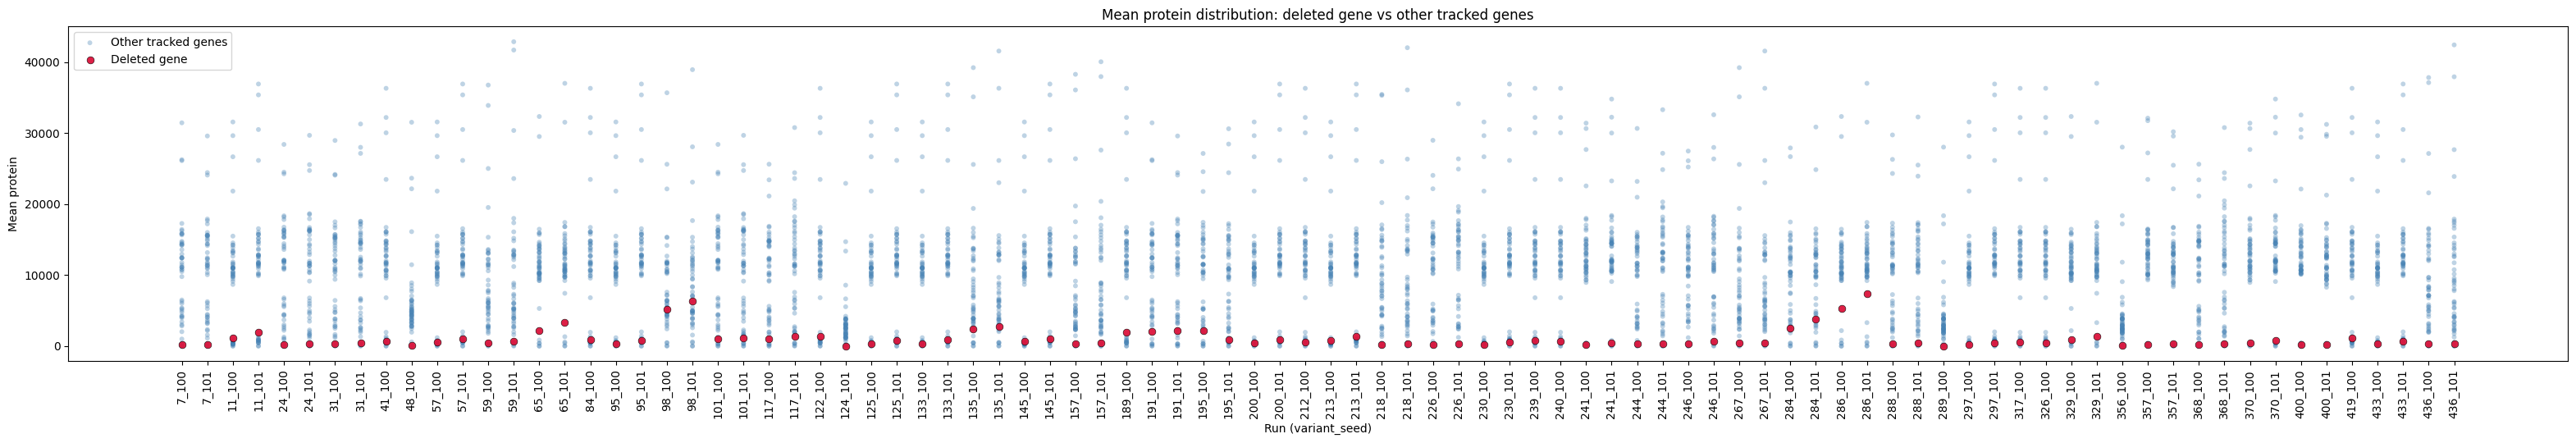

,count,mean,median,min,max
group,,,,,
knockout_gene,90.0,1032.810078,523.944813,0.059228,7445.498060
other_genes,4590.0,10277.887295,10982.962562,0.599153,42902.153448


In [5]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

out_dir = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure')
outlier_csv = Path('/user/home/il22158/work/vEcoli/surrogate/results/failure/outlier_runs_with_process_label.csv')
results_root = Path('/user/home/il22158/work/vEcoli/reading/results')

meta = pd.read_csv(outlier_csv)[['run', 'gene_id']].drop_duplicates()
meta[['variant', 'lineage_seed']] = meta['run'].astype(str).str.extract(r'^(\d+)_(\d+)$')
meta = meta.dropna(subset=['variant', 'lineage_seed'])
meta['variant'] = meta['variant'].astype(int)
meta['lineage_seed'] = meta['lineage_seed'].astype(int)
meta = meta.drop_duplicates(subset=['run'], keep='first').set_index('run')

rows = []
for f in sorted(results_root.glob('outlier_translation*/*_52genes.csv')):
    v = re.search(r'_variant(\d+)_', f.name)
    s = re.findall(r'seed(\d+)', f.parent.name)
    if not (v and s):
        continue

    run = f"{int(v.group(1))}_{int(s[-1])}"
    if run not in meta.index:
        continue

    ko_gene = str(meta.loc[run, 'gene_id']).strip()
    df = pd.read_csv(f)
    if not {'gene_id', 'mean_protein'}.issubset(df.columns):
        continue

    tmp = df[['gene_id', 'mean_protein']].copy()
    tmp['run'] = run
    tmp['gene_id'] = tmp['gene_id'].astype(str).str.strip()
    tmp['mean_protein'] = pd.to_numeric(tmp['mean_protein'], errors='coerce')
    tmp = tmp.dropna(subset=['mean_protein'])
    tmp['group'] = tmp['gene_id'].eq(ko_gene).map({True: 'knockout_gene', False: 'other_genes'})
    rows.append(tmp)

plot_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=['run', 'gene_id', 'mean_protein', 'group'])

if plot_df.empty:
    print('No data found to plot.')
else:
    run_order = sorted(plot_df['run'].unique(), key=lambda x: tuple(map(int, x.split('_'))))
    x_map = {r: i for i, r in enumerate(run_order)}
    plot_df['x'] = plot_df['run'].map(x_map)

    plt.figure(figsize=(max(10, len(run_order) * 0.35), 5.5))

    others = plot_df[plot_df['group'] == 'other_genes']
    ko = plot_df[plot_df['group'] == 'knockout_gene']

    plt.scatter(
        others['x'], others['mean_protein'],
        s=18, alpha=0.35, c='steelblue', label='Other tracked genes', edgecolors='none'
    )
    plt.scatter(
        ko['x'], ko['mean_protein'],
        s=40, alpha=0.95, c='crimson', label='Deleted gene', edgecolors='black', linewidths=0.4
    )

    plt.xticks(list(x_map.values()), list(x_map.keys()), rotation=90)
    plt.xlabel('Run (variant_seed)')
    plt.ylabel('Mean protein')
    plt.title('Mean protein distribution: deleted gene vs other tracked genes')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / 'knockout_gene_mean_protein_comparison.png')
    plt.show()

    display(
        plot_df.groupby('group')['mean_protein']
        .describe()[['count', 'mean', '50%', 'min', 'max']]
        .rename(columns={'50%': 'median'})
    )